<a href="https://colab.research.google.com/github/githubhylin/msw-composition-heating-value/blob/main/MSW_HHV_submissionF7_manuscript_sync.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reproducible Analysis of MSW Composition Classification for Heating-Value Estimation

## Study scope

This notebook reproduces the complete analysis of municipal solid waste (MSW)
physical-composition classification for heating-value estimation using Taiwan
sampling records collected between 2014 and 2019.

- 594 raw sampling records were available; 589 records remained after
  HHV/carbon consistency screening.
- The sampling protocol defines 7 conventional major categories and 26
  composition components. Component Pl11 was zero in every record, so 25
  composition components are analysed.
- Dry-basis heating value (DBH) is the primary modelling target. Higher heating
  value (HHV) is obtained from predicted DBH and the measured moisture content
  of each sample.

In this notebook, thermal homogeneity denotes similarity in empirical effective
heating-value contributions under the observed contamination, ash, material
co-occurrence, and measurement structure; it does not imply equality of
intrinsic material heating values. Thermal group, thermal hierarchy and thermal
boundary are used as analysis terms defined on this basis.

## Analytical workflow

1. Data preprocessing and thermochemical consistency screening.
2. Top-N evaluation of classification resolution.
3. Ridge estimation of empirical effective heating-value coefficients.
4. Within-conventional-major-category heterogeneity assessment.
5. Abundance-weighted contiguous segmentation of the selected diagnostic
   components.
6. Deterministic allocation of the remaining components.
7. Selection and evaluation of complete operational K-group models.
8. Comparison with conventional and literature-reported formula architectures.
9. Temporal, bootstrap, threshold, alpha and coefficient-constraint robustness
   analyses.

The diagnostic resolution was selected by top-N repeated cross-validation on the
training set. The cross-validated minimum occurred at N=11, and these 11
components corresponded exactly to the six L and five M components of this
dataset; the resulting set is therefore referred to as the LM diagnostic set.
L, M and S are prevalence labels only and are not the top-N selection rule.

The final operational K=4 model covers all 25 composition components and retains
no residual predictor. Four operational groups are the recommended resolution
for this dataset and sampling granularity, not a permanent or universally
optimal classification.

## Reproducibility

Set the input and output locations before running the notebook, then execute all
cells in order:

- `MSW_DATA_PATH` — path to the composition dataset.
- `MSW_OUTPUT_DIR` — directory for generated tables and figures.

The underlying row-level dataset is not redistributed with this notebook. If the
input file is unavailable, a synthetic dataset is generated so that the code can
be executed end to end; synthetic runs cannot reproduce the numerical results
reported in the manuscript.

Repository DOI: *(placeholder — to be completed on archiving)*

In [ ]:
# ============================================================================
# >>> USER CONFIGURATION — EDIT THIS FIRST <<<
# Point MSW_DATA_PATH at your dataset BEFORE running the notebook, otherwise
# a SYNTHETIC dataset is generated (code check only — cannot reproduce the
# paper's numbers).  On Colab, uncomment and edit:
#
import os
from google.colab import drive; drive.mount("/content/drive")
os.environ["MSW_DATA_PATH"]  = "/content/drive/MyDrive/Colab Notebooks/WS_data/ws103_108T_E.csv"
os.environ["MSW_OUTPUT_DIR"] = "/content/drive/MyDrive/Colab Notebooks/WS_data/p1out_F7"
# ============================================================================
# >>> USER CONFIGURATION — EDIT THIS FIRST <
# Set MSW_DATA_PATH to your dataset BEFORE running; otherwise a SYNTHETIC
# dataset is generated (code check only — cannot reproduce the paper's numbers).
# The source dataset is not redistributable (see Supplementary S1).
# On Colab, uncomment and edit the three lines below:
#
# import os
# from google.colab import drive; drive.mount("/content/drive")
# os.environ["MSW_DATA_PATH"]  = "/content/drive/MyDrive/<your folder>/<your file>.csv"
# os.environ["MSW_OUTPUT_DIR"] = "/content/drive/MyDrive/<your folder>/outputs"
# ============================================================================
# ============================================================================
# Section 0: Environment setup
# All imports, random seeds, and global analysis hyperparameters are defined
# here as named constants.  Edit ONLY this cell to change analysis settings.
# Corresponds to: Methods §2.3 (cross-validation design and Ridge alpha)
# ============================================================================
import sys, os, platform, warnings, zipfile, json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import scipy
from scipy import stats, optimize
import sklearn
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import (train_test_split, RepeatedKFold,
                                     KFold, cross_val_score)
from sklearn.metrics import mean_squared_error, r2_score

# ── Random seed ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42          # fixed for all random operations
np.random.seed(RANDOM_STATE)

# ── Main model hyperparameters ───────────────────────────────────────────────
ALPHA_MAIN   = 500
# Selected to balance predictive performance and the strength of regularization.
# Candidate values and the joint 1% tolerance assessment are reported in §6b.
TEST_SIZE    = 0.20        # fraction of df_clean held out as test set
N_SPLITS     = 5           # cross-validation folds (Methods §2.3)
N_REPEATS    = 20          # cross-validation repeats (Methods §2.3)
K_RANGE      = list(range(2, 8))   # K candidates for weighted segmentation [2..7]

# ── QA/QC threshold ──────────────────────────────────────────────────────────
HHV_C_THRESHOLD = 140.0    # HHV/C_wet ratio; samples above excluded (Methods §2.1)
                            # Sensitivity variants tested in Section 6a: None/120/140/160

# ── L/M/S abundance thresholds (mean dry-basis %) ────────────────────────────
L_THRESHOLD = 5.0          # >= L_THRESHOLD → "L" (large)
M_THRESHOLD = 1.5          # >= M_THRESHOLD → "M" (medium); < M_THRESHOLD → "S"
MIN_GROUP_SHARE = 1.5      # minimum dry-basis % share per group (Section 3.4)

# ── Robustness-suite parameters ───────────────────────────────────────────────
ALPHA_CANDIDATES      = [50, 100, 200, 300, 500, 750, 1000, 2000]  # Section 6b
HHV_C_THRESHOLDS      = [None, 120, 140, 160]                       # Section 6a
N_BOOTSTRAP           = 500    # bootstrap resamples for co-clustering (Section 6d)
CITY_COL              = "City" # location identifier retained as sample metadata
DATE_COL              = "date" # date column (format 2018/3/26) for LOYO year parsing

# ── K selection: practical-equivalence tolerance ──────────────────────────────
# K is selected as the smallest feasible value whose CV DBH RMSE lies within the
# prespecified percentage tolerance above the minimum, subject to coefficient
# monotonicity and the minimum group-share constraint.
K_TOLERANCES     = [0.01, 0.02, 0.03]   # all three are computed and reported
MAIN_K_TOLERANCE = 0.01                 # default used for RECOMMENDED_K

# ── Analysis flags ────────────────────────────────────────────────────────────
FINAL_K                    = 4
# Operational group count selected using the practical-equivalence rule.
RUN_FINAL_MODEL_VALIDATION = True
# Run fixed-final-model robustness analyses.
RUN_STRICT_FINAL_YEAR      = True
# Re-derive the complete procedure on 2014-2018 and evaluate on 2019.
STRICT_TRAIN_YEARS         = [2014, 2015, 2016, 2017, 2018]
STRICT_TEST_YEAR           = 2019
RUN_FINAL_BOOTSTRAP        = True
# Run bootstrap stability analysis for the complete operational procedure.

# ── Output directories ────────────────────────────────────────────────────────
# Paths are taken from environment variables so that no personal paths or
# cloud-drive mounts are hard-coded (public-release requirement):
#   MSW_DATA_PATH   — input CSV (default: ./data/msw_composition.csv)
#   MSW_OUTPUT_DIR  — output directory (default: ./outputs)
# On Colab, set them with os.environ before running, e.g.:
#   os.environ["MSW_DATA_PATH"] = "/content/drive/MyDrive/.../ws103_108T_E.csv"
DATA_PATH  = os.environ.get("MSW_DATA_PATH", "./data/msw_composition.csv")
OUTPUT_DIR = Path(os.environ.get("MSW_OUTPUT_DIR", "./outputs_wseg"))

# Hard switch: row-level intermediate files (e.g. the cleaned dataset) are
# NEVER written unless this is explicitly set to True.  The public release
# must not distribute row-level data.
EXPORT_RESTRICTED_INTERMEDIATES = False

FIG_DIR = OUTPUT_DIR / "figures"
TBL_DIR = OUTPUT_DIR / "tables"
INT_DIR = OUTPUT_DIR / "intermediate"
for _d in [OUTPUT_DIR, FIG_DIR, TBL_DIR, INT_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# Publication vs exploratory outputs are kept in separate folders
PUB_DIR_OUT = OUTPUT_DIR / "outputs_publication"
EXP_DIR_OUT = OUTPUT_DIR / "outputs_exploratory"
for _d in [PUB_DIR_OUT, EXP_DIR_OUT]:
    _d.mkdir(parents=True, exist_ok=True)

PUBLICATION_MANIFEST = []   # (label, filename, source section)

def save_publication(df, fname, label, section):
    p = PUB_DIR_OUT / fname
    df.to_csv(p, index=False, encoding="utf-8-sig")
    PUBLICATION_MANIFEST.append((label, fname, section))
    register_output(p)
    print(f"  [publication] {fname}  ({label}, {section})")
    return p

def save_exploratory(df, fname):
    p = EXP_DIR_OUT / fname
    df.to_csv(p, index=False, encoding="utf-8-sig")
    register_output(p)
    return p

OUTPUT_FILE_REGISTRY = []

def register_output(path):
    OUTPUT_FILE_REGISTRY.append(str(Path(path).resolve()))

# ── Plotting style (journal-ready) ───────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        100,
    "savefig.dpi":       1000,   # line art ≥ 1000 dpi for journal submission
    "font.family":       "sans-serif",
    "font.size":         10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "legend.fontsize":   9,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linewidth":    0.5,
    "pdf.fonttype":      42,      # TrueType (editable text) in PDF
    "ps.fonttype":       42,      # TrueType (editable text) in PS/EPS
    "svg.fonttype":      "none",  # keep text as text in SVG
})

print(f"Python  : {platform.python_version()}")
print(f"pandas  : {pd.__version__}   numpy: {np.__version__}   sklearn: {sklearn.__version__}")
print(f"RANDOM_STATE={RANDOM_STATE}  ALPHA_MAIN={ALPHA_MAIN}  "
      f"TEST_SIZE={TEST_SIZE}  N_SPLITS={N_SPLITS}  N_REPEATS={N_REPEATS}")
print(f"HHV_C_THRESHOLD={HHV_C_THRESHOLD}  K_RANGE={K_RANGE}")
print(f"Output: {OUTPUT_DIR.resolve()}")

Mounted at /content/drive
Python  : 3.12.13
pandas  : 2.2.2   numpy: 2.0.2   sklearn: 1.6.1
RANDOM_STATE=42  ALPHA_MAIN=500  TEST_SIZE=0.2  N_SPLITS=5  N_REPEATS=20
HHV_C_THRESHOLD=140.0  K_RANGE=[2, 3, 4, 5, 6, 7]
Output: /content/drive/MyDrive/Colab Notebooks/WS_data/p1out_F7


## Section 1: Data loading and preprocessing

Corresponds to Methods §2.1-2.2.

Loads the composition dataset, standardises column names, applies the
thermochemical consistency screening (HHV/carbon ratio) and defines the fixed
training/test partition used throughout the notebook.

In [ ]:
# ── 1a. PATH ────────────────────────────────────────────────────────────────
# DATA_PATH comes from the MSW_DATA_PATH environment variable (Section 0).
# If the file does not exist, a SYNTHETIC dataset is generated instead so the
# code can be verified end-to-end.  Synthetic runs CANNOT reproduce the
# numerical results reported in the paper.
INPUT_PATH = DATA_PATH

# ── 1b. COLUMN MAPPING ──────────────────────────────────────────────────────
# Map standardised internal names (left) to dataset column names (right).
# The left-hand keys are internal identifiers used throughout the notebook.
COLUMN_MAP = {
    "DBH":   "DBH",      # dry-basis heating value — regression target (kcal/kg)
    "water": "Pwater",   # moisture content (%)
    "C_wet": "C",        # wet-basis carbon content (%) — QA/QC only
}

FINE_CATEGORY_MAP = {          # composition component -> dataset column name
    "Pa1":"DpaperP1",  "Pa2":"Dal_fpP2",   "Pa3":"DptabwareP3",
    "Pa4":"DpboxP3",   "Pa5":"DotherP3",   "Pa6":"DdiapP4",
    "Pa7":"DdiapadP4", "Pa8":"DotherP4",
    "Pl1":"DPVCcL1",   "Pl2":"DPEcL2",     "Pl3":"DPPcL3",
    "Pl4":"DPETcL4",   "Pl5":"DPSL5",      "Pl6":"DPSnL6",
    "Pl7":"DPLAcL7",   "Pl8":"DPlbagsL8",  "Pl9":"DPlbaglL9",
    "Pl10":"DotherL10","Pl11":"DpestiL11",
    "Fw1":"DFWedible", "Fw2":"DFWcompost",  "Fw3":"DFWother",
    "Fi":"DallFiber",  "Wo":"DallWood",     "Le":"DallLE",
    "Ot":"DallotherCom",
}
FINE_CATEGORIES = list(FINE_CATEGORY_MAP.keys())

RENAME_DICT = {}
RENAME_DICT.update({v: k for k, v in COLUMN_MAP.items()})
RENAME_DICT.update({v: k for k, v in FINE_CATEGORY_MAP.items()})

# ── 1c. CATEGORY METADATA ───────────────────────────────────────────────────
FINE_CATEGORY_NAMES = {
    "Pa1":"Paper", "Pa2":"Aluminum-laminated paper-based cartons",
    "Pa3":"Paper tableware", "Pa4":"Non-aluminum paper-based cartons",
    "Pa5":"Other paper containers", "Pa6":"Disposable diapers",
    "Pa7":"Sanitary pads", "Pa8":"Other paper products",
    "Pl1":"PVC containers", "Pl2":"PE containers", "Pl3":"PP containers",
    "Pl4":"PET bottles", "Pl5":"Foamed polystyrene",
    "Pl6":"Non-foamed polystyrene", "Pl7":"Bioplastic containers",
    "Pl8":"Thin plastic bags (<0.06 mm)", "Pl9":"Thick plastic bags (>0.06 mm)",
    "Pl10":"Other plastics", "Pl11":"Pesticide containers",
    "Fw1":"Food waste for swine feeding", "Fw2":"Compostable food waste",
    "Fw3":"Other food waste",
    "Fi":"Textiles and fabrics", "Wo":"Wood, bamboo, straw, and leaves",
    "Le":"Leather and rubber", "Ot":"Other combustibles",
}

CONVENTIONAL_GROUPS = {
    "Paper-based":             [f"Pa{i}" for i in range(1, 9)],
    "Plastics":                [f"Pl{i}" for i in range(1, 12)],
    "Food waste":              ["Fw1","Fw2","Fw3"],
    "Textiles/fabric":         ["Fi"],
    "Wood/straw/bamboo/leaves":["Wo"],
    "Leather/rubber":          ["Le"],
    "Other combustible":       ["Ot"],
}
CONVENTIONAL_GROUP_MAP = {
    code: grp for grp, codes in CONVENTIONAL_GROUPS.items() for code in codes
}
_pal = sns.color_palette("tab10", n_colors=len(CONVENTIONAL_GROUPS))
CONVENTIONAL_GROUP_COLORS = {g: _pal[i] for i, g in enumerate(CONVENTIONAL_GROUPS)}

def classify_lms(mean_pct):
    if mean_pct >= L_THRESHOLD: return "L"
    elif mean_pct >= M_THRESHOLD: return "M"
    else: return "S"

In [ ]:
# ── 1d. Load the dataset, validate columns and standardise names ───────────
REQUIRED_COLUMNS = (list(COLUMN_MAP.values()) + list(FINE_CATEGORY_MAP.values())
                    + [DATE_COL] + ([CITY_COL] if CITY_COL else []))

USING_SYNTHETIC_DATA = not Path(INPUT_PATH).exists()
if USING_SYNTHETIC_DATA:
    print("=" * 70)
    print("WARNING: input file not found — generating a SYNTHETIC dataset for")
    print("code verification only.  Results from synthetic data CANNOT")
    print("reproduce the numerical values reported in the paper.")
    print("=" * 70)
    _rng = np.random.default_rng(RANDOM_STATE)
    _n_syn = 200
    _syn = {}
    _syn[DATE_COL] = pd.to_datetime(
        _rng.integers(pd.Timestamp("2014-01-01").value // 10**9,
                      pd.Timestamp("2019-12-31").value // 10**9, _n_syn),
        unit="s").strftime("%Y/%m/%d")
    if CITY_COL:
        _syn[CITY_COL] = _rng.choice(["CityA","CityB","CityC","CityD"], _n_syn)
    _comp = _rng.dirichlet(np.ones(len(FINE_CATEGORY_MAP)) * 0.5, _n_syn) * 90.0
    for _j, _col in enumerate(FINE_CATEGORY_MAP.values()):
        _syn[_col] = np.round(_comp[:, _j], 2)
    _true_beta = _rng.uniform(20, 90, len(FINE_CATEGORY_MAP))
    _dbh = _comp @ _true_beta + _rng.normal(0, 300, _n_syn)
    _syn[COLUMN_MAP["DBH"]]   = np.round(np.clip(_dbh, 500, None), 1)
    _syn[COLUMN_MAP["water"]] = np.round(_rng.uniform(30, 70, _n_syn), 1)
    _syn[COLUMN_MAP["C_wet"]] = np.round(_rng.uniform(15, 35, _n_syn), 2)
    df_raw = pd.DataFrame(_syn)
    Path("./data").mkdir(exist_ok=True)
    df_raw.to_csv("./data/synthetic_msw.csv", index=False)
    print("Synthetic dataset saved to ./data/synthetic_msw.csv")
else:
    print(f"Loading data from: {INPUT_PATH}")
    df_raw = pd.read_csv(INPUT_PATH)
missing = [c for c in REQUIRED_COLUMNS if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}\n"
                     "Update COLUMN_MAP / FINE_CATEGORY_MAP in Section 1b.")
print(f"Loaded {len(df_raw)} rows × {df_raw.shape[1]} columns — all required columns found.")
df_raw = df_raw.rename(columns=RENAME_DICT)

# ── 1e. QA/QC filtering ──────────────────────────────────────────────────────
# Corresponds to: Methods §2.2
def run_qaqc(df_in, fine_cats, threshold):
    '''Apply QA/QC pipeline: drop near-empty columns, fill NaN with 0,
    exclude samples with HHV/C_wet > threshold (None = skip exclusion).

    Returns
    -------
    df_clean : pd.DataFrame          QA/QC-passed samples
    components_clean : list of str   composition components retained
    conventional_groups_clean : dict group -> surviving member codes
    qa_summary : dict                counts, threshold, NaN-fill report
    '''
    df = df_in.copy()
    df["HHV"] = df["DBH"] * (100.0 - df["water"]) / 100.0
    df["HHV_C_ratio"] = df["HHV"] / df["C_wet"]

    # Drop near-empty component columns
    cats = list(fine_cats)
    drop = [c for c in cats
            if df[c].isna().mean() > 0.5 or df[c].fillna(0).mean() < 0.01]
    if drop:
        print(f"  Dropping near-empty columns: {drop}")
        cats = [c for c in cats if c not in drop]
        df = df.drop(columns=drop)
    # Report per-column NaN counts that will be filled with 0
    _nan_counts = df[cats].isna().sum()
    _nan_counts = _nan_counts[_nan_counts > 0].to_dict()
    if _nan_counts:
        print(f"  NaN values filled with 0 (column: count): {_nan_counts}")
    df[cats] = df[cats].fillna(0)

    # Sanity checks: finiteness and physical ranges
    for _col, _lo, _hi in [("DBH", 0.0, 12000.0), ("water", 0.0, 100.0)]:
        _v = df[_col].astype(float)
        if not np.isfinite(_v).all():
            raise ValueError(f"QA/QC: non-finite values in '{_col}'")
        _bad = ((_v < _lo) | (_v > _hi)).sum()
        if _bad:
            raise ValueError(f"QA/QC: {_bad} value(s) in '{_col}' outside "
                             f"[{_lo}, {_hi}]")
    if not np.isfinite(df["HHV_C_ratio"].astype(float)).all():
        raise ValueError("QA/QC: non-finite HHV/C ratio (check C_wet zeros)")
    _neg_comp = int((df[cats] < 0).sum().sum())
    if _neg_comp:
        raise ValueError(f"QA/QC: {_neg_comp} negative composition value(s)")

    # Sync CONVENTIONAL_GROUPS
    cg = {g: [c for c in m if c in cats] for g, m in CONVENTIONAL_GROUPS.items()}

    # Outlier exclusion
    n_before = len(df)
    if threshold is not None:
        mask = df["HHV_C_ratio"] <= threshold
        n_excl = int((~mask).sum())
        df = df.loc[mask].reset_index(drop=True)
    else:
        n_excl = 0
    summary = {"original_n": n_before, "excluded_n": n_excl,
               "threshold": threshold, "final_n": len(df),
               "nan_filled": str(_nan_counts) if _nan_counts else "none"}
    return df, cats, cg, summary

df_clean, FINE_CATEGORIES, CONVENTIONAL_GROUPS, qa_summary = run_qaqc(
    df_raw, FINE_CATEGORIES, HHV_C_THRESHOLD
)

qa_df = pd.DataFrame([qa_summary])
qa_df.to_csv(TBL_DIR/"internal_QAQC_summary.csv", index=False)
qa_df.to_excel(TBL_DIR/"internal_QAQC_summary.xlsx", index=False)
register_output(TBL_DIR/"internal_QAQC_summary.csv")
if EXPORT_RESTRICTED_INTERMEDIATES:
    # Row-level data: only written when the hard switch is explicitly enabled.
    df_clean.to_csv(INT_DIR/"cleaned_dataset.csv", index=False)
    register_output(INT_DIR/"cleaned_dataset.csv")
else:
    print("Row-level intermediates NOT exported "
          "(EXPORT_RESTRICTED_INTERMEDIATES=False)")

print(f"QA/QC: {qa_summary['original_n']} → {qa_summary['final_n']} samples "
      f"({qa_summary['excluded_n']} excluded, threshold={HHV_C_THRESHOLD})")
display(qa_df)

# ── 1f. Train/test split and CV setup ────────────────────────────────────────
all_idx = np.arange(len(df_clean))
train_idx, test_idx = train_test_split(
    all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
df_train = df_clean.iloc[train_idx].reset_index(drop=True)
df_test  = df_clean.iloc[test_idx].reset_index(drop=True)
cv       = RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS,
                         random_state=RANDOM_STATE)

DBH_COL   = "DBH"
HHV_COL   = "HHV"
WATER_COL = "water"

print(f"Train: {len(df_train)}  Test: {len(df_test)}  "
      f"CV: {N_SPLITS}-fold × {N_REPEATS} repeats = {N_SPLITS*N_REPEATS} folds")

Loading data from: /content/drive/MyDrive/Colab Notebooks/WS_data/ws103_108T_E.csv
Loaded 594 rows × 135 columns — all required columns found.
  Dropping near-empty columns: ['Pl11']
Row-level intermediates NOT exported (EXPORT_RESTRICTED_INTERMEDIATES=False)
QA/QC: 594 → 589 samples (5 excluded, threshold=140.0)


,original_n,excluded_n,threshold,final_n,nan_filled
0,594,5,140.0,589,none


Train: 471  Test: 118  CV: 5-fold × 20 repeats = 100 folds


## Section 2: Shared analytical functions

All subsequent analyses call the functions defined here:

- zero-intercept Ridge fitting and repeated cross-validation,
- abundance-weighted contiguous segmentation,
- deterministic allocation of components to operational groups,
- model evaluation on training cross-validation and the held-out test set,
- conversion of predicted dry-basis heating value to higher heating value using
  the measured moisture content.

In [ ]:
# ============================================================================
# Section 2: Core Function Library
# Shared Ridge fitting, weighted segmentation, allocation, and
# model-evaluation functions.

# ── 2A. Ridge cross-validation ───────────────────────────────────────────────
def fit_ridge_cv(X_tr, y_dbh_tr, cv, alpha=None, water=None):
    '''No-intercept Ridge CV on training data.

    Fold-level and repeat-level standard errors are retained as descriptive
    measures of resampling variability. Neither is used in the
    practical-equivalence selection of K or alpha.

    The point estimate cv_dbh_rmse is the mean of the repeat-level pooled
    RMSEs; R^2 values are computed per repeat from OOF predictions and
    averaged.

    Parameters
    ----------
    X_tr : pd.DataFrame or np.ndarray  (n_train x p)
    y_dbh_tr : array-like               DBH values for training rows
    cv : sklearn cross-validator
    alpha : float, optional             defaults to ALPHA_MAIN
    water : array-like, optional        moisture (%) per training row; when
                                        given, HHV-scale CV metrics are also
                                        computed

    Returns
    -------
    cv_metrics : dict  {'cv_dbh_rmse','cv_dbh_rmse_se','cv_dbh_rmse_se_rep',
                        'cv_dbh_r2','cv_hhv_rmse','cv_hhv_rmse_se',
                        'cv_hhv_r2'}
    coef_df    : pd.DataFrame  (n_folds x p) per-fold coefficient matrix
    '''
    if alpha is None:
        alpha = ALPHA_MAIN
    X = np.asarray(X_tr, dtype=float)
    y = np.asarray(y_dbh_tr, dtype=float)
    n = len(y)
    if water is not None:
        water = np.asarray(water, dtype=float)
    cols = list(X_tr.columns) if hasattr(X_tr, "columns") else [f"x{i}" for i in range(X.shape[1])]

    splits  = list(cv.split(X))
    n_folds = len(splits)
    n_reps  = int(getattr(cv, "n_repeats", 1))
    n_spl   = n_folds // n_reps if n_reps > 0 else n_folds

    coef_rows     = []
    fold_dbh_rmse = []
    rep_dbh_rmse, rep_dbh_r2 = [], []
    rep_hhv_rmse, rep_hhv_r2 = [], []

    for rep in range(n_reps):
        oof_pred = np.full(n, np.nan)
        for f in range(n_spl):
            tr_idx, val_idx = splits[rep * n_spl + f]
            m = Ridge(alpha=alpha, fit_intercept=False)
            m.fit(X[tr_idx], y[tr_idx])
            pred = m.predict(X[val_idx])
            oof_pred[val_idx] = pred
            fold_dbh_rmse.append(float(np.sqrt(mean_squared_error(y[val_idx], pred))))
            coef_rows.append(dict(zip(cols, m.coef_)))
        ok = ~np.isnan(oof_pred)
        rep_dbh_rmse.append(float(np.sqrt(mean_squared_error(y[ok], oof_pred[ok]))))
        rep_dbh_r2.append(float(r2_score(y[ok], oof_pred[ok])))
        if water is not None:
            hhv_true = y[ok]        * (100.0 - water[ok]) / 100.0
            hhv_pred = oof_pred[ok] * (100.0 - water[ok]) / 100.0
            rep_hhv_rmse.append(float(np.sqrt(mean_squared_error(hhv_true, hhv_pred))))
            rep_hhv_r2.append(float(r2_score(hhv_true, hhv_pred)))

    fold_se = (float(np.std(fold_dbh_rmse, ddof=1) / np.sqrt(len(fold_dbh_rmse)))
               if len(fold_dbh_rmse) > 1 else np.nan)
    rep_se  = (float(np.std(rep_dbh_rmse, ddof=1) / np.sqrt(len(rep_dbh_rmse)))
               if len(rep_dbh_rmse) > 1 else np.nan)

    cv_metrics = {
        "cv_dbh_rmse":        float(np.mean(rep_dbh_rmse)),
        "cv_dbh_rmse_se":     fold_se,     # descriptive only
        "cv_dbh_rmse_se_rep": rep_se,      # parallel output
        "cv_dbh_r2":          float(np.mean(rep_dbh_r2)),
        "cv_hhv_rmse":        float(np.mean(rep_hhv_rmse)) if rep_hhv_rmse else np.nan,
        "cv_hhv_rmse_se":     (float(np.std(rep_hhv_rmse, ddof=1)/np.sqrt(len(rep_hhv_rmse)))
                                if len(rep_hhv_rmse) > 1 else np.nan),
        "cv_hhv_r2":          float(np.mean(rep_hhv_r2))  if rep_hhv_r2  else np.nan,
    }
    return cv_metrics, pd.DataFrame(coef_rows, columns=cols)

# ── 2B0. Weighted contiguous segmentation (share-weighted Fisher 1958) ─────
def weighted_contiguous_segmentation(betas, pbars, K):
    '''Optimal contiguous K-partition of the beta-sorted sequence minimising
    the share-weighted within-group sum of squares
        J_K = sum_g sum_{j in g} pbar_j * (beta_j - mu_g)^2,
        mu_g = sum(pbar_j*beta_j)/sum(pbar_j)
    (weighted version of Fisher 1958 optimal partition).  n is small (11),
    so all C(n-1, K-1) cut sets are enumerated.

    Tie rule (pre-specified): if several cut sets attain the minimal J_K
    (within 1e-9), the one with cutpoints closest to the LOW-coefficient end
    (lexicographically smallest cut tuple) is selected.

    Returns (J_best, cuts_best, ties) where cuts are indices into the sorted
    sequence and ties lists ALL minimising cut tuples.'''
    n = len(betas)
    if K < 1 or K > n:
        raise ValueError(f'K={K} invalid for n={n} components')
    best_J, best_cuts, ties = None, None, []
    for cuts in combinations(range(1, n), K - 1):
        bounds = (0,) + cuts + (n,)
        J = 0.0
        for a, b in zip(bounds[:-1], bounds[1:]):
            w = pbars[a:b]; x = betas[a:b]
            W = float(sum(w))
            if W <= 0:
                J = np.inf; break
            mu = sum(wi * xi for wi, xi in zip(w, x)) / W
            J += sum(wi * (xi - mu) ** 2 for wi, xi in zip(w, x))
        if best_J is None or J < best_J - 1e-9:
            best_J, best_cuts, ties = J, cuts, [cuts]
        elif abs(J - best_J) <= 1e-9:
            ties.append(cuts)
    if len(ties) > 1:
        best_cuts = min(ties)          # pre-specified tie rule
    return best_J, best_cuts, ties

WSEG_TIE_LOG = []   # (context, K, ties) — populated whenever J_K is non-unique

def seg_groups(ordered_codes, beta_values, K, share_map, context=""):
    '''Weighted contiguous
    segmentation.  share_map: code -> train-based mean dry-basis share.
    Returns (groups, cutpoints) and logs J/ties.'''
    pb = [float(share_map[c]) for c in ordered_codes]
    J, cuts, ties = weighted_contiguous_segmentation(list(beta_values), pb, K)
    if len(ties) > 1:
        WSEG_TIE_LOG.append((context, K, list(ties)))
    bounds = (0,) + tuple(cuts) + (len(ordered_codes),)
    groups = [ordered_codes[a:b] for a, b in zip(bounds[:-1], bounds[1:])]
    seg_groups.last_J = J
    return groups, list(cuts)


# ── 2A2. K selection: practical-equivalence tolerance ──────────────────────
K_SELECTION_METHOD = "practical_equivalence_tolerance"   # audited in Section P

def select_k_by_tolerance(cv_rmse_by_K, feasible_K, tolerances):
    '''Practical-equivalence K selection (used by Sections 3.4, 3.4b and 4).

    cv_rmse_by_K : dict K -> CV DBH RMSE (training-set repeated CV)
    feasible_K   : candidate K passing monotonicity + minimum-share checks
    tolerances   : iterable of proportional tolerances t

    K_best = argmin CV RMSE over feasible_K; for each t,
    near_best(t) = {K in feasible_K : rmse(K) <= rmse(K_best)*(1+t)};
    K_selected(t) = min(near_best(t)).
    Standard errors are not used for selection.
    Returns dict with K_best, rmse_min and per-tolerance results.'''
    K_best = min(feasible_K, key=lambda K: cv_rmse_by_K[K])
    rmse_min = float(cv_rmse_by_K[K_best])
    out = {"K_best": K_best, "rmse_min": rmse_min, "by_tol": {}}
    for t in tolerances:
        thr = rmse_min * (1.0 + t)
        near = sorted(K for K in feasible_K if cv_rmse_by_K[K] <= thr)
        out["by_tol"][t] = {"tolerance": t, "threshold": thr,
                             "near_best_K": near, "K_selected": min(near)}
    return out


# ── 2C. Full model evaluation ────────────────────────────────────────────────
def eval_model(X_tr, X_te, df_tr, df_te, cv, alpha=None):
    '''Fit + CV-evaluate + test-evaluate a no-intercept Ridge model on
    pre-built design matrices.  This is the single gateway called by all
    downstream sections.

    Parameters
    ----------
    X_tr, X_te : pd.DataFrame   design matrices (same column names)
    df_tr, df_te : pd.DataFrame rows of df_clean (must contain DBH/HHV/water cols)
    cv : cross-validator
    alpha : float, optional     defaults to ALPHA_MAIN

    Returns
    -------
    metrics : dict  all CV + test metrics
    model   : fitted Ridge
    coef_df : pd.DataFrame  per-fold coefficient matrix
    '''
    if alpha is None: alpha = ALPHA_MAIN
    y_dbh_tr = df_tr[DBH_COL].astype(float).values
    y_hhv_tr = df_tr[HHV_COL].astype(float).values
    water_tr = df_tr[WATER_COL].astype(float).values
    y_dbh_te = df_te[DBH_COL].astype(float).values
    y_hhv_te = df_te[HHV_COL].astype(float).values
    water_te = df_te[WATER_COL].astype(float).values

    cv_metrics, coef_df = fit_ridge_cv(X_tr, y_dbh_tr, cv, alpha, water=water_tr)

    # Fit on full training set → test
    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X_tr.values, y_dbh_tr)
    pred_dbh_te = model.predict(X_te.values)
    pred_hhv_te = pred_dbh_te * (100.0 - water_te) / 100.0

    def _rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
    def _r2(a, b):   return float(r2_score(a, b))
    def _mape(a, b):
        nz = a != 0
        return float(np.mean(np.abs((a[nz]-b[nz])/a[nz]))*100) if nz.sum() else np.nan

    test_metrics = {
        "test_dbh_rmse": _rmse(y_dbh_te, pred_dbh_te),
        "test_hhv_rmse": _rmse(y_hhv_te, pred_hhv_te),
        "test_hhv_r2":   _r2(y_hhv_te,   pred_hhv_te),
        "test_hhv_mape": _mape(y_hhv_te,  pred_hhv_te),
    }
    return {**cv_metrics, **test_metrics}, model, coef_df


# ── 2D. Helper: design matrix builder ────────────────────────────────────────
def build_X(df, included_codes, residual_codes=None):
    X = pd.DataFrame(index=df.index)
    for c in included_codes:
        X[c] = df[c].astype(float).values
    if residual_codes:
        X["Residual"] = df[list(residual_codes)].astype(float).sum(axis=1).values
    return X


def build_X_groups(df, groups_dict):
    '''Build design matrix from a dict {col_name: list_of_codes}.'''
    X = pd.DataFrame(index=df.index)
    for name, codes in groups_dict.items():
        avail = [c for c in codes if c in df.columns]
        X[name] = df[avail].astype(float).sum(axis=1).values if avail                   else pd.Series(0.0, index=df.index).values
    return X


# ── 2E. coefficient_stats ─────────────────────────────────────────────────────
def coefficient_stats(coef_df):
    '''Summarise per-fold coefficient distributions → one row per predictor.
    Columns: code, coef_mean, coef_sd, coef_iqr,
             coef_q25, coef_q50, coef_q75, coef_p2_5, coef_p97_5.
    '''
    records = []
    for col in coef_df.columns:
        vals = coef_df[col].values.astype(float)
        q25, q50, q75 = np.percentile(vals, [25, 50, 75])
        p2_5, p97_5   = np.percentile(vals, [2.5, 97.5])
        records.append({
            "code":       col,
            "coef_mean":  float(np.mean(vals)),
            "coef_sd":    float(np.std(vals, ddof=1)) if len(vals)>1 else 0.0,
            "coef_iqr":   float(q75 - q25),
            "coef_q25":   float(q25),
            "coef_q50":   float(q50),
            "coef_q75":   float(q75),
            "coef_p2_5":  float(p2_5),
            "coef_p97_5": float(p97_5),
        })
    return pd.DataFrame.from_records(records)


def is_monotonic(values, tol=1e-9):
    v = list(values)
    return all(v[i] <= v[i+1]+tol for i in range(len(v)-1))


# ── 2F. I/O helpers ───────────────────────────────────────────────────────────
TABLE_PREFIX = "wseg_"   # variant prefix for all key tables

def save_table(df_out, name):
    name = TABLE_PREFIX + name
    csv_p  = TBL_DIR / f"{name}.csv"
    xlsx_p = TBL_DIR / f"{name}.xlsx"
    df_out.to_csv(csv_p, index=False)
    df_out.to_excel(xlsx_p, index=False)
    register_output(csv_p); register_output(xlsx_p)
    return csv_p, xlsx_p


def save_figure(fig, name):
    png_p = FIG_DIR / f"{name}.png"
    svg_p = FIG_DIR / f"{name}.svg"
    pdf_p = FIG_DIR / f"{name}.pdf"
    fig.savefig(png_p, dpi=1000, bbox_inches="tight")
    fig.savefig(svg_p, bbox_inches="tight")
    fig.savefig(pdf_p, bbox_inches="tight")
    register_output(png_p); register_output(svg_p); register_output(pdf_p)
    return png_p, svg_p, pdf_p


print("Section 2 loaded: fit_ridge_cv | weighted_contiguous_segmentation | "
      "seg_groups | select_k_by_tolerance | allocate_residual_by_affinity | "
      "build_complete_operational_groups | eval_model")
print("Helpers: build_X | build_X_groups | coefficient_stats | save_table | save_figure")

# ── 2G. Operational-allocation library (used by operational stage and robustness analyses) ────────
def allocate_residual_by_affinity(lm_groups, gammas, abundance_train_df,
                                   conv_map, trad_cstats_in, s_codes):
    '''Prespecified deterministic allocation of the S/residual components.

    R1 - the component's conventional major category has diagnostic anchors:
      attach the component to the
      LM group holding the largest summed train-set mean share of that
      parent's LM members (group numbers are derived, never hard-coded).
    Rule 2 — no LM anchor (e.g. Le, Ot): attach to the group whose gamma is
      closest to the parent's training-set 7C effective coefficient.
    Returns dict code -> (group_index0, rule, anchor_info).'''
    target_by_conv = {}
    convs = {conv_map.get(c) for grp in lm_groups for c in grp} - {None}
    for conv in convs:
        shares = []
        for mem in lm_groups:
            sh = float(abundance_train_df.loc[
                abundance_train_df["code"].isin(
                    [c for c in mem if conv_map.get(c) == conv]),
                "mean_pct"].sum())
            shares.append(sh)
        if max(shares) > 0:
            target_by_conv[conv] = int(np.argmax(shares))
    alloc = {}
    for c in s_codes:
        parent = conv_map.get(c, "")
        if parent in target_by_conv:
            gi = target_by_conv[parent]
            alloc[c] = (gi, "R1: traditional-parent LM anchor (largest LM share)",
                        f"parent={parent}")
        else:
            c7 = (float(trad_cstats_in[parent]) if isinstance(trad_cstats_in, dict)
                  else float(trad_cstats_in.loc[trad_cstats_in["code"] == parent,
                                                 "coef_mean"].iloc[0]))
            gi = int(np.argmin([abs(c7 - g) for g in gammas]))
            alloc[c] = (gi, "R2: nearest training 7C coefficient (no LM anchor)",
                        f"parent={parent}, 7C_coef={c7:.1f}")
    return alloc

def build_operational_allocation_anchors(df_tr_var, lm_groups, s_codes_var,
                                          alpha=None):
    '''Full-training-fit allocation anchors on the SAME variant data/alpha:
    (a) LM-group gammas from the LM-groups+Residual Ridge full fit;
    (b) conventional 7C coefficients from a 7C Ridge full fit.
    Full-fit values serve ONLY as allocation anchors; predictive performance
    is always evaluated by repeated CV and the held-out test set.'''
    y_ = df_tr_var[DBH_COL].astype(float).values
    gd_ = {f"Group{i}": m for i, m in enumerate(lm_groups, 1)}
    if s_codes_var: gd_["Residual"] = list(s_codes_var)
    m_ = Ridge(alpha=(alpha or ALPHA_MAIN), fit_intercept=False).fit(
        build_X_groups(df_tr_var, gd_).values, y_)
    cm_ = dict(zip(gd_.keys(), m_.coef_))
    gammas_ = [float(cm_[f"Group{i}"]) for i in range(1, len(lm_groups) + 1)]
    cg_ = {g: [c_ for c_ in mm if c_ in df_tr_var.columns]
           for g, mm in CONVENTIONAL_GROUPS.items()}
    X7_ = build_X_groups(df_tr_var, cg_)
    m7_ = Ridge(alpha=(alpha or ALPHA_MAIN), fit_intercept=False).fit(X7_.values, y_)
    conv_coefs_ = dict(zip(X7_.columns, [float(v) for v in m7_.coef_]))
    return gammas_, conv_coefs_

def complete_operational_from_lm(lm_groups, df_tr_var, ab_var, s_codes_var,
                                  trad_cs=None, alpha=None):
    '''Complete a variant LM segmentation into terminal operational groups.
    Variant group gammas (for rule R2) come from a single Ridge fit of the
    LM-groups+Residual design on the VARIANT training data; allocation uses
    the variant abundance.  trad_cs defaults to the main-train 7C
    coefficients (noted where used in sensitivity analyses).'''
    gammas_, conv_coefs_ = build_operational_allocation_anchors(
        df_tr_var, lm_groups, s_codes_var, alpha=alpha)
    alloc_ = allocate_residual_by_affinity(lm_groups, gammas_, ab_var,
                                            CONVENTIONAL_GROUP_MAP, conv_coefs_,
                                            list(s_codes_var))
    groups_ = [list(m) for m in lm_groups]
    for c, (gi, _, _) in alloc_.items():
        groups_[gi].append(c)
    return groups_, alloc_

Section 2 loaded: fit_ridge_cv | weighted_contiguous_segmentation | seg_groups | select_k_by_tolerance | allocate_residual_by_affinity | build_complete_operational_groups | eval_model
Helpers: build_X | build_X_groups | coefficient_stats | save_table | save_figure


## Section 3: Main analysis

| Notebook section | Analysis | Manuscript output |
|---|---|---|
| 3.0 | Component abundance, training-set prevalence labels and top-N resolution | Figure 1 |
| 3.1 | Ridge models at L, LM and LMS resolutions | Supports Figures 1-2 and diagnostic coefficient analysis |
| 3.2 | Repeated-CV effective coefficient distributions | Figure 2 |
| 3.3 | Within-conventional-major-category heterogeneity | Main Table 1 |
| 3.4 | Abundance-weighted contiguous segmentation and operational regrouping | Main Table 2; Figure 3 |
| 3.4c | Complete mapping of all 25 components | Table S4 |
| 3.5 | Transfer and recalibration of literature-reported formulas | Main Table 3 |

The diagnostic resolution was selected by top-N repeated cross-validation. The
minimum occurred at N=11, which corresponded exactly to the six L and five M
components in this dataset. The resulting LM diagnostic set was used for
coefficient diagnostics and contiguous segmentation.

[training set] L=6  M=5  S=14  total=25
[train-based] LM coverage = 87.6% of dry mass
L/M/S class differs between train and full data: none


,code,full_name,conventional_group,mean_pct,lms_class,cumulative_coverage
0,Pl10,Other plastics,Plastics,17.703631,L,17.703631
1,Fw2,Compostable food waste,Food waste,16.639766,L,34.343397
2,Pa8,Other paper products,Paper-based,16.175159,L,50.518556
3,Pa1,Paper,Paper-based,8.374565,L,58.893121
4,Fi,Textiles and fabrics,Textiles/fabric,5.635775,L,64.528896
5,Pa6,Disposable diapers,Paper-based,5.451062,L,69.979958
6,Fw3,Other food waste,Food waste,4.535669,M,74.515626
7,Fw1,Food waste for swine feeding,Food waste,4.515223,M,79.030849
8,Pl8,Thin plastic bags (<0.06 mm),Plastics,3.634544,M,82.665393
9,Pa5,Other paper containers,Paper-based,2.501614,M,85.167006


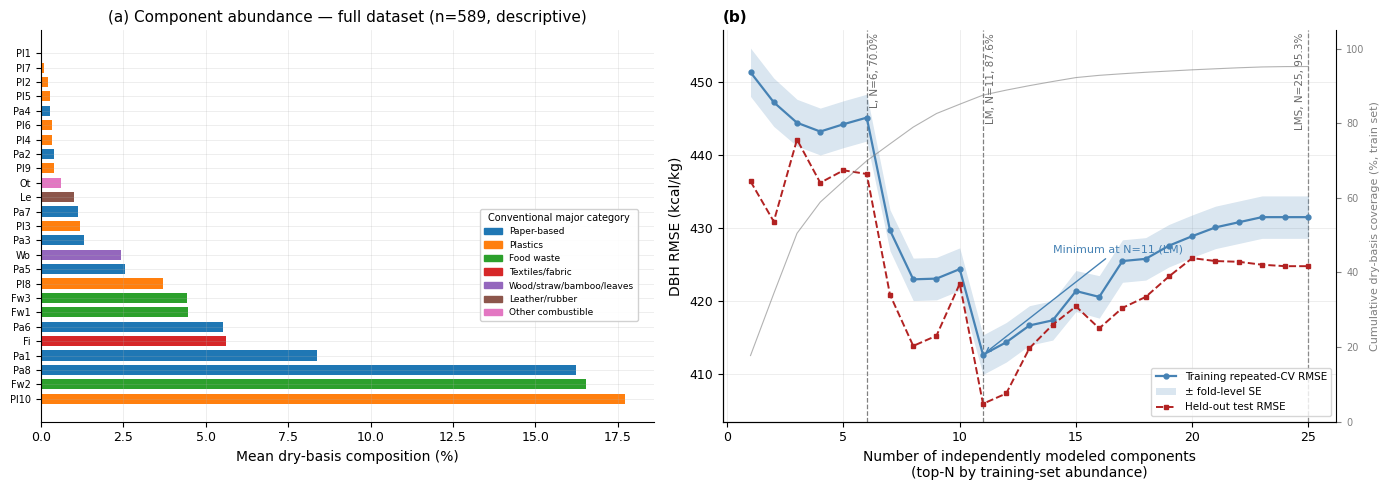

In [ ]:
# ── 3.0  Component abundance, prevalence labels and top-N resolution ───────
# Corresponds to: Figure 1
# Full-dataset component means are used for Figure 1(a). The complete
# descriptive table, including sample standard deviations and wet-basis
# proximate variables, is generated in §7b as Table S2.
#
# TWO abundance tables are computed with clearly separated roles:
#   abundance_train - mean composition of the training set only. All modelling
#       decisions (prevalence labels, top-N ordering, diagnostic component set)
#       derive from this table, so no test-set information enters modelling.
#   abundance_full  - mean composition of the full screened dataset;
#       descriptive only, used for Table S2 and Figure 1(a).

def compute_abundance(df_in, cats):
    '''Mean dry-basis share per composition component with its prevalence
    label (L/M/S); sorted in descending order of abundance.'''
    recs = []
    for code in cats:
        mp = df_in[code].astype(float).mean()
        recs.append({"code": code,
                      "full_name": FINE_CATEGORY_NAMES.get(code, code),
                      "conventional_group": CONVENTIONAL_GROUP_MAP.get(code, ""),
                      "mean_pct": mp, "lms_class": classify_lms(mp)})
    out = (pd.DataFrame.from_records(recs)
             .sort_values("mean_pct", ascending=False).reset_index(drop=True))
    out["cumulative_coverage"] = out["mean_pct"].cumsum()
    return out

abundance_train = compute_abundance(df_train, FINE_CATEGORIES)
abundance_full  = compute_abundance(df_clean, FINE_CATEGORIES)

# All downstream modelling uses the TRAIN-based table.
abundance_df = abundance_train        # modelling alias (train-only)

L_codes  = abundance_train.loc[abundance_train["lms_class"]=="L","code"].tolist()
M_codes  = abundance_train.loc[abundance_train["lms_class"]=="M","code"].tolist()
S_codes  = abundance_train.loc[abundance_train["lms_class"]=="S","code"].tolist()
LM_codes = L_codes + M_codes
n_L, n_LM, n_total = len(L_codes), len(LM_codes), len(FINE_CATEGORIES)
lm_coverage_train = float(
    abundance_train.loc[abundance_train["code"].isin(LM_codes),"mean_pct"].sum())

abundance_train.to_csv(INT_DIR/"category_abundance_train.csv", index=False)
register_output(INT_DIR/"category_abundance_train.csv")
save_table(abundance_full,  "internal_component_abundance_full")
save_table(abundance_train, "internal_component_abundance_training")
print(f"[training set] L={n_L}  M={len(M_codes)}  S={len(S_codes)}  total={n_total}")
print(f"[train-based] LM coverage = {lm_coverage_train:.1f}% of dry mass")
# Flag any component whose L/M/S label differs between train and full data
_cls_tr = dict(zip(abundance_train["code"], abundance_train["lms_class"]))
_cls_fu = dict(zip(abundance_full["code"],  abundance_full["lms_class"]))
_diff   = {c: (_cls_tr[c], _cls_fu[c]) for c in FINE_CATEGORIES
           if _cls_tr[c] != _cls_fu[c]}
print(f"L/M/S class differs between train and full data: "
      f"{_diff if _diff else 'none'}")
display(abundance_train.head(10))

# ── Figure 1: abundance bar (full, descriptive) + coverage curve (train) ────
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel a: horizontal bar by abundance — FULL dataset (descriptive only)
cols_bar = [CONVENTIONAL_GROUP_COLORS.get(CONVENTIONAL_GROUP_MAP.get(c,""), "#aaa")
            for c in abundance_full["code"]]
y_pos = np.arange(len(abundance_full))
ax1.barh(y_pos, abundance_full["mean_pct"], color=cols_bar, edgecolor="none", height=0.7)
ax1.set_yticks(y_pos); ax1.set_yticklabels(abundance_full["code"], fontsize=7)
ax1.set_xlabel("Mean dry-basis composition (%)")
ax1.set_title("(a) Component abundance — full dataset (n=%d, descriptive)"
              % len(df_clean))
group_handles = [mpatches.Patch(color=CONVENTIONAL_GROUP_COLORS[g], label=g)
                 for g in CONVENTIONAL_GROUPS if g in CONVENTIONAL_GROUP_COLORS]
ax1.legend(handles=group_handles, loc="center right", fontsize=6.5,
           title="Conventional major category", title_fontsize=7, framealpha=0.9,
           bbox_to_anchor=(0.98, 0.40))

# Panel b: top-N inclusion performance curve — TRAIN-based ordering
# For each N (1..n_total): top-N components (by training-set mean abundance) as
# individual predictors, remaining components summed into a residual bucket.
# Two curves: train repeated-CV RMSE (with fold-level SE band) and held-out
# test RMSE.  Cumulative coverage is auxiliary (thin line, secondary axis).
ordered_codes = abundance_train["code"].tolist()
_y_tr_f1 = df_train[DBH_COL].astype(float).values
_y_te_f1 = df_test[DBH_COL].astype(float).values
topn_rows = []
for N in range(1, n_total+1):
    inc  = ordered_codes[:N]
    rest = ordered_codes[N:]
    X_tr_n = build_X(df_train, inc, rest if rest else None)
    X_te_n = build_X(df_test,  inc, rest if rest else None)
    cvm_n, _ = fit_ridge_cv(X_tr_n, _y_tr_f1, cv)
    m_n = Ridge(alpha=ALPHA_MAIN, fit_intercept=False).fit(X_tr_n.values, _y_tr_f1)
    te_rmse_n = float(np.sqrt(mean_squared_error(_y_te_f1, m_n.predict(X_te_n.values))))
    cumcov = abundance_train.loc[abundance_train["code"].isin(inc), "mean_pct"].sum()
    topn_rows.append({"N": N,
        "cv_dbh_rmse":    round(cvm_n["cv_dbh_rmse"], 1),
        "cv_dbh_rmse_se": round(cvm_n["cv_dbh_rmse_se"], 1),
        "test_dbh_rmse":  round(te_rmse_n, 1),
        "cumulative_coverage": round(float(cumcov), 2)})
topn_perf_df = pd.DataFrame(topn_rows)
topn_cumcov_df = topn_perf_df[["N","cumulative_coverage"]].copy()  # back-compat
save_table(topn_perf_df, "internal_topN_resolution_performance")

ax2.plot(topn_perf_df["N"], topn_perf_df["cv_dbh_rmse"],
         marker="o", ms=3.5, lw=1.6, color="steelblue",
         label="Training repeated-CV RMSE", zorder=4)
ax2.fill_between(topn_perf_df["N"],
                 topn_perf_df["cv_dbh_rmse"] - topn_perf_df["cv_dbh_rmse_se"],
                 topn_perf_df["cv_dbh_rmse"] + topn_perf_df["cv_dbh_rmse_se"],
                 color="steelblue", alpha=0.20, lw=0,
                 label="± fold-level SE", zorder=2)
ax2.plot(topn_perf_df["N"], topn_perf_df["test_dbh_rmse"],
         marker="s", ms=3.5, lw=1.4, ls="--", color="firebrick",
         label="Held-out test RMSE", zorder=4)

_y_top = ax2.get_ylim()[1]
for marker_N, label in [(n_L,"L"), (n_LM,"LM"), (n_total,"LMS")]:
    _hit = topn_perf_df.loc[topn_perf_df["N"]==marker_N]
    if _hit.empty:      # e.g. n_L=0 on synthetic data
        print(f"  Figure 1(b): marker '{label}' skipped (N={marker_N})")
        continue
    cc = float(_hit["cumulative_coverage"].iloc[0])
    ax2.axvline(marker_N, color="gray", ls="--", lw=0.9, zorder=1)
    _side = -10 if marker_N == n_total else 2   # keep last label inside axes
    ax2.annotate(f"{label}, N={marker_N}, {cc:.1f}%",
                 xy=(marker_N, _y_top), xytext=(_side, -2),
                 textcoords="offset points", fontsize=7.5,
                 rotation=90, va="top", ha="left", color="dimgray")

# Mark the low-RMSE region at LM
if not topn_perf_df.loc[topn_perf_df["N"]==n_LM].empty:
    _lm_cv = float(topn_perf_df.loc[topn_perf_df["N"]==n_LM,"cv_dbh_rmse"].iloc[0])
    ax2.annotate(f"Minimum at N={n_LM} (LM)",
                 xy=(n_LM, _lm_cv), xytext=(n_LM+3.0, _lm_cv+14),
                 fontsize=8, color="steelblue",
                 arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.0))

# Auxiliary: cumulative coverage on a secondary axis (thin line)
ax2c = ax2.twinx()
ax2c.plot(topn_perf_df["N"], topn_perf_df["cumulative_coverage"],
          color="gray", lw=0.8, alpha=0.6)
ax2c.set_ylabel("Cumulative dry-basis coverage (%, train set)",
                fontsize=8, color="gray")
ax2c.tick_params(axis="y", labelsize=7, colors="gray")
ax2c.set_ylim(0, 105)
ax2c.grid(False)
ax2c.spines["right"].set_visible(True)

ax2.set_xlabel("Number of independently modeled components\n(top-N by training-set abundance)")
ax2.set_ylabel("DBH RMSE (kcal/kg)")
ax2.set_title("(b)", loc="left", fontweight="bold")
ax2.legend(fontsize=7.5, loc="lower right")
fig1.tight_layout()

save_figure(fig1, "Figure1_abundance_and_coverage")
plt.show()

In [ ]:
# ── 3.1  Diagnostic Ridge models at L, LM, and LMS resolutions ─────────────
# Corresponds to: Results §3.1-3.2
# These models are reported as diagnostic resolutions. The selected top-N
# resolution is N=11; its correspondence with the LM set is an empirical
# result rather than a threshold-based selection rule.

batch_specs = {
    "L":   {"inc": L_codes,        "res": M_codes + S_codes},
    "LM":  {"inc": LM_codes,       "res": S_codes},
    "LMS": {"inc": FINE_CATEGORIES, "res": None},
}
batch_results, batch_perf_rows, batch_coef_rows = {}, [], []

for mname, spec in batch_specs.items():
    X_tr = build_X(df_train, spec["inc"], spec["res"])
    X_te = build_X(df_test,  spec["inc"], spec["res"])
    metrics, model, coef_df = eval_model(X_tr, X_te, df_train, df_test, cv)
    cstats = coefficient_stats(coef_df)

    cumcov = abundance_df.loc[abundance_df["code"].isin(spec["inc"]),
                              "mean_pct"].sum()
    batch_results[mname] = dict(inc=spec["inc"], res=spec["res"],
                                metrics=metrics, model=model,
                                coef_df=coef_df, cstats=cstats,
                                X_tr=X_tr, X_te=X_te)
    batch_perf_rows.append({"model": mname,
                             "n_included": len(spec["inc"]),
                             "n_residual": len(spec["res"]) if spec["res"] else 0,
                             "coverage_pct": round(cumcov, 2), **metrics})
    for _, row in cstats.iterrows():
        batch_coef_rows.append({"model": mname, **row.to_dict()})

batch_perf_df = pd.DataFrame(batch_perf_rows)
batch_coef_df = pd.DataFrame(batch_coef_rows)
save_table(batch_perf_df, "internal_L_LM_LMS_diagnostic_performance")
save_table(batch_coef_df, "internal_L_LM_LMS_diagnostic_coefficients")
display(batch_perf_df.round(1))

,model,n_included,n_residual,coverage_pct,cv_dbh_rmse,cv_dbh_rmse_se,cv_dbh_rmse_se_rep,cv_dbh_r2,cv_hhv_rmse,cv_hhv_rmse_se,cv_hhv_r2,test_dbh_rmse,test_hhv_rmse,test_hhv_r2,test_hhv_mape
0,L,6,19,70.0,445.1,3.2,0.4,0.3,220.2,0.3,0.7,437.4,213.2,0.6,6.7
1,LM,11,14,87.6,412.7,2.7,0.5,0.4,202.5,0.3,0.7,406.0,196.1,0.7,6.1
2,LMS,25,0,95.3,431.5,2.9,0.7,0.3,213.5,0.4,0.7,424.8,206.3,0.7,6.4


/tmp/ipykernel_1875/3793301905.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


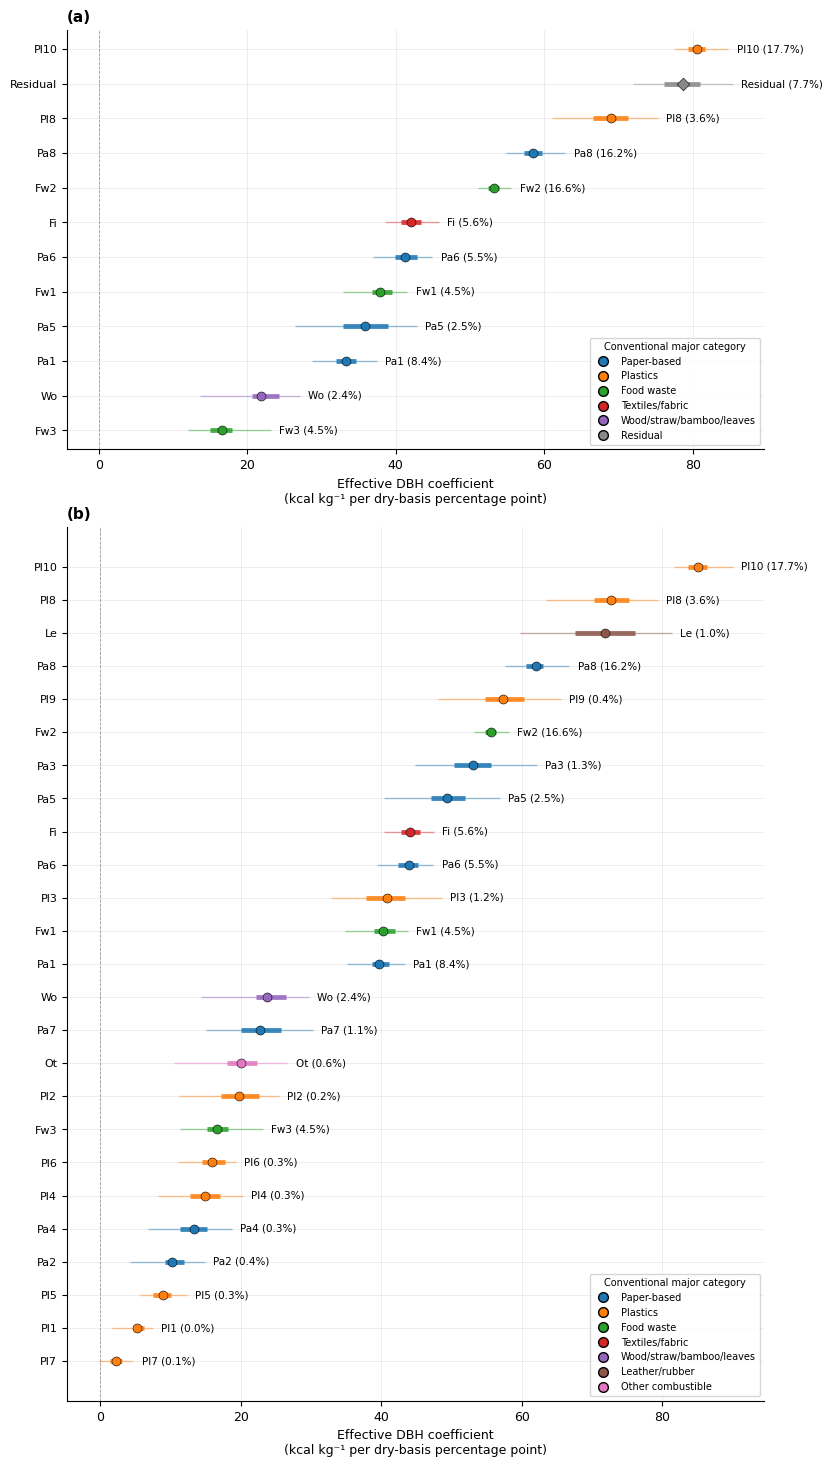

Figure 2 (panels a, b) saved as a single file.


In [ ]:
# ── 3.2  Repeated-CV effective coefficient distributions ───────────────────
# Corresponds to: Figure 2 (panels (a) and (b) in a single file)

OUT_COLS = ["code","conventional_group","mean_pct",
            "coef_mean","coef_sd","coef_q25","coef_q50",
            "coef_q75","coef_p2_5","coef_p97_5","coef_iqr"]

def _enrich(cstats, model_key):
    df = cstats.copy()
    df = df.merge(abundance_df[["code","mean_pct","conventional_group","lms_class"]],
                  on="code", how="left")
    df["category_name"] = df["code"].map(lambda c: FINE_CATEGORY_NAMES.get(c, c))
    df.loc[df["code"]=="Residual","conventional_group"] = "Residual"
    df["model_scope"] = model_key
    return df

def _interval_plot(df_plot, ax, panel_label):
    df_s = df_plot.sort_values("coef_mean").reset_index(drop=True)
    for i, row in df_s.iterrows():
        grp   = row.get("conventional_group","")
        color = "#888" if grp=="Residual" else CONVENTIONAL_GROUP_COLORS.get(grp,"#888")
        mkr   = "D" if grp=="Residual" else "o"
        ax.hlines(i, row["coef_p2_5"], row["coef_p97_5"],
                  color=color, lw=1.0, alpha=0.45, zorder=2)
        ax.hlines(i, row["coef_q25"],  row["coef_q75"],
                  color=color, lw=3.5, alpha=0.85, zorder=3)
        ax.scatter(row["coef_mean"], i, color=color, s=42,
                   edgecolor="black", lw=0.4, zorder=4, marker=mkr)
        pct = f" ({row['mean_pct']:.1f}%)" if pd.notna(row.get("mean_pct")) else ""
        ax.annotate(f"{row['code']}{pct}", xy=(row["coef_p97_5"], i),
                    xytext=(6,0), textcoords="offset points", fontsize=7.5, va="center")
    ax.set_yticks(range(len(df_s)))
    ax.set_yticklabels(df_s["code"].tolist(), fontsize=8)
    ax.axvline(0, color="k", lw=0.6, ls="--", alpha=0.35)
    ax.set_xlabel("Effective DBH coefficient\n(kcal kg⁻¹ per dry-basis percentage point)", fontsize=9)
    # Panel label only — full caption text belongs in the manuscript, not the figure
    ax.set_title(panel_label, fontsize=11, loc="left", fontweight="bold")
    grps = [g for g in list(CONVENTIONAL_GROUP_COLORS)+["Residual"]
            if g in df_s["conventional_group"].values]
    handles = [Line2D([0],[0],marker="o",color="w",markerfacecolor=(
                "#888" if g=="Residual" else CONVENTIONAL_GROUP_COLORS[g]),
                markeredgecolor="k",ms=7,label=g) for g in grps]
    ax.legend(handles=handles, fontsize=7, title="Conventional major category",
              title_fontsize=7, loc="lower right")

# Panel (a) — LM + Residual
fig2a_df = _enrich(batch_results["LM"]["cstats"], "LM+Residual")
lm_plot  = fig2a_df[fig2a_df.get("lms_class","").isin(["L","M"]) |
                     (fig2a_df["code"]=="Residual")].copy()
# Residual-bucket share = summed training-set share of the components that are
# not modelled individually at this diagnostic resolution.
s_pct_sum = abundance_df.loc[abundance_df["lms_class"]=="S","mean_pct"].sum()
lm_plot.loc[lm_plot["code"]=="Residual","mean_pct"] = s_pct_sum

# Panel (b) — LMS
fig2b_df  = _enrich(batch_results["LMS"]["cstats"], "LMS")
lms_plot  = fig2b_df[fig2b_df["code"]!="Residual"].copy()

n2a, n2b = len(lm_plot), len(lms_plot)
fig2 = plt.figure(figsize=(9, max(4.5, n2a*0.5) + max(6, n2b*0.44) + 0.8))
gs2  = fig2.add_gridspec(2, 1, height_ratios=[n2a, n2b], hspace=0.12)
ax2a = fig2.add_subplot(gs2[0]); ax2b = fig2.add_subplot(gs2[1])
_interval_plot(lm_plot,  ax2a, "(a)")
_interval_plot(lms_plot, ax2b, "(b)")
fig2.tight_layout()
save_figure(fig2, "Figure2_coefficient_uncertainty")
plt.show()

tbl2a = [c for c in OUT_COLS if c in fig2a_df.columns]
save_table(fig2a_df[tbl2a].sort_values("coef_mean"), "internal_LM_effective_coefficients")
tbl2b = [c for c in OUT_COLS if c in fig2b_df.columns]
save_table(fig2b_df[tbl2b].sort_values("coef_mean"), "internal_LMS_effective_coefficients")
print("Figure 2 (panels a, b) saved as a single file.")

In [ ]:
# ── 3.3  Within-conventional-major-category heterogeneity ──────────────────
# Corresponds to: Results §3.3; Main Table 1
lm_cs   = batch_results["LM"]["cstats"].copy()
lm_cs   = lm_cs[lm_cs["code"]!="Residual"]
lm_cs   = lm_cs.merge(abundance_df[["code","mean_pct"]], on="code", how="left")
lm_cs["conventional_group"] = lm_cs["code"].map(CONVENTIONAL_GROUP_MAP)

ranked  = lm_cs.sort_values("coef_mean").reset_index(drop=True)
ranked["rank"] = np.arange(1, len(ranked)+1)
rank_map = dict(zip(ranked["code"], ranked["rank"]))

table3_rows = []
for group, members in CONVENTIONAL_GROUPS.items():
    sub = lm_cs[lm_cs["code"].isin(members)]
    if len(sub) < 2: continue
    coef_min_code = sub.loc[sub["coef_mean"].idxmin(),"code"]
    coef_max_code = sub.loc[sub["coef_mean"].idxmax(),"code"]
    coef_min = float(sub["coef_mean"].min())
    coef_max = float(sub["coef_mean"].max())
    range_G  = coef_max - coef_min
    rank_span = abs(rank_map[coef_max_code] - rank_map[coef_min_code])
    mp_grp   = float(sub["mean_pct"].sum())
    table3_rows.append({
        "conventional_group": group, "n_codes": len(sub),
        "mean_pct_group": round(mp_grp,2),
        "coef_min": round(coef_min,2), "coef_min_code": coef_min_code,
        "coef_max": round(coef_max,2), "coef_max_code": coef_max_code,
        "Range_G": round(range_G,2), "RankSpan_G": int(rank_span),
        "I_LM_G": round(range_G*mp_grp,3),
    })
table3_df = (pd.DataFrame(table3_rows)
             .sort_values("I_LM_G",ascending=False).reset_index(drop=True))
save_table(table3_df, "internal_within_major_category_heterogeneity")
display(table3_df)

,conventional_group,n_codes,mean_pct_group,coef_min,coef_min_code,coef_max,coef_max_code,Range_G,RankSpan_G,I_LM_G
0,Food waste,3,25.69,16.63,Fw3,53.23,Fw2,36.60,7,940.290
1,Paper-based,4,32.50,33.32,Pa1,58.49,Pa8,25.16,6,817.871
2,Plastics,2,21.34,68.99,Pl8,80.61,Pl10,11.62,1,247.983


,K,cv_dbh_rmse,cv_dbh_rmse_se,cv_dbh_rmse_se_rep,gamma_values,monotonic,min_group_share
0,2,431.9,3.2,0.2,38.5;62.3,True,33.46
1,3,415.1,2.9,0.2,35.9;54.7;78.7,True,21.34
2,4,407.4,2.8,0.2,16.7;40.8;53.9;80.0,True,6.98
3,5,409.9,2.7,0.2,18.1;41.6;54.5;65.0;79.5,True,3.63
4,6,410.1,2.7,0.3,18.8;36.4;42.8;55.0;65.6;79.9,True,3.63
5,7,410.6,2.6,0.4,18.8;36.1;42.5;53.0;57.2;66.6;79.8,True,3.63


Candidates (monotonic & min share >= 1.5%): [2, 3, 4, 5, 6, 7]
K_best = 4  (RMSE_min = 407.4 kcal/kg)
  tolerance 1%: threshold 411.5  near-best [4, 5, 6, 7]  -> K_selected = 4
  tolerance 2%: threshold 415.5  near-best [3, 4, 5, 6, 7]  -> K_selected = 3
  tolerance 3%: threshold 419.6  near-best [3, 4, 5, 6, 7]  -> K_selected = 3
LM-stage practical-equivalence result (MAIN_K_TOLERANCE = 1%): LM_RECOMMENDED_K = 4
Diagnostic-stage result; the operational K is selected in §3.4c after component allocation.


,K,cv_dbh_rmse,delta_rmse_vs_min,delta_rmse_pct,monotonic,min_group_share,within_1pct,within_2pct,within_3pct
0,2,431.9,24.5,6.02,True,33.46,False,False,False
1,3,415.1,7.7,1.90,True,21.34,False,True,True
2,4,407.4,0.0,0.00,True,6.98,True,True,True
3,5,409.9,2.5,0.61,True,3.63,True,True,True
4,6,410.1,2.7,0.67,True,3.63,True,True,True
5,7,410.6,3.2,0.78,True,3.63,True,True,True


K=4: test DBH RMSE=405.8  test HHV RMSE=194.9  test HHV R2=0.705
Conventional seven-category model: test DBH RMSE=420.5  HHV R2=0.682
K=4 vs 7C test DBH RMSE difference: -14.6 kcal/kg


,model,test_dbh_rmse,test_hhv_rmse,test_hhv_r2
0,Diagnostic K=4 segmentation,405.8,194.9,0.705
1,Conventional 7 major categories,420.5,202.5,0.682


/tmp/ipykernel_1875/1512340347.py:379: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig3.tight_layout()


Figure 3 caption: Figure 3. Abundance-weighted contiguous segmentation and operational regrouping.
(a) LM components are ordered by their mean repeated-CV effective coefficients. Values beneath the points denote mean component coefficients, β̄j, whereas values beneath the segmentation brackets denote refitted thermal-group coefficients, γg. Point size is proportional to training-set mean share. The red Op-4 row shows the complete four-group operational model after deterministic allocation of S components.
(b) Mean refitted group coefficients and empirical 2.5th-97.5th percentile ranges across repeated CV fits; percentages denote training-set mean group shares. Per-component operational mapping is provided in Supplementary S2.


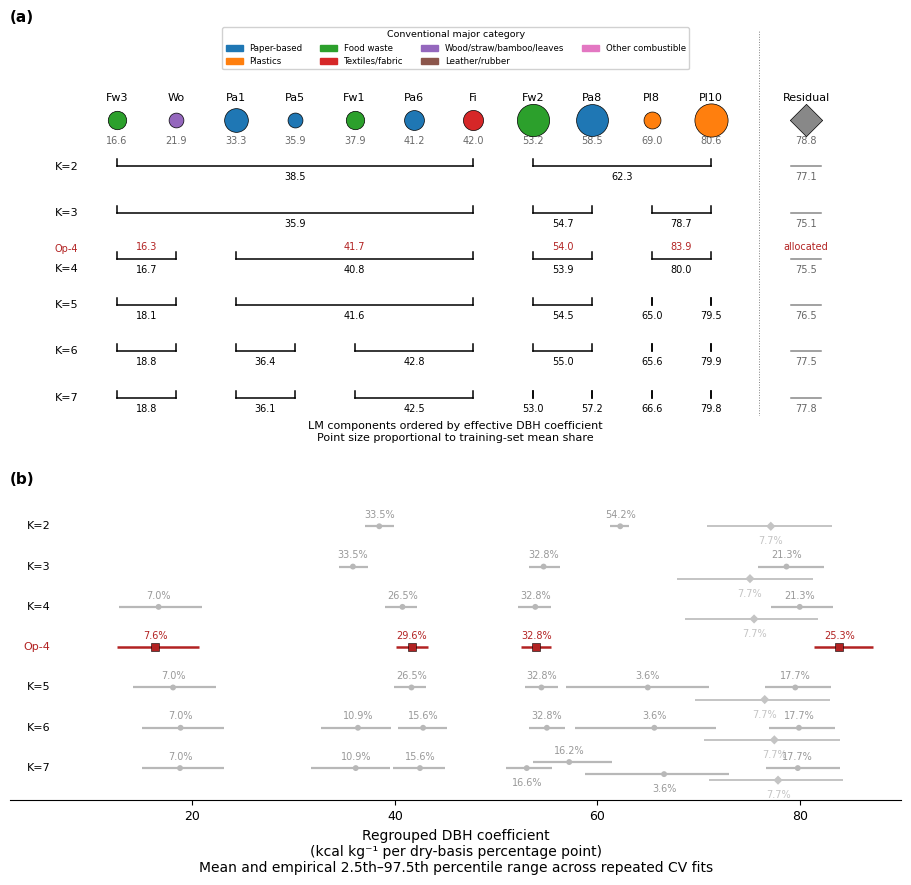

In [ ]:
# ── 3.4  Abundance-weighted contiguous segmentation, K=2-7 ─────────────────
# Corresponds to: Results §3.4; Main Table 2; Figure 3
#
# Diagnostic segmentation stage: the LM diagnostic components are segmented into
# candidate thermal groups, with the remaining components represented by a
# temporary residual bucket. The complete operational regrouping in §3.4c then
# allocates those components and removes the residual predictor.
#
# K selection uses training-set information only: candidate K must show a
# monotonic coefficient sequence and satisfy the minimum group-share constraint,
# and is chosen by the practical-equivalence tolerance rule.
# Test RMSE is computed ONCE, after K is fixed.  The comparison against the
# conventional seven-category model is reported afterwards and never used for
# selection.

_lm_sorted = (batch_results["LM"]["cstats"].query("code!='Residual'")
              .sort_values("coef_mean").reset_index(drop=True))
ordered_codes_lm = _lm_sorted["code"].tolist()
coef_means_lm    = _lm_sorted["coef_mean"].tolist()

regroup_results = {}
table4_rows, membership_rows = [], []
y_dbh_tr_all = df_train[DBH_COL].astype(float).values
_share_map_main = dict(zip(abundance_train["code"], abundance_train["mean_pct"]))

for K in K_RANGE:
    groups, cutpoints = seg_groups(ordered_codes_lm, coef_means_lm, K,
                                    _share_map_main, context="main-3.4")
    J_K = seg_groups.last_J
    groups_dict = {f"Group{i}": m for i, m in enumerate(groups, 1)}
    if S_codes:
        groups_dict["Residual"] = S_codes

    X_tr_k = build_X_groups(df_train, groups_dict)
    X_te_k = build_X_groups(df_test,  groups_dict)   # built here, evaluated ONLY after K is fixed

    # Training-set CV only — no test information used for selection
    cv_metrics, coef_df = fit_ridge_cv(X_tr_k, y_dbh_tr_all, cv)
    cstats = coefficient_stats(coef_df)

    group_shares = [float(abundance_train.loc[abundance_train["code"].isin(m),
                                              "mean_pct"].sum()) for m in groups]
    gamma_means  = [float(cstats.loc[cstats["code"]==f"Group{i}","coef_mean"].iloc[0])
                    for i in range(1, K+1)]
    mono = is_monotonic(gamma_means)

    regroup_results[K] = dict(groups=groups, cutpoints=cutpoints, J_K=J_K,
                               metrics=dict(cv_metrics), model=None,
                               coef_df=coef_df, cstats=cstats,
                               gamma_means=gamma_means, monotonic=mono,
                               group_shares=group_shares,
                               X_tr=X_tr_k, X_te=X_te_k)

    table4_rows.append({"K": K,
        "cv_dbh_rmse":        round(cv_metrics["cv_dbh_rmse"],1),
        "cv_dbh_rmse_se":     round(cv_metrics["cv_dbh_rmse_se"],1),      # fold-level (operational)
        "cv_dbh_rmse_se_rep": round(cv_metrics["cv_dbh_rmse_se_rep"],1),  # repeat-level (parallel)
        "gamma_values": ";".join(f"{g:.1f}" for g in gamma_means),
        "monotonic": mono,
        "min_group_share": round(min(group_shares),2)})

    for gi, (members, share, gm) in enumerate(zip(groups, group_shares, gamma_means), 1):
        row_base = cstats.loc[cstats["code"]==f"Group{gi}"].iloc[0]
        membership_rows.append({"K":K,"group":f"Group{gi}","n_members":len(members),
            "members":",".join(members),"share_pct":round(share,2),
            **{c:round(float(row_base[c]),1) for c in
               ["coef_mean","coef_sd","coef_q25","coef_q75","coef_p2_5","coef_p97_5"]}})
    if S_codes:
        rr = cstats.loc[cstats["code"]=="Residual"].iloc[0]
        res_share = float(abundance_train.loc[abundance_train["code"].isin(S_codes),
                                              "mean_pct"].sum())
        membership_rows.append({"K":K,"group":"Residual","n_members":len(S_codes),
            "members":",".join(S_codes),"share_pct":round(res_share,2),
            **{c:round(float(rr[c]),1) for c in
               ["coef_mean","coef_sd","coef_q25","coef_q75","coef_p2_5","coef_p97_5"]}})

table4_df     = pd.DataFrame(table4_rows)
membership_df = pd.DataFrame(membership_rows)
save_table(table4_df, "internal_diagnostic_regrouping_performance")
save_table(membership_df, "internal_regrouping_membership")
display(table4_df)

# ── Recommend K — practical-equivalence tolerance (shared selector) ─────────
RECOMMENDED_K_OVERRIDE = None
MIN_GROUP_SHARE_THR    = MIN_GROUP_SHARE

cands = [K for K in K_RANGE
         if regroup_results[K]["monotonic"]
         and min(regroup_results[K]["group_shares"]) >= MIN_GROUP_SHARE_THR]
if not cands:
    cands = [K for K in K_RANGE if regroup_results[K]["monotonic"]]
if not cands:
    cands = list(K_RANGE)

_cv_by_K = {K: regroup_results[K]["metrics"]["cv_dbh_rmse"] for K in K_RANGE}
K_SELECTION = select_k_by_tolerance(_cv_by_K, cands, K_TOLERANCES)
K_best   = K_SELECTION["K_best"]
RMSE_min = K_SELECTION["rmse_min"]
if RECOMMENDED_K_OVERRIDE:
    RECOMMENDED_K = RECOMMENDED_K_OVERRIDE
else:
    RECOMMENDED_K = K_SELECTION["by_tol"][MAIN_K_TOLERANCE]["K_selected"]

print(f"Candidates (monotonic & min share >= {MIN_GROUP_SHARE_THR}%): {cands}")
print(f"K_best = {K_best}  (RMSE_min = {RMSE_min:.1f} kcal/kg)")
for t in K_TOLERANCES:
    r = K_SELECTION["by_tol"][t]
    print(f"  tolerance {t:.0%}: threshold {r['threshold']:.1f}  "
          f"near-best {r['near_best_K']}  -> K_selected = {r['K_selected']}")
LM_RECOMMENDED_K = RECOMMENDED_K   # diagnostic-stage result
print(f"LM-stage practical-equivalence result (MAIN_K_TOLERANCE = "
      f"{MAIN_K_TOLERANCE:.0%}): LM_RECOMMENDED_K = {LM_RECOMMENDED_K}")
print("Diagnostic-stage result; the operational K is selected in §3.4c "
      "after component allocation.")

# selection summary table (saved for the paper's sensitivity analysis)
sel_rows = []
for K in K_RANGE:
    rmse_K = _cv_by_K[K]
    row = {"K": K, "cv_dbh_rmse": round(rmse_K, 1),
           "delta_rmse_vs_min": round(rmse_K - RMSE_min, 1),
           "delta_rmse_pct": round(100.0 * (rmse_K - RMSE_min) / RMSE_min, 2),
           "monotonic": regroup_results[K]["monotonic"],
           "min_group_share": round(min(regroup_results[K]["group_shares"]), 2)}
    for t in K_TOLERANCES:
        row[f"within_{int(t*100)}pct"] = (K in cands and
            rmse_K <= K_SELECTION["by_tol"][t]["threshold"])
    sel_rows.append(row)
k_selection_df = pd.DataFrame(sel_rows)
save_table(k_selection_df, "internal_diagnostic_K_resolution")
display(k_selection_df)

# ── Test evaluation — computed ONCE, only for the selected K ────────────────
rec_metrics, rec_model, rec_coef_df = eval_model(
    regroup_results[RECOMMENDED_K]["X_tr"],
    regroup_results[RECOMMENDED_K]["X_te"],
    df_train, df_test, cv)
regroup_results[RECOMMENDED_K]["metrics"] = rec_metrics   # cv + test metrics
regroup_results[RECOMMENDED_K]["model"]   = rec_model
print(f"K={RECOMMENDED_K}: test DBH RMSE={rec_metrics['test_dbh_rmse']:.1f}  "
      f"test HHV RMSE={rec_metrics['test_hhv_rmse']:.1f}  "
      f"test HHV R2={rec_metrics['test_hhv_r2']:.3f}")

# ── Traditional 7-group model — FINAL-REPORT comparison only ────────────────
X_tr_7c = build_X_groups(df_train, {g: m for g, m in CONVENTIONAL_GROUPS.items()})
X_te_7c = build_X_groups(df_test,  {g: m for g, m in CONVENTIONAL_GROUPS.items()})
trad_metrics, trad_model, trad_coef_df = eval_model(
    X_tr_7c, X_te_7c, df_train, df_test, cv)
trad_cstats = coefficient_stats(trad_coef_df)
save_table(trad_cstats, "internal_seven_category_coefficients")
print(f"Conventional seven-category model: test DBH RMSE={trad_metrics['test_dbh_rmse']:.1f}  "
      f"HHV R2={trad_metrics['test_hhv_r2']:.3f}")
print(f"K={RECOMMENDED_K} vs 7C test DBH RMSE difference: "
      f"{rec_metrics['test_dbh_rmse'] - trad_metrics['test_dbh_rmse']:+.1f} kcal/kg")

final_comp_df = pd.DataFrame([
    {"model": f"Diagnostic K={RECOMMENDED_K} segmentation",
     "test_dbh_rmse": round(rec_metrics["test_dbh_rmse"],1),
     "test_hhv_rmse": round(rec_metrics["test_hhv_rmse"],1),
     "test_hhv_r2":   round(rec_metrics["test_hhv_r2"],3)},
    {"model": "Conventional 7 major categories",
     "test_dbh_rmse": round(trad_metrics["test_dbh_rmse"],1),
     "test_hhv_rmse": round(trad_metrics["test_hhv_rmse"],1),
     "test_hhv_r2":   round(trad_metrics["test_hhv_r2"],3)},
])
save_table(final_comp_df, "internal_final_model_comparison")
display(final_comp_df)

# Figure 3 shows both analytical layers: panel (a) reports the diagnostic
# thermal-group coefficients below each bracket and the operational four-group
# coefficients above the K=4 brackets; panel (b) compares the diagnostic
# coefficient distributions for K=2-7 with the operational four-group model.
# Operational values are taken from §3.4c when available, otherwise they are
# computed here with the same shared functions.
if "operational_results" in globals() and 4 in operational_results:
    _op4_gamma  = operational_results[4]["gamma"]
    _op4_shares = operational_results[4]["shares"]
    _op4_cs     = operational_results[4]["cstats"]
else:
    _op4_groups_f3, _ = complete_operational_from_lm(
        [list(m) for m in regroup_results[4]["groups"]],
        df_train, abundance_train, S_codes)
    _op4_gd_f3 = {f"Group{i}": m for i, m in enumerate(_op4_groups_f3, 1)}
    _, _op4_cdf = fit_ridge_cv(build_X_groups(df_train, _op4_gd_f3),
                                y_dbh_tr_all, cv)
    _op4_cs = coefficient_stats(_op4_cdf)
    _op4_gamma = [float(_op4_cs.loc[_op4_cs["code"]==f"Group{i}","coef_mean"].iloc[0])
                  for i in range(1, 5)]
    _op4_shares = [float(abundance_train.loc[abundance_train["code"].isin(m),
                                              "mean_pct"].sum())
                   for m in _op4_groups_f3]

# ── Figure 3: (a) LM coefficient-ordered axis with K=2–7 brackets;
#              (b) recommended-K coefficient ladder ──────────────────────────
_lm_ax = _lm_sorted.merge(abundance_train[["code","mean_pct"]], on="code", how="left")
n_lmx  = len(_lm_ax)
xpos   = {c: i+1 for i, c in enumerate(ordered_codes_lm)}
x_res  = n_lmx + 1.6
_res_share   = float(abundance_train.loc[abundance_train["code"].isin(S_codes),
                                          "mean_pct"].sum())
HAS_RESIDUAL = bool(S_codes)
_res_coef_by_K = {K: (float(regroup_results[K]["cstats"]
                            .query("code=='Residual'")["coef_mean"].iloc[0])
                       if HAS_RESIDUAL else np.nan) for K in K_RANGE}
_res_coef_lm = (float(batch_results["LM"]["cstats"]
                       .query("code=='Residual'")["coef_mean"].iloc[0])
                if HAS_RESIDUAL else np.nan)

fig3 = plt.figure(figsize=(11.5, 10))
gs3  = fig3.add_gridspec(2, 1, height_ratios=[1.25, 1.0], hspace=0.22)
ax3a = fig3.add_subplot(gs3[0])

# top row: LM diagnostic components at rank positions; point size ∝ train mean share
y0 = 0.0
for _, r in _lm_ax.iterrows():
    grp = CONVENTIONAL_GROUP_MAP.get(r["code"], "")
    col = CONVENTIONAL_GROUP_COLORS.get(grp, "#888")
    ax3a.scatter(xpos[r["code"]], y0, s=40 + float(r["mean_pct"])*30,
                 color=col, edgecolor="black", lw=0.5, zorder=4)
    ax3a.annotate(r["code"], xy=(xpos[r["code"]], y0), xytext=(0, 14),
                  textcoords="offset points", ha="center", fontsize=8)
    ax3a.annotate(f"{r['coef_mean']:.1f}", xy=(xpos[r["code"]], y0),
                  xytext=(0, -17), textcoords="offset points",
                  ha="center", fontsize=7, color="dimgray")
# residual aggregate — rightmost slot (skipped when no allocated components)
if HAS_RESIDUAL:
    ax3a.scatter(x_res, y0, s=40 + _res_share*30, marker="D", color="#888",
                 edgecolor="black", lw=0.5, zorder=4)
    ax3a.annotate("Residual", xy=(x_res, y0), xytext=(0, 14),
                  textcoords="offset points", ha="center", fontsize=8)
    ax3a.annotate(f"{_res_coef_lm:.1f}", xy=(x_res, y0), xytext=(0, -17),
                  textcoords="offset points", ha="center", fontsize=7, color="dimgray")
    ax3a.axvline(n_lmx + 0.8, color="gray", lw=0.7, ls=":")

# K=3–7 bracket rows with per-group gamma (kcal/kg per %, 1 decimal)
for ki, K in enumerate(K_RANGE, start=1):
    y = -ki * 0.9
    for _gi_f3, (mem, gm) in enumerate(zip(regroup_results[K]["groups"],
                        regroup_results[K]["gamma_means"])):
        xs = [xpos[c] for c in mem]
        xa, xb = float(min(xs)), float(max(xs))   # exact alignment with points
        ax3a.plot([xa, xb], [y, y], color="black", lw=1.1)
        ax3a.plot([xa, xa], [y, y + 0.14], color="black", lw=1.1)
        ax3a.plot([xb, xb], [y, y + 0.14], color="black", lw=1.1)
        ax3a.annotate(f"{gm:.1f}", xy=((xa + xb) / 2.0, y), xytext=(0, -10),
                      textcoords="offset points", ha="center", fontsize=7)
        if K == 4:   # red Op-4 terminal gamma ABOVE the bracket
            ax3a.annotate(f"{_op4_gamma[_gi_f3]:.1f}",
                          xy=((xa + xb) / 2.0, y), xytext=(0, 5),
                          textcoords="offset points", ha="center",
                          va="bottom", fontsize=7, color="firebrick")
    if HAS_RESIDUAL:
        gR = _res_coef_by_K[K]
        ax3a.plot([x_res - 0.25, x_res + 0.25], [y, y], color="#888", lw=1.1)
        ax3a.annotate(f"{gR:.1f}", xy=(x_res, y), xytext=(0, -10),
                      textcoords="offset points", ha="center", fontsize=7,
                      color="#666")
        if K == 4:   # allocated components allocated into the four terminal groups
            ax3a.annotate("allocated", xy=(x_res, y), xytext=(0, 5),
                          textcoords="offset points", ha="center",
                          va="bottom", fontsize=7, color="firebrick")
    if K == 4:
        # match the value stacking: red Op-4 label ABOVE, black K=4 label BELOW
        ax3a.annotate("Op-4", xy=(0.35, y + 0.20), ha="right", va="center",
                      fontsize=7, color="firebrick")
        ax3a.annotate(f"K={K}", xy=(0.35, y - 0.20), ha="right", va="center",
                      fontsize=8)
    else:
        ax3a.annotate(f"K={K}", xy=(0.35, y), ha="right", va="center", fontsize=8)

group_handles = [mpatches.Patch(color=CONVENTIONAL_GROUP_COLORS[g], label=g)
                 for g in CONVENTIONAL_GROUPS]
ax3a.legend(handles=group_handles, fontsize=6.2, loc="upper center",
            title="Conventional major category", title_fontsize=6.8, ncol=4,
            framealpha=0.9, bbox_to_anchor=(0.5, 1.02))
ax3a.set_xlim(-0.8, x_res + 1.6)   # extra right margin: keep Residual label unclipped
ax3a.set_ylim(-(len(K_RANGE)) * 0.9 - 0.35, 1.75)
ax3a.set_yticks([]); ax3a.set_xticks([])
for _sp in ax3a.spines.values(): _sp.set_visible(False)
ax3a.grid(False)
ax3a.set_title("(a)", loc="left", fontweight="bold", fontsize=11)
ax3a.set_xlabel("LM components ordered by effective DBH coefficient\n"
                "Point size proportional to training-set mean share",
                fontsize=8)

# panel (b): K=3–7 rows — per-group coefficient points with 2.5–97.5
# percentile bars (repeated CV fits); K=4 emphasised, residual gray at right
ax3b = fig3.add_subplot(gs3[1])
# rows: K=2..4 top, red Op-4 row inserted between K=4 and K=5
_row_y = {2: 7, 3: 6, 4: 5, 5: 3, 6: 2, 7: 1}
_OP4_Y = 4

for K in K_RANGE:
    yb = _row_y[K]
    emph = False   # all diagnostic K rows gray; only the Op-4 row is coloured
    c_pt  = "steelblue" if emph else "#b8b8b8"
    c_lab = "black"     if emph else "#999999"
    c_res = "#666666"   if emph else "#c4c4c4"
    cs_K  = regroup_results[K]["cstats"]
    shares_K = regroup_results[K]["group_shares"]

    # vertical offsets to avoid full overlap of adjacent intervals
    ivals, offs = [], []
    for gi in range(1, K + 1):
        rW = cs_K.loc[cs_K["code"] == f"Group{gi}"].iloc[0]
        ivals.append((float(rW["coef_p2_5"]), float(rW["coef_p97_5"])))
    prev_off = 0.0
    for gi in range(K):
        if gi > 0 and ivals[gi][0] <= ivals[gi-1][1]:   # overlaps previous
            off = 0.15 if prev_off <= 0 else -0.15
        else:
            off = 0.0
        offs.append(off); prev_off = off

    for gi in range(1, K + 1):
        rW = cs_K.loc[cs_K["code"] == f"Group{gi}"].iloc[0]
        yy = yb + offs[gi-1]
        ax3b.hlines(yy, rW["coef_p2_5"], rW["coef_p97_5"],
                    color=c_pt, lw=1.6, zorder=3)
        ax3b.scatter(rW["coef_mean"], yy, s=26 if emph else 18,
                     color=c_pt, edgecolor="black" if emph else "none",
                     lw=0.4, zorder=4)
        # train-set share label: above the segment, or below when this
        # group is offset downward OR its next neighbour is raised into the
        # space above it (avoids label/segment collisions)
        _below = offs[gi-1] < 0
        if gi < K and offs[gi] > 0 and ivals[gi][0] <= ivals[gi-1][1]:
            _below = True
        _dy = -13 if _below else 6
        ax3b.annotate(f"{shares_K[gi-1]:.1f}%",
                      xy=(float(rW["coef_mean"]), yy), xytext=(0, _dy),
                      textcoords="offset points", ha="center",
                      fontsize=7, color=c_lab, zorder=5)
    # residual — gray, right end; offset down if it overlaps the last group
    if not HAS_RESIDUAL or not (cs_K["code"] == "Residual").any():
        continue
    rR = cs_K.loc[cs_K["code"] == "Residual"].iloc[0]
    y_res = yb
    if float(rR["coef_p2_5"]) <= ivals[-1][1]:
        y_res = yb - 0.30      # clear both the base row and any -0.15 group
    ax3b.hlines(y_res, rR["coef_p2_5"], rR["coef_p97_5"],
                color=c_res, lw=1.4, ls="-", zorder=2)
    ax3b.scatter(rR["coef_mean"], y_res, s=22, marker="D", color=c_res,
                 edgecolor="black" if emph else "none", lw=0.4, zorder=3)
    ax3b.annotate(f"{_res_share:.1f}%",
                  xy=(float(rR["coef_mean"]), y_res), xytext=(0, -13),
                  textcoords="offset points", ha="center",
                  fontsize=7, color=c_res, zorder=5)

# ── red Op-4 row: terminal four-group model (no Residual point) ─────────────
for _gi_f3 in range(1, 5):
    _rW = _op4_cs.loc[_op4_cs["code"] == f"Group{_gi_f3}"].iloc[0]
    ax3b.hlines(_OP4_Y, _rW["coef_p2_5"], _rW["coef_p97_5"],
                color="firebrick", lw=1.8, zorder=4)
    ax3b.scatter(_rW["coef_mean"], _OP4_Y, s=30, marker="s",
                 color="firebrick", edgecolor="black", lw=0.4, zorder=5)
    ax3b.annotate(f"{_op4_shares[_gi_f3-1]:.1f}%",
                  xy=(float(_rW["coef_mean"]), _OP4_Y), xytext=(0, 6),
                  textcoords="offset points", ha="center",
                  fontsize=7, color="firebrick", zorder=6)

# K row labels drawn as in panel (a); no y-axis, no zero line/tick
ax3b.set_yticks([])
for K in K_RANGE:
    ax3b.annotate(f"K={K}", xy=(6.0, _row_y[K]), ha="right", va="center",
                  fontsize=8)
ax3b.annotate("Op-4", xy=(6.0, _OP4_Y), ha="right", va="center",
              fontsize=8, color="firebrick")
ax3b.set_ylim(0.2, len(K_RANGE) + 1.85)
ax3b.set_xlim(2, 90)
ax3b.set_xticks([20, 40, 60, 80])
for _sp in ax3b.spines.values(): _sp.set_visible(False)
ax3b.spines["bottom"].set_visible(True)
ax3b.grid(False)
ax3b.set_xlabel("Regrouped DBH coefficient\n"
                "(kcal kg⁻¹ per dry-basis percentage point)\n"
                "Mean and empirical 2.5th–97.5th percentile range across repeated CV fits")
ax3b.set_title("(b)", loc="left", fontweight="bold", fontsize=11)
fig3.tight_layout()
FIGURE3_CAPTION = (
    "Figure 3. Abundance-weighted contiguous segmentation and operational "
    "regrouping.\n"
    "(a) LM components are ordered by their mean repeated-CV effective "
    "coefficients. Values beneath the points denote mean component coefficients, "
    "\u03b2\u0304j, whereas values beneath the segmentation brackets denote refitted "
    "thermal-group coefficients, \u03b3g. Point size is proportional to training-set "
    "mean share. The red Op-4 row shows the complete four-group operational model "
    "after deterministic allocation of S components.\n"
    "(b) Mean refitted group coefficients and empirical 2.5th-97.5th percentile "
    "ranges across repeated CV fits; percentages denote training-set mean group "
    "shares. Per-component operational mapping is provided in Supplementary S2.")
print("Figure 3 caption:", FIGURE3_CAPTION)
save_figure(fig3, "Figure3_regrouping")
plt.show()

### 3.4c Complete operational allocation and K selection

Every remaining composition component is allocated to a thermal group by two
prespecified deterministic rules:

- **R1** — components whose conventional major category already contains
  diagnostic anchors are assigned to the group holding the largest summed
  training-set share of those anchors.
- **R2** — components without a diagnostic anchor are assigned to the group
  whose coefficient is closest to the corresponding seven-category effective
  coefficient estimated on the training set.

Each candidate K therefore yields K terminal operational groups covering all 25
composition components with no residual predictor. K is selected from the
complete operational models using training cross-validation only; test-set
metrics are reported after selection is complete.

In [ ]:
# ── 3.4c  Complete operational allocation and K selection (K=2-7) ──────────
# Corresponds to: Table S4
# Deterministic allocation applied to every candidate K, producing K terminal
# operational groups with no residual predictor, followed by refitting, repeated
# cross-validation and practical-equivalence selection.
# All allocation decisions use training data only; test-set results are reported
# after selection and never participate in allocation or in the choice of K.

def build_complete_operational_groups(K):
    '''Diagnostic thermal groups for candidate K plus deterministic allocation,
    giving K terminal operational groups covering all 25 components.'''
    # G: single shared implementation — full-fit anchors on the main training set
    lm_groups = [list(m) for m in regroup_results[K]["groups"]]
    return complete_operational_from_lm(lm_groups, df_train, abundance_train,
                                         S_codes)

_y_te_do = df_test[DBH_COL].astype(float).values
_total_comb_share = float(abundance_train["mean_pct"].sum())

operational_results = {}
op_rows = []
for K in K_RANGE:
    groups_op, alloc_op = build_complete_operational_groups(K)
    # R-checks 1/2/4/11: exact cover, no Residual bucket, non-empty, K terminal
    _flat = [c for m in groups_op for c in m]
    assert sorted(_flat) == sorted(FINE_CATEGORIES), (
        f"K={K}: components are not covered exactly once")
    assert len(groups_op) == K and all(len(m) > 0 for m in groups_op), \
        f"K={K}: expected {K} non-empty terminal groups"
    gd_op = {f"Group{i}": m for i, m in enumerate(groups_op, 1)}   # NO Residual
    X_tr_op = build_X_groups(df_train, gd_op)
    X_te_op = build_X_groups(df_test,  gd_op)
    met_op, model_op, coef_op = eval_model(X_tr_op, X_te_op, df_train, df_test, cv)
    cs_op  = coefficient_stats(coef_op)
    gam_op = [float(cs_op.loc[cs_op["code"] == f"Group{i}", "coef_mean"].iloc[0])
              for i in range(1, K + 1)]
    mono_op   = is_monotonic(gam_op)
    shares_op = [float(abundance_train.loc[abundance_train["code"].isin(m),
                                            "mean_pct"].sum()) for m in groups_op]
    # R-check 3: shares sum to total combustible dry-basis share
    assert abs(sum(shares_op) - _total_comb_share) < 1e-6, f"K={K}: share sum mismatch"
    operational_results[K] = dict(groups=groups_op, alloc=alloc_op, gd=gd_op,
                                   metrics=met_op, model=model_op, cstats=cs_op,
                                   gamma=gam_op, monotonic=mono_op,
                                   shares=shares_op)
    op_rows.append({"K": K, "n_terminal_groups": len(groups_op),
        "cv_dbh_rmse":  round(met_op["cv_dbh_rmse"], 1),
        "cv_hhv_rmse":  round(met_op["cv_hhv_rmse"], 1),
        "test_dbh_rmse":round(met_op["test_dbh_rmse"], 1),
        "test_hhv_rmse":round(met_op["test_hhv_rmse"], 1),
        "test_hhv_r2":  round(met_op["test_hhv_r2"], 3),
        "test_hhv_mape":round(met_op["test_hhv_mape"], 2),
        "gamma_values": ";".join(f"{g:.1f}" for g in gam_op),
        "monotonic": mono_op,
        "group_shares": ";".join(f"{s_:.1f}" for s_ in shares_op),
        "min_group_share": round(min(shares_op), 2)})

op_df = pd.DataFrame(op_rows)
_op_min = float(op_df["cv_dbh_rmse"].min())
op_df["delta_cv_rmse"] = (op_df["cv_dbh_rmse"] - _op_min).round(1)
op_df["delta_cv_pct"]  = (100.0 * (op_df["cv_dbh_rmse"] - _op_min) / _op_min).round(2)

# ── Operational practical-equivalence selection (F/Q: SAME shared selector,
#    same K_TOLERANCES; no one-SE, no test involvement) ─────────────────────
op_feasible = [K for K in K_RANGE
               if operational_results[K]["monotonic"]
               and min(operational_results[K]["shares"]) >= MIN_GROUP_SHARE]
if not op_feasible:
    op_feasible = [K for K in K_RANGE if operational_results[K]["monotonic"]]
if not op_feasible:
    op_feasible = list(K_RANGE)
_op_cv = {K: operational_results[K]["metrics"]["cv_dbh_rmse"] for K in K_RANGE}
OPERATIONAL_K_SELECTION = select_k_by_tolerance(_op_cv, op_feasible, K_TOLERANCES)
K_best_operational   = OPERATIONAL_K_SELECTION["K_best"]
RMSE_min_operational = OPERATIONAL_K_SELECTION["rmse_min"]
OPERATIONAL_RECOMMENDED_K = OPERATIONAL_K_SELECTION["by_tol"][MAIN_K_TOLERANCE]["K_selected"]

for t in K_TOLERANCES:
    r = OPERATIONAL_K_SELECTION["by_tol"][t]
    op_df[f"within_{int(t*100)}pct"] = [
        (K in op_feasible and _op_cv[K] <= r["threshold"]) for K in op_df["K"]]

print("Operational-model K selection:")
print(f"  best K = {K_best_operational}  (RMSE_min = {RMSE_min_operational:.1f})")
for t in K_TOLERANCES:
    r = OPERATIONAL_K_SELECTION["by_tol"][t]
    print(f"  {t:.0%} -> K = {r['K_selected']}  "
          f"(near-best {r['near_best_K']}, threshold {r['threshold']:.1f})")
_fk_note = "not yet fixed" if FINAL_K is None else "fixed manually"
print(f"OPERATIONAL_RECOMMENDED_K (tolerance {MAIN_K_TOLERANCE:.0%}) = "
      f"{OPERATIONAL_RECOMMENDED_K}   [FINAL_K = {FINAL_K} — {_fk_note}]")

save_table(op_df, "internal_operational_K_resolution")
op_sel_rows = [{"tolerance": f"{t:.0%}",
                "threshold": round(OPERATIONAL_K_SELECTION["by_tol"][t]["threshold"], 1),
                "near_best_K": ",".join(map(str,
                    OPERATIONAL_K_SELECTION["by_tol"][t]["near_best_K"])),
                "K_selected": OPERATIONAL_K_SELECTION["by_tol"][t]["K_selected"]}
               for t in K_TOLERANCES]
save_table(pd.DataFrame(op_sel_rows), "internal_operational_K_selection_summary")
display(op_df)

# ── H: direct K=3 vs K=4 trade-off (test = reporting only) ──────────────────
_r3, _r4 = operational_results[3], operational_results[4]
tradeoff_rows = []
for met, v3, v4 in [
    ("CV DBH RMSE", _r3["metrics"]["cv_dbh_rmse"], _r4["metrics"]["cv_dbh_rmse"]),
    ("Delta from best (%)",
     100*(_r3["metrics"]["cv_dbh_rmse"]-RMSE_min_operational)/RMSE_min_operational,
     100*(_r4["metrics"]["cv_dbh_rmse"]-RMSE_min_operational)/RMSE_min_operational),
    ("Test DBH RMSE (reporting only)",
     _r3["metrics"]["test_dbh_rmse"], _r4["metrics"]["test_dbh_rmse"]),
    ("Minimum group share (%)", min(_r3["shares"]), min(_r4["shares"])),
    ("Number of terminal groups", 3, 4)]:
    tradeoff_rows.append({"metric": met, "K=3": round(float(v3), 2),
                           "K=4": round(float(v4), 2)})
tradeoff_rows += [
    {"metric": "Group shares (%)",
     "K=3": ";".join(f"{s_:.1f}" for s_ in _r3["shares"]),
     "K=4": ";".join(f"{s_:.1f}" for s_ in _r4["shares"])},
    {"metric": "Gamma values",
     "K=3": ";".join(f"{g:.1f}" for g in _r3["gamma"]),
     "K=4": ";".join(f"{g:.1f}" for g in _r4["gamma"])},
    {"metric": "Monotonic", "K=3": str(_r3["monotonic"]), "K=4": str(_r4["monotonic"])},
    {"metric": "Group memberships",
     "K=3": " | ".join(",".join(m) for m in _r3["groups"]),
     "K=4": " | ".join(",".join(m) for m in _r4["groups"])},
    {"metric": "CV improvement K3->K4 (kcal/kg)",
     "K=3": "", "K=4": round(_r3["metrics"]["cv_dbh_rmse"]
                              - _r4["metrics"]["cv_dbh_rmse"], 1)},
    {"metric": "Relative CV improvement (%)",
     "K=3": "", "K=4": round(100*(_r3["metrics"]["cv_dbh_rmse"]
              - _r4["metrics"]["cv_dbh_rmse"])/_r3["metrics"]["cv_dbh_rmse"], 2)},
    {"metric": "Test difference K3-K4 (reporting only)",
     "K=3": "", "K=4": round(_r3["metrics"]["test_dbh_rmse"]
                              - _r4["metrics"]["test_dbh_rmse"], 1)},
]
tradeoff_df = pd.DataFrame(tradeoff_rows)
save_table(tradeoff_df, "internal_operational_K3_K4_tradeoff")
print()
print("Operational K3 vs K4 trade-off (simpler classification vs added resolution):")
display(tradeoff_df)

# memberships + allocation audit + mapping dataframe (O/P/D4)
for KK in [3, 4]:
    rows_m = []
    rr = operational_results[KK]
    for gi, mem in enumerate(rr["groups"], 1):
        rows_m.append({"group": f"Group{gi}", "members": ",".join(mem),
            "n_members": len(mem),
            "share_pct": round(float(abundance_train.loc[
                abundance_train["code"].isin(mem), "mean_pct"].sum()), 2),
            "gamma": round(rr["gamma"][gi-1], 1)})
    save_table(pd.DataFrame(rows_m), f"internal_operational_membership_K{KK}")

audit_rows = []
_lm_coef_map = dict(zip(_lm_sorted["code"], _lm_sorted["coef_mean"]))
for KK in K_RANGE:
    for c, (gi, rule, anchor) in operational_results[KK]["alloc"].items():
        audit_rows.append({"K": KK, "fine_category": c,
            "traditional_parent": CONVENTIONAL_GROUP_MAP.get(c, ""),
            "LM_or_S": "S", "assigned_group": f"Group{gi+1}",
            "allocation_rule": rule, "anchor_information": anchor,
            "mean_train_share": round(float(abundance_train.loc[
                abundance_train["code"] == c, "mean_pct"].iloc[0]), 3)})
save_table(pd.DataFrame(audit_rows), "internal_component_allocation_audit")

map_rows = []
_g3 = {c: f"G{gi+1}" for gi, mem in enumerate(operational_results[3]["groups"])
       for c in mem}
_g4 = {c: f"G{gi+1}" for gi, mem in enumerate(operational_results[4]["groups"])
       for c in mem}
for c in FINE_CATEGORIES:
    _is_lm = c in LM_codes
    _rule = ("LM (weighted segmentation)" if _is_lm else
             operational_results[4]["alloc"][c][1])
    map_rows.append({"traditional_category": CONVENTIONAL_GROUP_MAP.get(c, ""),
        "fine_category": c, "LM_or_S": "LM" if _is_lm else "S",
        "K3_operational_group": _g3[c], "K4_operational_group": _g4[c],
        "mean_share": round(float(abundance_train.loc[
            abundance_train["code"] == c, "mean_pct"].iloc[0]), 3),
        "LM_coefficient_if_available": (round(float(_lm_coef_map[c]), 1)
                                         if _is_lm else ""),
        "allocation_rule": _rule})
operational_mapping_df = pd.DataFrame(map_rows)
save_table(operational_mapping_df, "internal_operational_component_mapping")
print("Complete component-to-group mapping saved (Table S4).")

if FINAL_K is not None:
    FINAL_OPERATIONAL = operational_results[FINAL_K]
    print(f"FINAL_K fixed = {FINAL_K}: robustness validations will use the "
          f"operational {FINAL_K}-terminal-group structure (no Residual).")

Operational-model K selection:
  best K = 4  (RMSE_min = 404.4)
  1% -> K = 4  (near-best [4, 5, 6, 7], threshold 408.5)
  2% -> K = 4  (near-best [4, 5, 6, 7], threshold 412.5)
  3% -> K = 3  (near-best [3, 4, 5, 6, 7], threshold 416.6)
OPERATIONAL_RECOMMENDED_K (tolerance 1%) = 4   [FINAL_K = 4 — fixed manually]


,K,n_terminal_groups,cv_dbh_rmse,cv_hhv_rmse,test_dbh_rmse,test_hhv_rmse,test_hhv_r2,test_hhv_mape,gamma_values,monotonic,group_shares,min_group_share,delta_cv_rmse,delta_cv_pct,within_1pct,within_2pct,within_3pct
0,2,2,439.3,215.4,450.6,220.0,0.624,6.89,40.4;64.5,True,37.2;58.1,37.19,34.9,8.63,False,False,False
1,3,3,413.8,203.1,411.0,198.5,0.694,6.18,36.8;54.8;82.3,True,37.2;32.8;25.3,25.29,9.4,2.32,False,False,True
2,4,4,404.4,198.5,402.1,193.7,0.709,6.09,16.3;41.7;54.0;83.9,True,7.6;29.6;32.8;25.3,7.59,0.0,0.00,True,True,True
3,5,5,406.6,199.7,403.0,194.3,0.707,6.11,17.6;42.4;54.5;79.4;82.5,True,7.6;29.6;32.8;4.7;20.6,4.68,2.2,0.54,True,True,True
4,6,6,405.6,199.2,401.3,193.9,0.708,6.08,18.6;35.7;42.2;55.2;79.6;82.6,True,7.6;10.9;15.6;35.9;4.7;20.6,4.68,1.2,0.30,True,True,True
5,7,7,406.0,199.3,404.8,196.3,0.701,6.13,18.5;35.2;41.7;52.7;58.2;80.2;82.4,True,7.6;10.9;15.6;16.6;19.3;4.7;20.6,4.68,1.6,0.40,True,True,True



Operational K3 vs K4 trade-off (simpler classification vs added resolution):


,metric,K=3,K=4
0,CV DBH RMSE,413.81,404.43
1,Delta from best (%),2.32,0.0
2,Test DBH RMSE (reporting only),411.05,402.15
3,Minimum group share (%),25.29,7.59
4,Number of terminal groups,3.0,4.0
5,Group shares (%),37.2;32.8;25.3,7.6;29.6;32.8;25.3
6,Gamma values,36.8;54.8;82.3,16.3;41.7;54.0;83.9
7,Monotonic,True,True
8,Group memberships,"Fw3,Wo,Pa1,Pa5,Fw1,Pa6,Fi,Pa3,Pa7,Ot,Pa2,Pa4 |...","Fw3,Wo,Ot | Pa1,Pa5,Fw1,Pa6,Fi,Pa3,Pa7,Pa2,Pa4..."
9,CV improvement K3->K4 (kcal/kg),,9.4


Complete component-to-group mapping saved (Table S4).
FINAL_K fixed = 4: robustness validations will use the operational 4-terminal-group structure (no Residual).


In [ ]:
# ── 3.5  Transfer and recalibration of literature-reported formulas ───────
# Corresponds to: Results §3.5; Main Table 3; Tables S10-S11
# A1-A5 are literature-reported dry-basis compositional kernels reconstructed
# from the LHV equations summarized in Supplementary S2.

Pa_c = [c for c in FINE_CATEGORIES if c.startswith("Pa")]
Pl_c = [c for c in FINE_CATEGORIES if c.startswith("Pl")]
Fw_c = [c for c in FINE_CATEGORIES if c.startswith("Fw")]

def _grp(df, codes):
    av = [c for c in codes if c in df.columns]
    return df[av].astype(float).sum(axis=1).values if av else np.zeros(len(df))

def _rmse(a,b): return float(np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2)))

# ── A1–A5 literature-reported formulas (kcal/kg, input in dry-basis %) ─────────────
def _lit_pred(df_te):
    Pa=_grp(df_te,Pa_c); Pl=_grp(df_te,Pl_c); Fw=_grp(df_te,Fw_c)
    Fi=_grp(df_te,["Fi"]); Wo=_grp(df_te,["Wo"]); Le=_grp(df_te,["Le"]); Ot=_grp(df_te,["Ot"])
    return {
        "A1": 88.2*Pl + 40.5*(Fw+Pa),
        "A2": 38.52*Pa + 92.09*Pl + 49.24*Fi + 38.34*Wo + 37.55*Fw + 64.07*Le,
        "A3": 35.19*Pa + 71.17*Pl + 36.24*Fi + 48.06*Wo + 42.21*Fw + 44.00*Ot,
        "A4": 39.04*Pa + 101.47*Pl + 38.47*Fw,
        "A5": 47.3*Pa + 58.6*Pl + 38.6*Fi + 32.4*Wo + 45.2*Fw + 62.3*Le + 50.1*Ot,
    }

y_dbh_te = df_test[DBH_COL].astype(float).values
y_hhv_te = df_test[HHV_COL].astype(float).values
W_te     = df_test[WATER_COL].astype(float).values

lit_preds = _lit_pred(df_test)
lit_rows  = []
for name, pred_dbh in lit_preds.items():
    pred_hhv = pred_dbh * (100.0 - W_te) / 100.0
    lit_rows.append({"model":name, "type":"published",
        "test_dbh_rmse":round(_rmse(y_dbh_te,pred_dbh),1),
        "test_dbh_r2":round(float(r2_score(y_dbh_te,pred_dbh)),3),
        "test_hhv_rmse":round(_rmse(y_hhv_te,pred_hhv),1),
        "test_hhv_r2":round(float(r2_score(y_hhv_te,pred_hhv)),3)})

# ── A1–A5 OLS re-fitted on training set ──────────────────────────────────
def _X_tr(name):
    g = {k:_grp(df_train,v) for k,v in {
        "Pa":Pa_c,"Pl":Pl_c,"Fw":Fw_c,"Fi":["Fi"],"Wo":["Wo"],"Le":["Le"],"Ot":["Ot"]}.items()}
    designs = {
        "A1": np.column_stack([g["Pl"], g["Pa"]+g["Fw"]]),
        "A2": np.column_stack([g["Pa"],g["Pl"],g["Fi"],g["Wo"],g["Fw"],g["Le"]]),
        "A3": np.column_stack([g["Pa"],g["Pl"],g["Fi"],g["Wo"],g["Fw"],g["Ot"]]),
        "A4": np.column_stack([g["Pa"],g["Pl"],g["Fw"]]),
        "A5": np.column_stack([g["Pa"],g["Pl"],g["Fi"],g["Wo"],g["Fw"],g["Le"],g["Ot"]]),
    }
    return designs[name]

def _X_te(name):
    g = {k:_grp(df_test,v) for k,v in {
        "Pa":Pa_c,"Pl":Pl_c,"Fw":Fw_c,"Fi":["Fi"],"Wo":["Wo"],"Le":["Le"],"Ot":["Ot"]}.items()}
    designs = {
        "A1": np.column_stack([g["Pl"], g["Pa"]+g["Fw"]]),
        "A2": np.column_stack([g["Pa"],g["Pl"],g["Fi"],g["Wo"],g["Fw"],g["Le"]]),
        "A3": np.column_stack([g["Pa"],g["Pl"],g["Fi"],g["Wo"],g["Fw"],g["Ot"]]),
        "A4": np.column_stack([g["Pa"],g["Pl"],g["Fw"]]),
        "A5": np.column_stack([g["Pa"],g["Pl"],g["Fi"],g["Wo"],g["Fw"],g["Le"],g["Ot"]]),
    }
    return designs[name]

y_dbh_tr = df_train[DBH_COL].astype(float).values
ols_coef_rows = []
for name in ["A1","A2","A3","A4","A5"]:
    Xtr = _X_tr(name); Xte = _X_te(name)
    m   = LinearRegression(fit_intercept=False).fit(Xtr, y_dbh_tr)
    pred_dbh = m.predict(Xte)
    pred_hhv = pred_dbh * (100.0 - W_te) / 100.0
    lit_rows.append({"model":f"{name}_OLS","type":"OLS_refitted",
        "test_dbh_rmse":round(_rmse(y_dbh_te,pred_dbh),1),
        "test_dbh_r2":round(float(r2_score(y_dbh_te,pred_dbh)),3),
        "test_hhv_rmse":round(_rmse(y_hhv_te,pred_hhv),1),
        "test_hhv_r2":round(float(r2_score(y_hhv_te,pred_hhv)),3)})

table5_df = pd.DataFrame(lit_rows)
save_table(table5_df, "internal_published_formula_transfer")
display(table5_df)

,model,type,test_dbh_rmse,test_dbh_r2,test_hhv_rmse,test_hhv_r2
0,A1,published,790.2,-1.473,382.8,-0.138
1,A2,published,482.5,0.078,228.0,0.597
2,A3,published,952.2,-2.591,456.7,-0.619
3,A4,published,637.2,-0.608,308.0,0.264
4,A5,published,747.7,-1.214,359.0,-0.001
5,A1_OLS,OLS_refitted,512.8,-0.042,246.9,0.527
6,A2_OLS,OLS_refitted,420.9,0.298,202.9,0.680
7,A3_OLS,OLS_refitted,438.5,0.239,211.5,0.653
8,A4_OLS,OLS_refitted,516.5,-0.056,248.9,0.519
9,A5_OLS,OLS_refitted,417.2,0.311,200.8,0.687


## Section 5: Temporal robustness analyses

| Section | Analysis | Manuscript output |
|---|---|---|
| 5a | Fixed-structure leave-one-year-out validation | Table S5; Figure S1 |
| 5b | Strict final-year re-derivation, 2014-2018 → 2019 | Table S6 |

Fixed-structure LOYO retains the main operational membership and refits only the
group coefficients. The strict final-year analysis re-derives the diagnostic
ordering, segmentation, allocation, membership and coefficients using 2014-2018
data before a single evaluation on 2019.

LOYO folds: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019)]  (N=589 samples after QA/QC)
  2014                 n=100 | K4= 339.5  7C= 358.4  A5= 354.8  (DBH RMSE kcal/kg)
  2015                 n= 25 | K4= 320.5  7C= 341.6  A5= 350.9  (DBH RMSE kcal/kg)
  2016                 n=103 | K4= 452.2  7C= 476.4  A5= 459.9  (DBH RMSE kcal/kg)
  2017                 n=103 | K4= 456.2  7C= 468.2  A5= 469.8  (DBH RMSE kcal/kg)
  2018                 n=129 | K4= 404.3  7C= 432.0  A5= 444.9  (DBH RMSE kcal/kg)
  2019 [forward fold]  n=129 | K4= 417.7  7C= 456.3  A5= 458.5  (DBH RMSE kcal/kg)
Pooled (all predictions) vs unweighted yearly mean DBH RMSE — K4: 412.4 vs 398.4  7C: 437.3 vs 422.2  A5: 437.7 vs 423.1


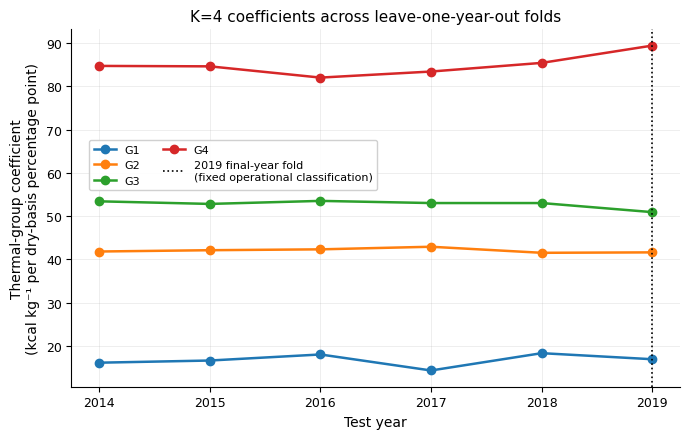


Monotonic order preserved in all folds: True


,test_year,n_train,n_test,forward_fold,operational_dbh_rmse,operational_hhv_rmse,operational_hhv_r2,7C_dbh_rmse,7C_hhv_rmse,A5OLS_dbh_rmse,A5OLS_hhv_rmse,note
0,2014,489,100,False,339.5,159.0,0.714,358.4,168.6,354.8,167.1,
1,2015,564,25,False,320.5,146.6,0.786,341.6,156.9,350.9,161.2,
2,2016,486,103,False,452.2,226.6,0.673,476.4,238.0,459.9,228.1,
3,2017,486,103,False,456.2,217.8,0.727,468.2,223.7,469.8,224.3,
4,2018,460,129,False,404.3,194.2,0.736,432.0,207.9,444.9,214.3,
5,2019,460,129,True,417.7,217.3,0.668,456.3,239.9,458.5,241.8,* forward fold (fixed grouping structure): tra...
6,Mean,,,,398.4,193.6,NaN,422.2,205.8,423.1,206.1,
7,SD,,,,56.9,33.6,NaN,58.1,35.5,55.0,33.7,
8,Pooled,,589,,412.4,202.7,NaN,437.3,215.9,437.7,215.9,


In [ ]:
# ── §5a Fixed-structure leave-one-year-out validation ──────────────────────
# Corresponds to: Table S5 and Figure S1
if not RUN_FINAL_MODEL_VALIDATION:
    print("Section 5a skipped (RUN_FINAL_MODEL_VALIDATION=False).")
else:
    # ── Section 5: LOYO ──────────────────────────────────────────────────────────
    # Parse year from DATE_COL
    df_loyo = df_clean.copy()
    df_loyo["year"] = pd.to_datetime(df_loyo[DATE_COL]).dt.year
    years = sorted(df_loyo["year"].unique())
    print(f"LOYO folds: {years}  (N={len(df_loyo)} samples after QA/QC)")

    # FINAL operational structure: FINAL_K terminal groups, NO Residual
    loyo_groups = operational_results[FINAL_K]["groups"]
    LOYO_K = FINAL_K

    _Pa = [c for c in FINE_CATEGORIES if c.startswith("Pa")]
    _Pl = [c for c in FINE_CATEGORIES if c.startswith("Pl")]
    _Fw = [c for c in FINE_CATEGORIES if c.startswith("Fw")]
    def _grp_l(df,codes):
        av=[c for c in codes if c in df.columns]
        return df[av].astype(float).sum(axis=1).values if av else np.zeros(len(df))

    # ── 5a. Fixed-structure LOYO ────────────────────────────────────────────────
    # Group structure fixed at main-analysis K; coefficients re-estimated per fold.
    # The final-year fold is a "forward fold (fixed grouping structure)":
    # training uses only earlier years, but the grouping structure itself was
    # derived from the main analysis.  The strict re-derivation is Section 5b.
    loyo_perf, loyo_coef = [], []
    _loyo_pool = {k: [] for k in ["y_dbh","y_hhv","operational_dbh","K4_hhv",
                                   "7C_dbh","7C_hhv","A5_dbh","A5_hhv"]}

    for test_year in years:
        df_tr = df_loyo[df_loyo["year"]!=test_year].copy()
        df_te = df_loyo[df_loyo["year"]==test_year].copy()
        y_dbh_te = df_te[DBH_COL].astype(float).values
        y_hhv_te = df_te[HHV_COL].astype(float).values
        W_te     = df_te[WATER_COL].astype(float).values
        y_dbh_tr = df_tr[DBH_COL].astype(float).values
        is_fwd   = (test_year == max(years))

        perf = {"test_year":test_year,"n_train":len(df_tr),"n_test":len(df_te),
                "forward_fold":is_fwd}

        # Model 1: K=RECOMMENDED_K wseg Ridge, fixed structure
        gd_ksel = {f"Group{i}":m for i,m in enumerate(loyo_groups,1)}   # terminal groups only
        X_tr_ksel = build_X_groups(df_tr, gd_ksel)
        X_te_ksel = build_X_groups(df_te, gd_ksel)
        r_ksel = Ridge(alpha=ALPHA_MAIN, fit_intercept=False)
        r_ksel.fit(X_tr_ksel.values, y_dbh_tr)
        p_dbh_ksel = r_ksel.predict(X_te_ksel.values)
        p_hhv_ksel = p_dbh_ksel*(100-W_te)/100
        perf["operational_dbh_rmse"] = round(float(np.sqrt(mean_squared_error(y_dbh_te,p_dbh_ksel))),1)
        perf["operational_hhv_rmse"] = round(float(np.sqrt(mean_squared_error(y_hhv_te,p_hhv_ksel))),1)
        perf["operational_hhv_r2"] = round(float(r2_score(y_hhv_te, p_hhv_ksel)), 3)

        cm = dict(zip(X_tr_ksel.columns, r_ksel.coef_))
        gs = [cm[f"Group{i}"] for i in range(1, LOYO_K+1)]
        loyo_coef.append({"test_year":test_year,"forward_fold":is_fwd,
            **{f"Group{i}_coef":round(cm[f"Group{i}"],1) for i in range(1,LOYO_K+1)},
            "monotonic":is_monotonic(gs)})

        # Model 2: 7C Ridge
        X_tr_7cl = build_X_groups(df_tr,{g:m for g,m in CONVENTIONAL_GROUPS.items()})
        X_te_7cl = build_X_groups(df_te,{g:m for g,m in CONVENTIONAL_GROUPS.items()})
        r_7c = Ridge(alpha=ALPHA_MAIN,fit_intercept=False).fit(X_tr_7cl.values,y_dbh_tr)
        p_dbh_7c = r_7c.predict(X_te_7cl.values)
        p_hhv_7c = p_dbh_7c*(100-W_te)/100
        perf["7C_dbh_rmse"] = round(float(np.sqrt(mean_squared_error(y_dbh_te,p_dbh_7c))),1)
        perf["7C_hhv_rmse"] = round(float(np.sqrt(mean_squared_error(y_hhv_te,p_hhv_7c))),1)

        # Model 3: A5-OLS
        X_tr_f5 = np.column_stack([_grp_l(df_tr,_Pa),_grp_l(df_tr,_Pl),_grp_l(df_tr,["Fi"]),
                                    _grp_l(df_tr,["Wo"]),_grp_l(df_tr,_Fw),
                                    _grp_l(df_tr,["Le"]),_grp_l(df_tr,["Ot"])])
        X_te_f5 = np.column_stack([_grp_l(df_te,_Pa),_grp_l(df_te,_Pl),_grp_l(df_te,["Fi"]),
                                    _grp_l(df_te,["Wo"]),_grp_l(df_te,_Fw),
                                    _grp_l(df_te,["Le"]),_grp_l(df_te,["Ot"])])
        o_f5 = LinearRegression(fit_intercept=False).fit(X_tr_f5, y_dbh_tr)
        p_dbh_f5 = o_f5.predict(X_te_f5)
        p_hhv_f5 = p_dbh_f5*(100-W_te)/100
        perf["A5OLS_dbh_rmse"] = round(float(np.sqrt(mean_squared_error(y_dbh_te,p_dbh_f5))),1)
        perf["A5OLS_hhv_rmse"] = round(float(np.sqrt(mean_squared_error(y_hhv_te,p_hhv_f5))),1)

        # accumulate predictions for pooled RMSE (item 11)
        _loyo_pool["y_dbh"].append(y_dbh_te);  _loyo_pool["y_hhv"].append(y_hhv_te)
        _loyo_pool["operational_dbh"].append(p_dbh_ksel); _loyo_pool["K4_hhv"].append(p_hhv_ksel)
        _loyo_pool["7C_dbh"].append(p_dbh_7c); _loyo_pool["7C_hhv"].append(p_hhv_7c)
        _loyo_pool["A5_dbh"].append(p_dbh_f5); _loyo_pool["A5_hhv"].append(p_hhv_f5)
        loyo_perf.append(perf)
        note = "[forward fold]" if is_fwd else ""
        print(f"  {test_year} {note:15s} n={len(df_te):3d} | "
              f"K4={perf['operational_dbh_rmse']:6.1f}  7C={perf['7C_dbh_rmse']:6.1f}  "
              f"A5={perf['A5OLS_dbh_rmse']:6.1f}  (DBH RMSE kcal/kg)")

    loyo_perf_df = pd.DataFrame(loyo_perf)
    loyo_coef_df = pd.DataFrame(loyo_coef)
    rmse_cols = ["operational_dbh_rmse","operational_hhv_rmse","7C_dbh_rmse","7C_hhv_rmse",
                 "A5OLS_dbh_rmse","A5OLS_hhv_rmse"]
    mean_row = {"test_year":"Mean","n_train":"","n_test":"","forward_fold":"",
                **{c:round(loyo_perf_df[c].mean(),1) for c in rmse_cols}}
    std_row  = {"test_year":"SD","n_train":"","n_test":"","forward_fold":"",
                **{c:round(loyo_perf_df[c].std(ddof=1),1) for c in rmse_cols}}
    # Pooled RMSE: all LOYO predictions concatenated (item 11) — sample-weighted,
    # reported alongside the unweighted yearly mean.
    _cat = {k: np.concatenate(v) for k, v in _loyo_pool.items()}
    def _pool_rmse(a, b): return round(float(np.sqrt(mean_squared_error(a, b))), 1)
    pooled_row = {"test_year":"Pooled","n_train":"","n_test":int(len(_cat["y_dbh"])),
                  "forward_fold":"",
                  "operational_dbh_rmse":_pool_rmse(_cat["y_dbh"],_cat["operational_dbh"]),
                  "operational_hhv_rmse":_pool_rmse(_cat["y_hhv"],_cat["K4_hhv"]),
                  "7C_dbh_rmse":_pool_rmse(_cat["y_dbh"],_cat["7C_dbh"]),
                  "7C_hhv_rmse":_pool_rmse(_cat["y_hhv"],_cat["7C_hhv"]),
                  "A5OLS_dbh_rmse":_pool_rmse(_cat["y_dbh"],_cat["A5_dbh"]),
                  "A5OLS_hhv_rmse":_pool_rmse(_cat["y_hhv"],_cat["A5_hhv"])}
    loyo_summary_df = pd.concat([loyo_perf_df,
                                  pd.DataFrame([mean_row,std_row,pooled_row])],
                                 ignore_index=True)
    print("Pooled (all predictions) vs unweighted yearly mean DBH RMSE — "
          f"K{LOYO_K}: {pooled_row['operational_dbh_rmse']} vs {mean_row['operational_dbh_rmse']}  "
          f"7C: {pooled_row['7C_dbh_rmse']} vs {mean_row['7C_dbh_rmse']}  "
          f"A5: {pooled_row['A5OLS_dbh_rmse']} vs {mean_row['A5OLS_dbh_rmse']}")
    loyo_summary_df["note"] = loyo_summary_df["test_year"].apply(
        lambda y: f"* forward fold (fixed grouping structure): train {min(years)}-"
                  f"{max(years)-1}, test {max(years)}" if y==max(years) else "")
    save_table(loyo_summary_df, "internal_LOYO_summary")
    save_table(loyo_coef_df, "internal_LOYO_coefficients")

    # Figure S1 — coefficient stability
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fig_s1, ax_s1 = plt.subplots(figsize=(7,4.5))
    for i in range(1, LOYO_K+1):
        ax_s1.plot(loyo_coef_df["test_year"], loyo_coef_df[f"Group{i}_coef"],
                   marker="o", lw=1.8, color=colors[i-1], label=f"G{i}")
    ax_s1.axvline(max(years), color="k", ls=":", lw=1.2,
                  label=f"{max(years)} final-year fold\n(fixed operational classification)")
    ax_s1.set_xlabel("Test year"); ax_s1.set_ylabel("Thermal-group coefficient\n(kcal kg⁻¹ per dry-basis percentage point)")
    ax_s1.set_title(f"K={LOYO_K} coefficients across leave-one-year-out folds")
    ax_s1.set_xticks(years)
    # legend placed in the empty band between G3 and G4 so no series is hidden
    ax_s1.legend(fontsize=8, loc="center left", bbox_to_anchor=(0.02, 0.62),
                 framealpha=0.92, ncol=2)
    fig_s1.tight_layout(); save_figure(fig_s1,"Figure_S1_LOYO_coefficient_stability"); plt.show()

    print(f"\nMonotonic order preserved in all folds: {loyo_coef_df['monotonic'].all()}")
    display(loyo_summary_df)

    # (Old strict-forward implementation removed; see the new
    #  "Exploratory strict final-year operational re-derivation" section.)
    redev_df = None

### 5b Strict final-year re-derivation (2014-2018 → 2019)

The complete procedure is re-derived using 2014-2018 records only — component
prevalence, the diagnostic component set, coefficient ordering, segmentation
boundaries, allocation and model coefficients — and then evaluated once on 2019.
Two strict solutions are reported: the minimum-CV K=4 solution and the K=3
solution selected by the 1% practical-equivalence rule. Corresponds to Table S6.

In [ ]:
# ── §5b Strict final-year re-derivation ───────────────────────────
# Corresponds to: Table S6──────────
if not RUN_STRICT_FINAL_YEAR:
    print("Section 5b skipped (RUN_STRICT_FINAL_YEAR=False).")
else:
    EXP_DIR = EXP_DIR_OUT   # exploratory outputs folder (Section 0)
    assert max(STRICT_TRAIN_YEARS) < STRICT_TEST_YEAR
    _dfy = df_clean.copy()
    _dfy["year"] = pd.to_datetime(_dfy[DATE_COL]).dt.year
    df_str = _dfy[_dfy["year"].isin(STRICT_TRAIN_YEARS)].reset_index(drop=True)
    df_t19 = _dfy[_dfy["year"] == STRICT_TEST_YEAR].reset_index(drop=True)
    assert set(df_str["year"]) <= set(STRICT_TRAIN_YEARS) and set(df_t19["year"]) == {STRICT_TEST_YEAR}
    y_str  = df_str[DBH_COL].astype(float).values
    y19_d  = df_t19[DBH_COL].astype(float).values
    y19_h  = df_t19[HHV_COL].astype(float).values
    W19    = df_t19[WATER_COL].astype(float).values
    cv_str = RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS,
                            random_state=RANDOM_STATE)
    # D2: strict LM/S
    ab_str = compute_abundance(df_str, FINE_CATEGORIES)
    LM_str = ab_str.loc[ab_str["lms_class"].isin(["L","M"]),"code"].tolist()
    S_str  = ab_str.loc[ab_str["lms_class"]=="S","code"].tolist()
    _jac = len(set(LM_str)&set(LM_codes)) / len(set(LM_str)|set(LM_codes))
    cmp_rows = [{"component": c_,
        "main_LM_or_S": "LM" if c_ in LM_codes else "S",
        "strict_LM_or_S": "LM" if c_ in LM_str else "S",
        "main_mean_share": round(float(abundance_train.loc[abundance_train["code"]==c_,"mean_pct"].iloc[0]),3),
        "strict_mean_share": round(float(ab_str.loc[ab_str["code"]==c_,"mean_pct"].iloc[0]),3),
        "same_status": (c_ in LM_codes) == (c_ in LM_str)} for c_ in FINE_CATEGORIES]
    pd.DataFrame(cmp_rows).to_csv(EXP_DIR/"strict_vs_main_LM_status.csv", index=False)
    print(f"strict LM n={len(LM_str)} (main {len(LM_codes)}); Jaccard={_jac:.3f}")
    # D3: strict LM coefficients + ordering
    _, cdf_str = fit_ridge_cv(build_X(df_str, LM_str, S_str), y_str, cv_str)
    cs_str = coefficient_stats(cdf_str)
    cs_str = cs_str[cs_str["code"]!="Residual"].sort_values("coef_mean")
    oc_str, om_str = cs_str["code"].tolist(), cs_str["coef_mean"].tolist()
    sm_str = dict(zip(ab_str["code"], ab_str["mean_pct"]))
    # D4-D6: strict wseg + operational per K + CV
    strict_results, str_rows = {}, []
    for K in K_RANGE:
        gl, _ = seg_groups(oc_str, om_str, K, sm_str, context=f"strict-K{K}")
        gr, al = complete_operational_from_lm(gl, df_str, ab_str, S_str)
        _fl = [c_ for m in gr for c_ in m]
        assert sorted(_fl) == sorted(FINE_CATEGORIES) and len(gr) == K
        gd_ = {f"Group{i}": m for i, m in enumerate(gr, 1)}
        cvm_, cdf_ = fit_ridge_cv(build_X_groups(df_str, gd_), y_str, cv_str)
        cs_ = coefficient_stats(cdf_)
        gm_ = [float(cs_.loc[cs_["code"]==f"Group{i}","coef_mean"].iloc[0])
               for i in range(1, K+1)]
        sh_ = [float(ab_str.loc[ab_str["code"].isin(m),"mean_pct"].sum()) for m in gr]
        strict_results[K] = dict(groups=gr, gd=gd_, alloc=al, cv=cvm_,
                                  gamma=gm_, shares=sh_, mono=is_monotonic(gm_))
        str_rows.append({"K": K, "strict_cv_dbh_rmse": round(cvm_["cv_dbh_rmse"],1),
            "monotonic": is_monotonic(gm_), "min_share": round(min(sh_),2),
            "gamma": ";".join(f"{g:.1f}" for g in gm_)})
    str_df = pd.DataFrame(str_rows)
    _min_ = str_df["strict_cv_dbh_rmse"].min()
    str_df["strict_delta_pct"] = (100*(str_df["strict_cv_dbh_rmse"]-_min_)/_min_).round(2)
    str_df.to_csv(EXP_DIR/"strict_K2_K7_cv.csv", index=False)
    feas_ = [K for K in K_RANGE if strict_results[K]["mono"]
             and min(strict_results[K]["shares"]) >= MIN_GROUP_SHARE]
    if not feas_: feas_ = [K for K in K_RANGE if strict_results[K]["mono"]] or list(K_RANGE)
    sel_str = select_k_by_tolerance(
        {K: strict_results[K]["cv"]["cv_dbh_rmse"] for K in K_RANGE}, feas_, K_TOLERANCES)
    pd.DataFrame([{"tolerance": f"{t:.0%}", **{k: str(v) for k, v in
                    sel_str["by_tol"][t].items()}} for t in K_TOLERANCES]
                 ).to_csv(EXP_DIR/"strict_K_selection.csv", index=False)
    # One-shot 2019 evaluation: tolerance-selected and minimum-CV strict models,
    # plus the seven-category and recalibrated A5-OLS baselines
    def _eval19(gd_):
        m_ = Ridge(alpha=ALPHA_MAIN, fit_intercept=False).fit(
            build_X_groups(df_str, gd_).values, y_str)
        pd_ = m_.predict(build_X_groups(df_t19, gd_).values)
        ph_ = pd_*(100.0-W19)/100.0
        nz = y19_h != 0
        return {"dbh_rmse": round(float(np.sqrt(mean_squared_error(y19_d, pd_))),1),
                "hhv_rmse": round(float(np.sqrt(mean_squared_error(y19_h, ph_))),1),
                "hhv_r2":   round(float(r2_score(y19_h, ph_)),3),
                "hhv_mape": round(float(np.mean(np.abs((y19_h[nz]-ph_[nz])/y19_h[nz]))*100),2)}
    perf19 = []
    for t in K_TOLERANCES:
        Kt = sel_str["by_tol"][t]["K_selected"]
        perf19.append({"model": f"SF-A (tol {t:.0%})", "K": Kt,
                        **_eval19(strict_results[Kt]["gd"])})
    # the minimum-CV strict solution is taken from the strict selector, not FINAL_K
    _strict_k_min = int(sel_str["K_best"])
    _strict_k_tol = int(sel_str["by_tol"][MAIN_K_TOLERANCE]["K_selected"])
    assert _strict_k_min == 4, f"strict minimum-CV K = {_strict_k_min}"
    assert _strict_k_tol == 3, f"strict tolerance-selected K = {_strict_k_tol}"
    perf19.append({"model": "SF-B fixed K=4 re-derived", "K": _strict_k_min,
                    **_eval19(strict_results[_strict_k_min]["gd"])})
    cg_s = {g: m for g, m in CONVENTIONAL_GROUPS.items()}
    perf19.append({"model": "7C (2014-2018 fit)", "K": 7, **_eval19(cg_s)})
    m_a5 = LinearRegression(fit_intercept=False).fit(_X_tr_strict := np.column_stack(
        [df_str[[c_ for c_ in FINE_CATEGORIES if c_.startswith("Pa")]].sum(axis=1),
         df_str[[c_ for c_ in FINE_CATEGORIES if c_.startswith("Pl")]].sum(axis=1),
         df_str[["Fi"]].sum(axis=1), df_str[["Wo"]].sum(axis=1),
         df_str[[c_ for c_ in FINE_CATEGORIES if c_.startswith("Fw")]].sum(axis=1),
         df_str[["Le"]].sum(axis=1), df_str[["Ot"]].sum(axis=1)]), y_str)
    _X19 = np.column_stack(
        [df_t19[[c_ for c_ in FINE_CATEGORIES if c_.startswith("Pa")]].sum(axis=1),
         df_t19[[c_ for c_ in FINE_CATEGORIES if c_.startswith("Pl")]].sum(axis=1),
         df_t19[["Fi"]].sum(axis=1), df_t19[["Wo"]].sum(axis=1),
         df_t19[[c_ for c_ in FINE_CATEGORIES if c_.startswith("Fw")]].sum(axis=1),
         df_t19[["Le"]].sum(axis=1), df_t19[["Ot"]].sum(axis=1)])
    pd_a5 = m_a5.predict(_X19); ph_a5 = pd_a5*(100.0-W19)/100.0
    perf19.append({"model": "A5 OLS (2014-2018 recal.)", "K": 7,
        "dbh_rmse": round(float(np.sqrt(mean_squared_error(y19_d, pd_a5))),1),
        "hhv_rmse": round(float(np.sqrt(mean_squared_error(y19_h, ph_a5))),1),
        "hhv_r2": round(float(r2_score(y19_h, ph_a5)),3), "hhv_mape": np.nan})
    perf19_df = pd.DataFrame(perf19)
    perf19_df.to_csv(EXP_DIR/"strict_2019_performance.csv", index=False)
    # D9: membership vs main (labels ordered by gamma already: G1<..<GK)
    m_map = {c_: gi+1 for gi, m in enumerate(operational_results[FINAL_K]["groups"]) for c_ in m}
    s_map = {c_: gi+1 for gi, m in enumerate(strict_results[_strict_k_min]["groups"])
             for c_ in m}
    mem_rows = [{"fine_category": c_, "main_group": f"G{m_map[c_]}",
                  "strict_group": f"G{s_map[c_]}", "same_group": m_map[c_]==s_map[c_],
                  "LM_or_S_main": "LM" if c_ in LM_codes else "S",
                  "LM_or_S_strict": "LM" if c_ in LM_str else "S"}
                for c_ in FINE_CATEGORIES]
    mem_df = pd.DataFrame(mem_rows)
    mem_df.to_csv(EXP_DIR/"strict_vs_main_membership.csv", index=False)
    agree = mem_df["same_group"].mean()
    pairs_agree = np.mean([ (m_map[a]==m_map[b]) == (s_map[a]==s_map[b])
        for a, b in combinations(FINE_CATEGORIES, 2)])
    print()
    print("STRICT FINAL-YEAR RE-DERIVATION")
    print("-" * 32)
    print(f"Training years: {STRICT_TRAIN_YEARS}   Test year: {STRICT_TEST_YEAR}")
    print(f"LM membership similarity (Jaccard): {_jac:.3f}")
    print(f"K_best: {sel_str['K_best']}  " + "  ".join(
        f"{t:.0%}->K{sel_str['by_tol'][t]['K_selected']}" for t in K_TOLERANCES))
    _disp19 = perf19_df.copy()
    _disp19["model"] = _disp19["model"].replace({
        "SF-B fixed K=4 re-derived": f"Strict re-derived minimum-CV K={_strict_k_min}",
        f"SF-A (tol {MAIN_K_TOLERANCE:.0%})":
            f"Strict re-derived tolerance-selected K={_strict_k_tol}",
        "7C (2014-2018 fit)": "Conventional seven-category model",
        "A5 OLS (2014-2018 recal.)": "Recalibrated A5-OLS"})
    print(_disp19.to_string(index=False))
    print(f"Membership agreement (exact): {agree:.1%}   pairwise co-membership: {pairs_agree:.1%}")
    _moved = [c_ for c_ in FINE_CATEGORIES if m_map[c_] != s_map[c_]]
    print(f"Moved components ({len(_moved)}/{len(FINE_CATEGORIES)}):")
    for c_ in _moved:
        _tag = "LM" if c_ in LM_codes else "S"
        print(f"  {c_} [{_tag}]: main G{m_map[c_]} -> strict G{s_map[c_]}")
    print("Anchor components check:")
    for c_ in ["Pa8","Fw2","Fw3","Wo","Ot","Le","Pl10"]:
        print(f"  {c_}: main G{m_map[c_]} -> strict G{s_map[c_]}"
              + ("  (stable)" if m_map[c_]==s_map[c_] else "  (MOVED)"))
    # ── publication-ready Supplementary Table S6 ───────────────────────────
    _loyo19 = float(loyo_perf_df.loc[loyo_perf_df["test_year"] == STRICT_TEST_YEAR,
                                      "operational_dbh_rmse"].iloc[0])
    _sfa_K = sel_str["by_tol"][MAIN_K_TOLERANCE]["K_selected"]
    _row_of = lambda name: perf19_df.loc[perf19_df["model"] == name].iloc[0]
    _sfa = _row_of(f"SF-A (tol {MAIN_K_TOLERANCE:.0%})")
    _sfb = _row_of("SF-B fixed K=4 re-derived")
    _7c  = _row_of("7C (2014-2018 fit)")
    _a5  = _row_of("A5 OLS (2014-2018 recal.)")
    strict_forward_summary_df = pd.DataFrame([
        {"Model": f"Fixed-main-structure LOYO {STRICT_TEST_YEAR} (non-strict reference)",
         "Derivation": "main full-period grouping; coefficients refitted 2014-2018",
         "K": FINAL_K, "DBH_RMSE": round(_loyo19, 1), "HHV_RMSE": np.nan,
         "HHV_R2": np.nan},
        {"Model": f"Strict re-derived minimum-CV K={_strict_k_min}",
         "Derivation": "all structure re-derived from 2014-2018; minimum-CV solution",
         "K": FINAL_K, "DBH_RMSE": _sfb["dbh_rmse"], "HHV_RMSE": _sfb["hhv_rmse"],
         "HHV_R2": _sfb["hhv_r2"]},
        {"Model": f"Strict re-derived tolerance-selected K={_strict_k_tol}",
         "Derivation": f"all structure and K re-derived from 2014-2018 "
                       f"({MAIN_K_TOLERANCE:.0%} tolerance)",
         "K": _sfa_K, "DBH_RMSE": _sfa["dbh_rmse"], "HHV_RMSE": _sfa["hhv_rmse"],
         "HHV_R2": _sfa["hhv_r2"]},
        {"Model": "Conventional seven-category model", "Derivation": "fitted on 2014-2018", "K": 7,
         "DBH_RMSE": _7c["dbh_rmse"], "HHV_RMSE": _7c["hhv_rmse"], "HHV_R2": _7c["hhv_r2"]},
        {"Model": "Recalibrated A5-OLS", "Derivation": "recalibrated on 2014-2018", "K": 7,
         "DBH_RMSE": _a5["dbh_rmse"], "HHV_RMSE": _a5["hhv_rmse"], "HHV_R2": _a5["hhv_r2"]},
    ])
    strict_forward_summary_df["Note"] = [
        "reference: structure derived from the full period", "strict", "strict",
        "strict", "strict"]
    _agree_rows = pd.DataFrame([
        {"Model": "Strict K=4 vs main K=4 — exact 25-component membership agreement (%)",
         "Derivation": "", "K": "", "DBH_RMSE": round(100*agree, 1),
         "HHV_RMSE": np.nan, "HHV_R2": np.nan, "Note": "membership comparison"},
        {"Model": "Strict K=4 vs main K=4 — pairwise co-membership agreement (%)",
         "Derivation": "", "K": "", "DBH_RMSE": round(100*pairs_agree, 1),
         "HHV_RMSE": np.nan, "HHV_R2": np.nan, "Note": "membership comparison"},
        {"Model": "LM membership Jaccard similarity", "Derivation": "", "K": "",
         "DBH_RMSE": round(_jac, 3), "HHV_RMSE": np.nan, "HHV_R2": np.nan,
         "Note": "membership comparison"},
        {"Model": "LM membership changes (strict vs main)", "Derivation":
         "; ".join(f"{c_}: G{m_map[c_]}->G{s_map[c_]}" for c_ in _moved
                   if c_ in LM_codes),
         "K": "", "DBH_RMSE": np.nan, "HHV_RMSE": np.nan, "HHV_R2": np.nan,
         "Note": "paper-S moves (Pa2/Pa3/Pa4/Pa7) follow deterministic "
                 "allocation propagation, not independent instabilities"},
    ])
    strict_forward_summary_df = pd.concat(
        [strict_forward_summary_df, _agree_rows], ignore_index=True)
    display(strict_forward_summary_df)
    print("Strict final-year results reported as Supplementary Table S6.")

strict LM n=11 (main 11); Jaccard=1.000

STRICT FINAL-YEAR RE-DERIVATION
--------------------------------
Training years: [2014, 2015, 2016, 2017, 2018]   Test year: 2019
LM membership similarity (Jaccard): 1.000
K_best: 4  1%->K3  2%->K3  3%->K3
                                   model  K  dbh_rmse  hhv_rmse  hhv_r2  hhv_mape
Strict re-derived tolerance-selected K=3  3     465.0     245.1   0.578      7.64
                           SF-A (tol 2%)  3     465.0     245.1   0.578      7.64
                           SF-A (tol 3%)  3     465.0     245.1   0.578      7.64
        Strict re-derived minimum-CV K=4  4     443.1     233.0   0.618      7.14
       Conventional seven-category model  7     456.3     239.9   0.595      7.33
                     Recalibrated A5-OLS  7     458.5     241.8   0.589       NaN
Membership agreement (exact): 72.0%   pairwise co-membership: 82.3%
Moved components (7/25):
  Pa1 [LM]: main G2 -> strict G1
  Pa2 [S]: main G2 -> strict G3
  Pa3 [S]: main G2 ->

,Model,Derivation,K,DBH_RMSE,HHV_RMSE,HHV_R2,Note
0,Fixed-main-structure LOYO 2019 (non-strict ref...,main full-period grouping; coefficients refitt...,4,417.7,NaN,NaN,reference: structure derived from the full period
1,Strict re-derived minimum-CV K=4,all structure re-derived from 2014-2018; minim...,4,443.1,233.0,0.618,strict
2,Strict re-derived tolerance-selected K=3,all structure and K re-derived from 2014-2018 ...,3,465.0,245.1,0.578,strict
3,Conventional seven-category model,fitted on 2014-2018,7,456.3,239.9,0.595,strict
4,Recalibrated A5-OLS,recalibrated on 2014-2018,7,458.5,241.8,0.589,strict
5,Strict K=4 vs main K=4 — exact 25-component me...,,,72.0,NaN,NaN,membership comparison
6,Strict K=4 vs main K=4 — pairwise co-membershi...,,,82.3,NaN,NaN,membership comparison
7,LM membership Jaccard similarity,,,1.0,NaN,NaN,membership comparison
8,LM membership changes (strict vs main),Pa1: G2->G1; Pl8: G4->G3; Fi: G2->G3,,NaN,NaN,NaN,paper-S moves (Pa2/Pa3/Pa4/Pa7) follow determi...


Strict final-year results reported as Supplementary Table S6.


## Section 6: Sensitivity and structural robustness analyses

| Section | Analysis | Manuscript output |
|---|---|---|
| 6a | HHV/carbon exclusion-threshold sensitivity | Table S7 |
| 6b | Ridge alpha sensitivity | Table S8; Figure S2 |
| 6c | Non-negative coefficient sensitivity | Supplementary S4 text |
| 6d | Bootstrap co-clustering of the complete operational procedure | Table S9; Figure S3 |
| 6e | Literature-architecture estimator and coefficient sensitivity | Tables S10-S11 |

In [ ]:
# ── §6a HHV/carbon exclusion-threshold sensitivity ─────────────────────────
# Corresponds to: Table S7
if not RUN_FINAL_MODEL_VALIDATION:
    print("Section 6a skipped (RUN_FINAL_MODEL_VALIDATION=False).")
else:
    # ── 6a. HHV/C threshold sensitivity — PAIRED design ─────────────────────────
    # Item 9: every original row gets a fixed row_id and a fixed train/test
    # assignment (drawn once on all 594 raw rows with RANDOM_STATE).  Each
    # threshold then only REMOVES ineligible samples from within the pre-assigned
    # split, so all four variants are compared on maximally overlapping samples.
    # Corresponds to: Table S7
    df_raw_id = df_raw.copy()
    df_raw_id["row_id"] = np.arange(len(df_raw_id))
    _ids = df_raw_id["row_id"].values
    _tr_ids, _te_ids = train_test_split(_ids, test_size=TEST_SIZE,
                                         random_state=RANDOM_STATE)
    _tr_ids, _te_ids = set(_tr_ids), set(_te_ids)
    print(f"Fixed assignment on {len(_ids)} raw rows: "
          f"{len(_tr_ids)} train / {len(_te_ids)} test")

    s6a_rows, s6a_groups = [], {}
    for thr in HHV_C_THRESHOLDS:
        df_t, cats_t, cg_t, qa_t = run_qaqc(df_raw_id, list(FINE_CATEGORY_MAP.keys()), thr)
        n = len(df_t)
        if n < 50:
            print(f"  threshold={thr}: only {n} samples after QA/QC — skipped"); continue

        df_t_tr = df_t[df_t["row_id"].isin(_tr_ids)].reset_index(drop=True)
        df_t_te = df_t[df_t["row_id"].isin(_te_ids)].reset_index(drop=True)
        cv_t = RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS,
                              random_state=RANDOM_STATE)

        lm_t = [c for c in LM_codes if c in cats_t]
        s_t  = [c for c in cats_t if c not in lm_t]
        X_tr_t = build_X(df_t_tr, lm_t, s_t)
        X_te_t = build_X(df_t_te, lm_t, s_t)
        met_t, _, _ = eval_model(X_tr_t, X_te_t, df_t_tr, df_t_te, cv_t)

        # K=RECOMMENDED_K layer: re-derive the grouping on this threshold's FIXED
        # train side, evaluate on the FIXED test side (paired across thresholds).
        ab_t  = compute_abundance(df_t_tr, cats_t)
        LM_t2 = ab_t.loc[ab_t["lms_class"].isin(["L","M"]),"code"].tolist()
        S_t2  = ab_t.loc[ab_t["lms_class"]=="S","code"].tolist()
        y_t_tr = df_t_tr[DBH_COL].astype(float).values
        _, cdf_t = fit_ridge_cv(build_X(df_t_tr, LM_t2, S_t2), y_t_tr, cv_t)
        cs_t = coefficient_stats(cdf_t)
        cs_t = cs_t[cs_t["code"]!="Residual"].sort_values("coef_mean")
        _sm_t = dict(zip(ab_t["code"], ab_t["mean_pct"]))
        gK_t_lm, _ = seg_groups(cs_t["code"].tolist(), cs_t["coef_mean"].tolist(),
                                 FINAL_K, _sm_t, context=f"6a-thr{thr}")
        # complete to the operational model (variant allocation
        # coefficients used for rule R2 — noted sensitivity approximation)
        gK_t, _al_t = complete_operational_from_lm(gK_t_lm, df_t_tr, ab_t, S_t2)
        gd_t = {f"Group{i}": m for i, m in enumerate(gK_t, 1)}   # terminal only
        met_op_t, _, _ = eval_model(build_X_groups(df_t_tr, gd_t),
                                     build_X_groups(df_t_te, gd_t),
                                     df_t_tr, df_t_te, cv_t)
        m_t = Ridge(alpha=ALPHA_MAIN, fit_intercept=False).fit(
            build_X_groups(df_t_tr, gd_t).values, y_t_tr)
        p_t = m_t.predict(build_X_groups(df_t_te, gd_t).values)
        ksel_rmse_t = float(np.sqrt(mean_squared_error(
            df_t_te[DBH_COL].astype(float).values, p_t)))
        s6a_groups[str(thr)] = gK_t
        s6a_rows.append({"threshold": str(thr), "n_final": n,
                          "n_train": len(df_t_tr), "n_test": len(df_t_te),
                          **{k: round(v, 1) for k, v in met_t.items()},
                          "operational_cv_dbh_rmse": round(met_op_t["cv_dbh_rmse"], 1),
                      "operational_test_dbh_rmse": round(ksel_rmse_t, 1),
                      "Pa8_assignment": next(f"G{gi+1}" for gi, m in
                          enumerate(gK_t) if "Pa8" in m),
                          "Ksel_group_members": "|".join(
                              f"Group{i}:"+",".join(m) for i,m in enumerate(gK_t,1))})
        print(f"  threshold={thr!s:5s}  n={n} (tr {len(df_t_tr)}/te {len(df_t_te)})  "
              f"test_DBH_RMSE={met_t['test_dbh_rmse']:.1f}")

    # Consistency baseline = the threshold-140 grouping WITHIN the paired design
    # (its train side, n=473, differs from the main-analysis training set, n=471,
    # by a few samples, so the 140 re-derived grouping is not compared against
    # the main analysis here).
    def _same_groups(a, b):
        return len(a)==len(b) and all(set(x)==set(y) for x,y in zip(a,b))
    _g140 = s6a_groups.get("140")
    for row in s6a_rows:
        gk = s6a_groups[row["threshold"]]
        row["groups_identical_to_140"] = _same_groups(gk, _g140)
        row["extreme_groups_identical_to_140"] = (
            set(gk[0])==set(_g140[0]) and set(gk[-1])==set(_g140[-1]))
    same_140_160 = _same_groups(s6a_groups.get("140"), s6a_groups.get("160"))
    print(f"140 vs 160 groupings identical: {same_140_160}")

    s6a_df = pd.DataFrame(s6a_rows)
    save_table(s6a_df, "internal_threshold_sensitivity_full")

    # audit: which components change assignment relative to paired threshold 140
    _map140 = {c_: gi+1 for gi, m in enumerate(s6a_groups["140"]) for c_ in m}
    _aud_rows = []
    for row in s6a_rows:
        thr_ = row["threshold"]
        mp_ = {c_: gi+1 for gi, m in enumerate(s6a_groups[thr_]) for c_ in m}
        chg = [f"{c_}: G{_map140[c_]}->G{mp_[c_]}" for c_ in FINE_CATEGORIES
               if _map140[c_] != mp_[c_]]
        _aud_rows.append({"threshold": thr_, "n": row["n_final"],
            "n_categories_changed": len(chg),
            "components_changed_vs_paired_140": "; ".join(chg) if chg else "none",
            "group_membership": row["Ksel_group_members"]})
    threshold_audit_df = pd.DataFrame(_aud_rows)
    save_exploratory(threshold_audit_df, "threshold_membership_audit.csv")

    # publication table (§6a)
    threshold_pub_df = pd.DataFrame([{
        "HHV/C threshold": r["threshold"], "n": r["n_final"],
        "Operational CV DBH RMSE": r["operational_cv_dbh_rmse"],
        "Operational test DBH RMSE": r["operational_test_dbh_rmse"],
        "Exact grouping same as paired threshold 140": bool(r["groups_identical_to_140"]),
        "Components changed vs paired 140": a["components_changed_vs_paired_140"],
    } for r, a in zip(s6a_rows, _aud_rows)])
    display(threshold_pub_df)
    display(s6a_df)

Fixed assignment on 594 raw rows: 475 train / 119 test
  Dropping near-empty columns: ['Pl11']
  threshold=None   n=594 (tr 475/te 119)  test_DBH_RMSE=459.9
  Dropping near-empty columns: ['Pl11']
  threshold=120    n=535 (tr 433/te 102)  test_DBH_RMSE=349.8
  Dropping near-empty columns: ['Pl11']
  threshold=140    n=589 (tr 473/te 116)  test_DBH_RMSE=379.5
  Dropping near-empty columns: ['Pl11']
  threshold=160    n=592 (tr 473/te 119)  test_DBH_RMSE=461.2
140 vs 160 groupings identical: True


,HHV/C threshold,n,Operational CV DBH RMSE,Operational test DBH RMSE,Exact grouping same as paired threshold 140,Components changed vs paired 140
0,None,594,447.6,459.6,False,Pa1: G2->G1; Pa5: G3->G2; Fi: G3->G2
1,120,535,367.0,367.1,False,Fi: G3->G2; Le: G4->G3
2,140,589,407.3,381.2,True,none
3,160,592,407.3,457.7,True,none


,threshold,n_final,n_train,n_test,cv_dbh_rmse,cv_dbh_rmse_se,cv_dbh_rmse_se_rep,cv_dbh_r2,cv_hhv_rmse,cv_hhv_rmse_se,...,test_dbh_rmse,test_hhv_rmse,test_hhv_r2,test_hhv_mape,operational_cv_dbh_rmse,operational_test_dbh_rmse,Pa8_assignment,Ksel_group_members,groups_identical_to_140,extreme_groups_identical_to_140
0,None,594,475,119,457.7,7.5,0.6,0.3,223.0,0.4,...,459.9,233.3,0.7,6.3,447.6,459.6,G3,"Group1:Fw3,Wo,Pa1,Ot|Group2:Pa6,Fw1,Pa5,Fi|Gro...",False,False
1,120,535,433,102,375.6,2.6,0.7,0.4,184.3,0.4,...,349.8,168.2,0.8,5.4,367.0,367.1,G3,"Group1:Fw3,Wo,Ot|Group2:Pa1,Pa6,Fw1,Fi|Group3:...",False,False
2,140,589,473,116,416.7,3.1,0.6,0.4,203.8,0.3,...,379.5,184.1,0.8,5.8,407.3,381.2,G3,"Group1:Fw3,Wo,Ot|Group2:Pa1,Pa6,Fw1|Group3:Fi,...",True,True
3,160,592,473,119,416.7,3.1,0.6,0.4,203.8,0.3,...,461.2,233.7,0.7,6.3,407.3,457.7,G3,"Group1:Fw3,Wo,Ot|Group2:Pa1,Pa6,Fw1|Group3:Fi,...",True,True


LM-stage   minimum CV DBH RMSE = 410.7  (1% tolerance ≤ 414.8)  eligible α: [50, 100, 200, 300, 500, 750]
Operational minimum CV DBH RMSE = 403.7  (1% tolerance ≤ 407.7)  eligible α: [50, 100, 200, 300, 500]
Jointly eligible α: [50, 100, 200, 300, 500]  →  selected_alpha = 500


,α,LM-stage CV DBH RMSE,Operational K=4 CV DBH RMSE
0,50,410.7,403.7
1,100,410.7,403.7
2,200,410.9,404.0
3,300,411.4,404.4
4,500,412.7,404.4
5,750,414.6,414.8
6,1000,416.6,414.9
7,2000,423.9,424.6


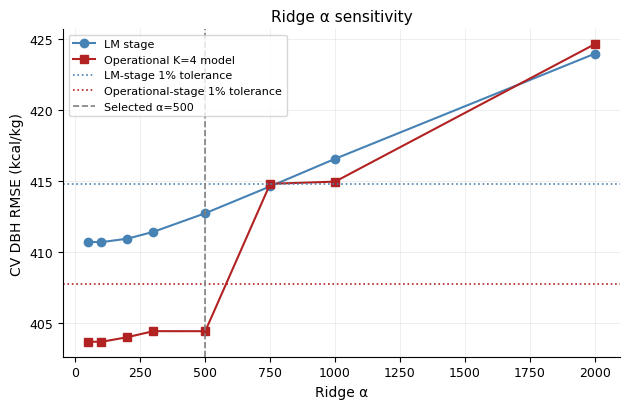

Figure S2 caption: Figure S2. Ridge α sensitivity based on cross-validated DBH RMSE. The two curves show the LM-stage and operational K=4 CV DBH RMSE values across candidate regularization settings. The horizontal dotted lines denote 1% above the minimum RMSE at each stage. The vertical dashed line marks α=500, the largest candidate value lying within the 1% tolerance range at both stages.


In [ ]:
# ── §6b Ridge alpha sensitivity ────────────────────────────────────────────
# Corresponds to: Table S8 and Figure S2
if not RUN_FINAL_MODEL_VALIDATION:
    print("Section 6b skipped (RUN_FINAL_MODEL_VALIDATION=False).")
else:
    # This section answers a single question: is ALPHA_MAIN the largest
    # candidate α lying within the 1 % near-optimal CV region at BOTH the
    # LM (diagnostic) stage and the operational K=FINAL_K stage?
    # For every α the LM coefficients are re-estimated, the weighted
    # segmentation is rebuilt from that α's coefficient ordering, the
    # S-components are allocated deterministically, and the operational
    # K=FINAL_K training CV RMSE is recomputed.  Selection uses training CV
    # only; the held-out test set plays no role here.
    s6b_rows = []
    _share_map_main = dict(zip(abundance_train["code"], abundance_train["mean_pct"]))
    X_tr_lm = build_X(df_train, LM_codes, S_codes)
    y_dbh_tr_all = df_train[DBH_COL].astype(float).values

    for alpha in ALPHA_CANDIDATES:
        cv_m_a, coef_df_a = fit_ridge_cv(X_tr_lm, y_dbh_tr_all, cv, alpha=alpha)
        cs_a  = coefficient_stats(coef_df_a)
        cs_a2 = cs_a[cs_a["code"] != "Residual"].sort_values("coef_mean")
        sorted_a = cs_a2["code"].tolist()          # internal working variable only

        gK_a_lm, _ = seg_groups(sorted_a, cs_a2["coef_mean"].tolist(), FINAL_K,
                                 _share_map_main, context=f"6b-alpha{alpha}")
        gK_a, _ = complete_operational_from_lm(gK_a_lm, df_train,
                                                abundance_train, S_codes, alpha=alpha)
        gd_a = {f"Group{i}": m for i, m in enumerate(gK_a, 1)}   # terminal groups
        _cv_op_a, _ = fit_ridge_cv(build_X_groups(df_train, gd_a),
                                    y_dbh_tr_all, cv, alpha=alpha)
        # unrounded values are kept for all tolerance comparisons
        s6b_rows.append({"alpha": alpha,
                          "lm_stage_cv_dbh_rmse": float(cv_m_a["cv_dbh_rmse"]),
                          "operational_cv_dbh_rmse": float(_cv_op_a["cv_dbh_rmse"])})

    s6b_df = pd.DataFrame(s6b_rows)

    # ── joint 1 % tolerance selection (unrounded CV RMSE) ──────────────────
    lm_min = float(s6b_df["lm_stage_cv_dbh_rmse"].min())
    op_min = float(s6b_df["operational_cv_dbh_rmse"].min())
    lm_tolerance = lm_min * 1.01
    op_tolerance = op_min * 1.01
    s6b_df["lm_within_1pct"] = s6b_df["lm_stage_cv_dbh_rmse"] <= lm_tolerance
    s6b_df["op_within_1pct"] = s6b_df["operational_cv_dbh_rmse"] <= op_tolerance
    jointly_eligible = sorted(
        int(a) for a in s6b_df.loc[s6b_df["lm_within_1pct"] & s6b_df["op_within_1pct"],
                                    "alpha"])
    selected_alpha = max(jointly_eligible)
    lm_eligible = sorted(int(a) for a in s6b_df.loc[s6b_df["lm_within_1pct"], "alpha"])
    op_eligible = sorted(int(a) for a in s6b_df.loc[s6b_df["op_within_1pct"], "alpha"])

    print(f"LM-stage   minimum CV DBH RMSE = {lm_min:.1f}  "
          f"(1% tolerance ≤ {lm_tolerance:.1f})  eligible α: {lm_eligible}")
    print(f"Operational minimum CV DBH RMSE = {op_min:.1f}  "
          f"(1% tolerance ≤ {op_tolerance:.1f})  eligible α: {op_eligible}")
    print(f"Jointly eligible α: {jointly_eligible}  →  selected_alpha = {selected_alpha}")
    assert selected_alpha == ALPHA_MAIN == 500, (
        f"selected_alpha={selected_alpha} but ALPHA_MAIN={ALPHA_MAIN}")

    # ── Table S8 (three columns; display values rounded to 1 decimal) ──────
    alpha_pub_df = pd.DataFrame({
        "α": s6b_df["alpha"].astype(int),
        "LM-stage CV DBH RMSE": s6b_df["lm_stage_cv_dbh_rmse"].round(1),
        "Operational K=4 CV DBH RMSE": s6b_df["operational_cv_dbh_rmse"].round(1)})
    # Table S8 is exported by the canonical exporter in §7b.
    TABLE_S8_TITLE = ("Table S8. Ridge α sensitivity based on cross-validated DBH "
                      "prediction error at the diagnostic and operational stages.")
    TABLE_S8_FOOTNOTE = (
        f"The minimum LM-stage and operational K={FINAL_K} CV DBH RMSE values were "
        f"{lm_min:.1f} and {op_min:.1f} kcal/kg, respectively. Their corresponding "
        f"1% tolerance limits were approximately {lm_tolerance:.1f} and "
        f"{op_tolerance:.1f} kcal/kg. Values of α={min(lm_eligible)}–{max(lm_eligible)} "
        f"remained within the LM-stage tolerance, whereas α={min(op_eligible)}–"
        f"{max(op_eligible)} remained within the operational-stage tolerance. "
        f"Accordingly, α={selected_alpha} was retained as the largest candidate value "
        f"within the 1% tolerance range at both stages. Held-out test performance was "
        f"not used in this assessment.")
    display(alpha_pub_df)

    # ── Figure S2: two training-CV curves + the two 1 % tolerance limits ───
    fig_s2, ax_s2 = plt.subplots(figsize=(6.4, 4.2))
    ax_s2.plot(s6b_df["alpha"], s6b_df["lm_stage_cv_dbh_rmse"], marker="o",
               color="steelblue", label="LM stage")
    ax_s2.plot(s6b_df["alpha"], s6b_df["operational_cv_dbh_rmse"], marker="s",
               color="firebrick", label=f"Operational K={FINAL_K} model")
    ax_s2.axhline(lm_tolerance, ls=":", color="steelblue", lw=1.2,
                  label="LM-stage 1% tolerance")
    ax_s2.axhline(op_tolerance, ls=":", color="firebrick", lw=1.2,
                  label="Operational-stage 1% tolerance")
    ax_s2.axvline(selected_alpha, ls="--", color="gray", lw=1.2,
                  label=f"Selected α={selected_alpha}")
    ax_s2.set_xlabel("Ridge α")
    ax_s2.set_ylabel("CV DBH RMSE (kcal/kg)")
    ax_s2.set_title("Ridge α sensitivity")
    ax_s2.legend(fontsize=8, loc="upper left")
    fig_s2.tight_layout()
    save_figure(fig_s2, "Figure_S2_alpha_sensitivity"); plt.show()
    FIGURE_S2_CAPTION = (
        "Figure S2. Ridge α sensitivity based on cross-validated DBH RMSE. The two "
        "curves show the LM-stage and operational K=4 CV DBH RMSE values across "
        "candidate regularization settings. The horizontal dotted lines denote 1% "
        "above the minimum RMSE at each stage. The vertical dashed line marks α=500, "
        "the largest candidate value lying within the 1% tolerance range at both "
        "stages.")
    print("Figure S2 caption:", FIGURE_S2_CAPTION)

In [ ]:
# ── §6c Non-negative coefficient sensitivity ───────────────────────────────
# Corresponds to: Supplementary S4 (non-negative coefficient sensitivity)
if not RUN_FINAL_MODEL_VALIDATION:
    print("Section 6c skipped (RUN_FINAL_MODEL_VALIDATION=False).")
else:
    # ── 6c. Non-negative Ridge vs unconstrained Ridge ───────────────────────────
    # Non-negative Ridge: minimize ||y - X β||² + α||β||²  subject to β_i ≥ 0.
    # Implemented via scipy.optimize.minimize (L-BFGS-B, bounds = (0, None)).
    # Corresponds to: Supplementary S4: non-negative coefficient sensitivity

    def _fit_nonneg_ridge(X, y, alpha):
        '''Zero-intercept Ridge with non-negativity constraint via L-BFGS-B.'''
        def obj(b): return float(np.sum((y - X @ b) ** 2) + alpha * np.sum(b ** 2))
        def grad(b): return -2.0 * X.T @ (y - X @ b) + 2.0 * alpha * b
        res = optimize.minimize(obj, x0=np.zeros(X.shape[1]),
                                jac=grad, method="L-BFGS-B",
                                bounds=[(0, None)] * X.shape[1])
        if not res.success:
            raise RuntimeError(f"Non-negative Ridge optimisation failed to "
                               f"converge: {res.message}")
        return res.x

    _gd_fin = operational_results[FINAL_K]["gd"]     # terminal groups, no Residual
    _X_tr_fin = build_X_groups(df_train, _gd_fin)
    _X_te_fin = build_X_groups(df_test,  _gd_fin)
    X_tr_k_arr = _X_tr_fin.values
    X_te_k_arr = _X_te_fin.values
    col_names_k = list(_X_tr_fin.columns)
    y_dbh_tr_k  = df_train[DBH_COL].astype(float).values
    y_dbh_te_k  = df_test[DBH_COL].astype(float).values
    y_hhv_te_k  = df_test[HHV_COL].astype(float).values
    W_te_k      = df_test[WATER_COL].astype(float).values

    coef_unc = Ridge(alpha=ALPHA_MAIN, fit_intercept=False).fit(
        X_tr_k_arr, y_dbh_tr_k).coef_
    coef_nn  = _fit_nonneg_ridge(X_tr_k_arr, y_dbh_tr_k, ALPHA_MAIN)

    def _test_rmse_pair(coef, Xte, y_dbh, y_hhv, W):
        pred_dbh = Xte @ coef
        pred_hhv = pred_dbh * (100.0 - W) / 100.0
        return (float(np.sqrt(mean_squared_error(y_dbh, pred_dbh))),
                float(np.sqrt(mean_squared_error(y_hhv, pred_hhv))))

    rmse_unc = _test_rmse_pair(coef_unc, X_te_k_arr, y_dbh_te_k, y_hhv_te_k, W_te_k)
    rmse_nn  = _test_rmse_pair(coef_nn,  X_te_k_arr, y_dbh_te_k, y_hhv_te_k, W_te_k)

    s6c_df = pd.DataFrame({
        "predictor":             col_names_k,
        "coef_unconstrained":    [round(c, 1) for c in coef_unc],
        "coef_nonneg_ridge":     [round(c, 1) for c in coef_nn],
    })
    s6c_df.loc[len(s6c_df)] = ["TEST_DBH_RMSE", round(rmse_unc[0], 1), round(rmse_nn[0], 1)]
    s6c_df.loc[len(s6c_df)] = ["TEST_HHV_RMSE", round(rmse_unc[1], 1), round(rmse_nn[1], 1)]
    save_table(s6c_df, "internal_nonnegative_coefficient_sensitivity")
    # §6c publication statement: one sentence, no large table
    assert all(v > 0 for v in coef_unc[:FINAL_K]), \
        "operational coefficients must all be positive"
    assert all(v > 0 for v in coef_nn[:FINAL_K])
    assert abs(rmse_unc[0] - rmse_nn[0]) < 0.5 and abs(rmse_unc[1] - rmse_nn[1]) < 0.5, \
        "non-negative and unconstrained Ridge must agree within tolerance"
    NONNEG_STATEMENT = (
        f"All {FINAL_K} operational group coefficients were positive; the "
        f"non-negativity constraint was never active and constrained and "
        f"unconstrained solutions were numerically identical "
        f"(test DBH RMSE {rmse_nn[0]:.1f} vs {rmse_unc[0]:.1f} kcal/kg; "
        f"HHV RMSE {rmse_nn[1]:.1f} vs {rmse_unc[1]:.1f} kcal/kg).")
    print("§6c statement:", NONNEG_STATEMENT)
    n_forced_zero = int(np.sum(coef_nn[:FINAL_K] == 0))
    print(f"Predictors forced to zero by non-neg constraint: {n_forced_zero} / {FINAL_K}")
    display(s6c_df)

§6c statement: All 4 operational group coefficients were positive; the non-negativity constraint was never active and constrained and unconstrained solutions were numerically identical (test DBH RMSE 402.1 vs 402.1 kcal/kg; HHV RMSE 193.7 vs 193.7 kcal/kg).
Predictors forced to zero by non-neg constraint: 0 / 4


,predictor,coef_unconstrained,coef_nonneg_ridge
0,Group1,16.3,16.3
1,Group2,41.6,41.6
2,Group3,53.9,53.9
3,Group4,84.1,84.1
4,TEST_DBH_RMSE,402.1,402.1
5,TEST_HHV_RMSE,193.7,193.7


Running 500 bootstrap resamples  (operational K=4, components=25)...
  100/500 done
  200/500 done
  300/500 done
  400/500 done
  500/500 done
§6d note: Components allocated by rule carry no independently estimated coefficients; identical or highly similar bootstrap profiles among them arise because they follow the same deterministic allocation rule. The matrix therefore measures the stability of the complete operational procedure, not the independent thermal-coefficient stability of each allocated component. A low within-group co-clustering value for a group (e.g. G2) reflects boundary movement of its diagnostic anchor components propagating to the S components attached to the same diagnostic anchors, not independent instability of every member.

Within-group co-clustering summary:


,group,members,n_members,within_min_cofreq,within_mean_cofreq
0,Group1,"Fw3,Wo,Ot",3,0.842,0.871
1,Group2,"Pa1,Pa5,Fw1,Pa6,Fi,Pa3,Pa7,Pa2,Pa4",9,0.326,0.569
2,Group3,"Fw2,Pa8",2,0.862,0.862
3,Group4,"Pl8,Pl10,Pl3,Le,Pl9,Pl6,Pl4,Pl5,Pl2,Pl7,Pl1",11,0.568,0.884


Top boundary components (highest cross-group co-clustering):


,code,main_group,max_crossgroup_cofreq,max_crossgroup_partner
0,Pa8,Group3,0.676,Pa2
1,Pa4,Group2,0.676,Pa8
2,Pa7,Group2,0.676,Pa8
3,Pa2,Group2,0.676,Pa8
4,Pa3,Group2,0.676,Pa8


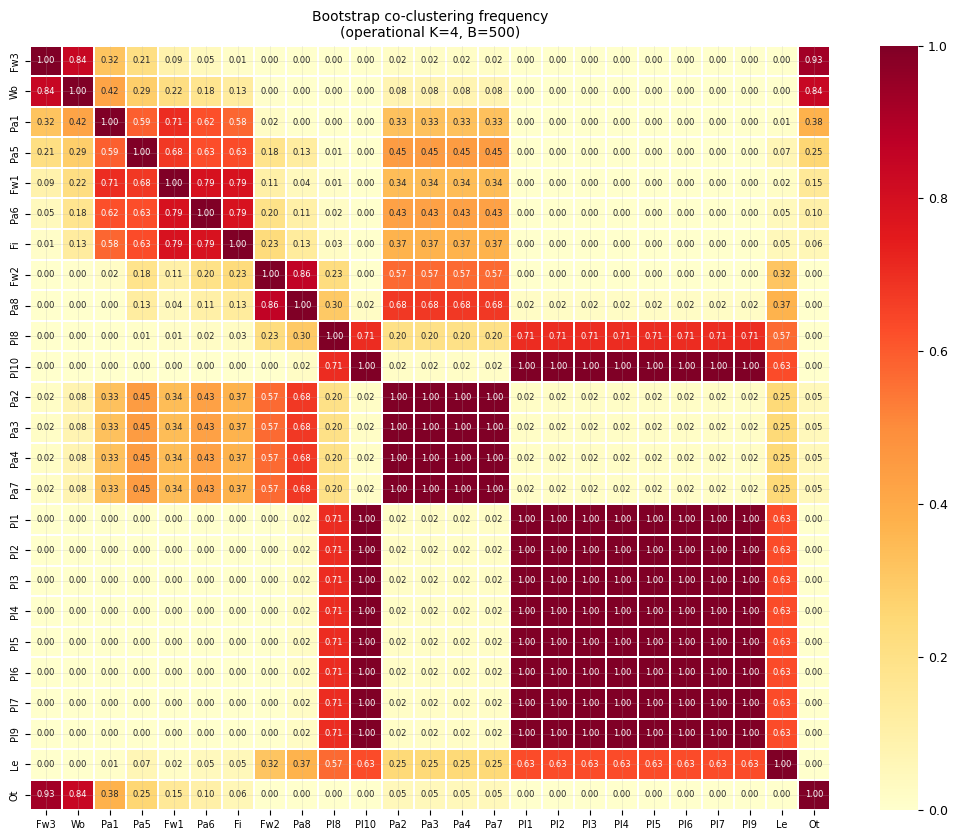

In [ ]:
# ── §6d Bootstrap co-clustering of the operational procedure ───────────────
# Corresponds to: Table S9 and Figure S3
if not RUN_FINAL_BOOTSTRAP:
    print("Section 6d skipped (RUN_FINAL_BOOTSTRAP=False).")
else:
    # ── 6d. Bootstrap co-clustering ──────────────────────────────────────────────
    # N_BOOTSTRAP resamples of df_train; in each, re-fit Ridge, recompute resample abundance weights, and run
    # weighted segmentation (K=RECOMMENDED_K).  Outputs:
    #   (i)  pairwise co-clustering frequency matrix + heatmap (Figure S3)
    #   (ii) item 10 — summary per main-analysis group: within-group minimum and
    #        mean co-clustering frequency, plus each boundary component's highest
    #        co-clustering rate with any out-of-group component.
    # Corresponds to: Table S9 and Figure S3
    np.random.seed(RANDOM_STATE)
    # FINAL-MODEL membership stability: co-clustering over ALL combustible
    # components (weighted segmentation + deterministic allocation, per resample)
    boot_codes = list(ordered_codes_lm) + [c for c in FINE_CATEGORIES
                                            if c not in ordered_codes_lm]
    n_codes   = len(boot_codes)
    co_count  = np.zeros((n_codes, n_codes), dtype=int)

    print(f"Running {N_BOOTSTRAP} bootstrap resamples  "
          f"(operational K={FINAL_K}, components={n_codes})...")
    for b in range(N_BOOTSTRAP):
        idx_b  = np.random.choice(len(df_train), size=len(df_train), replace=True)
        df_b   = df_train.iloc[idx_b].reset_index(drop=True)
        X_b    = build_X(df_b, LM_codes, S_codes)
        y_b    = df_b[DBH_COL].astype(float).values
        m_b    = Ridge(alpha=ALPHA_MAIN, fit_intercept=False).fit(X_b.values, y_b)
        coef_b = dict(zip(X_b.columns, m_b.coef_))
        beta_b = [coef_b.get(c, 0.0) for c in ordered_codes_lm]
        order_b = [ordered_codes_lm[i] for i in np.argsort(beta_b)]
        # E: recompute abundance weights from THIS bootstrap resample so that both
        # beta_j^(b) and p_j^(b) enter the wseg objective; LM membership itself
        # stays fixed at the main-analysis LM set.
        ab_b = compute_abundance(df_b, FINE_CATEGORIES)
        share_map_b = dict(zip(ab_b["code"], ab_b["mean_pct"]))
        grps_b_lm, _ = seg_groups(order_b, sorted(beta_b), FINAL_K,
                                   share_map_b, context="6d-bootstrap")
        # complete to operational membership (allocation per resample)
        grps_b, _ = complete_operational_from_lm(grps_b_lm, df_b, ab_b, S_codes)
        for grp_b in grps_b:
            for ca, cb in combinations(grp_b, 2):
                ia, ib = boot_codes.index(ca), boot_codes.index(cb)
                co_count[ia, ib] += 1
                co_count[ib, ia] += 1
        for c_idx in range(n_codes):
            co_count[c_idx, c_idx] += 1
        if (b + 1) % 100 == 0:
            print(f"  {b+1}/{N_BOOTSTRAP} done")

    co_freq = co_count / N_BOOTSTRAP
    co_df   = pd.DataFrame(co_freq, index=boot_codes, columns=boot_codes)
    co_df.to_csv(TBL_DIR  / "internal_bootstrap_coclustering_matrix.csv")
    co_df.to_excel(TBL_DIR / "internal_bootstrap_coclustering_matrix.xlsx")
    register_output(TBL_DIR / "internal_bootstrap_coclustering_matrix.csv")
    register_output(TBL_DIR / "internal_bootstrap_coclustering_matrix.xlsx")

    # ── Item 10: per-group summary + boundary-component cross-group rates ────────
    main_groups_boot = operational_results[FINAL_K]["groups"]
    _grp_of = {c: gi for gi, mem in enumerate(main_groups_boot, 1) for c in mem}
    boot_sum_rows = []
    for gi, mem in enumerate(main_groups_boot, 1):
        if len(mem) >= 2:
            _pairs = [co_df.loc[a, b] for a, b in combinations(mem, 2)]
            w_min, w_mean = float(np.min(_pairs)), float(np.mean(_pairs))
        else:
            w_min = w_mean = np.nan   # singleton group: no within-group pair
        boot_sum_rows.append({"group": f"Group{gi}", "members": ",".join(mem),
            "n_members": len(mem),
            "within_min_cofreq":  round(w_min, 3)  if len(mem) >= 2 else "singleton",
            "within_mean_cofreq": round(w_mean, 3) if len(mem) >= 2 else "singleton"})
    boot_sum_df = pd.DataFrame(boot_sum_rows)

    cross_rows = []
    for c in boot_codes:
        out_codes = [o for o in boot_codes if _grp_of[o] != _grp_of[c]]
        if not out_codes: continue
        x = co_df.loc[c, out_codes]
        cross_rows.append({"code": c, "main_group": f"Group{_grp_of[c]}",
            "max_crossgroup_cofreq": round(float(x.max()), 3),
            "max_crossgroup_partner": x.idxmax()})
    cross_df = (pd.DataFrame(cross_rows)
                .sort_values("max_crossgroup_cofreq", ascending=False)
                .reset_index(drop=True))

    save_table(boot_sum_df, "internal_bootstrap_group_summary")
    BOOTSTRAP_INTERPRETATION_NOTE = (
        "Components allocated by rule carry no independently estimated coefficients; identical "
        "or highly similar bootstrap profiles among them arise because they "
        "follow the same deterministic allocation rule. The matrix therefore "
        "measures the stability of the complete operational procedure, not the "
        "independent thermal-coefficient stability of each allocated component. A low "
        "within-group co-clustering value for a group (e.g. G2) reflects "
        "boundary movement of its diagnostic anchor components propagating to the S "
        "components attached to the same diagnostic anchors, not independent "
        "instability of every "
        "member.")
    print("§6d note:", BOOTSTRAP_INTERPRETATION_NOTE)
    save_table(cross_df, "internal_bootstrap_crossgroup_rates")
    print()
    print("Within-group co-clustering summary:")
    display(boot_sum_df)
    print("Top boundary components (highest cross-group co-clustering):")
    display(cross_df.head(5))

    fig_s3, ax_s3 = plt.subplots(figsize=(10.5, 8.5))
    sns.heatmap(co_df, ax=ax_s3, cmap="YlOrRd", vmin=0, vmax=1,
                annot=True, fmt=".2f", annot_kws={"size": 6},
                linewidths=0.3, linecolor="white")
    ax_s3.set_title(f"Bootstrap co-clustering frequency\n"
                    f"(operational K={FINAL_K}, B={N_BOOTSTRAP})", fontsize=10)
    ax_s3.tick_params(axis="both", labelsize=7)
    fig_s3.tight_layout()
    save_figure(fig_s3, "Figure_S3_bootstrap_coclustering"); plt.show()
    BOOTSTRAP_USES_RESAMPLE_SHARES = True   # audited in Section P

In [ ]:
# ── §6e Literature-architecture estimator sensitivity ──────────────────────
# Corresponds to: Tables S10-S11 ────────────────────────────
# The published-formula architectures are re-estimated with a common
# zero-intercept Ridge estimator using the design matrices of §3.5.
print("Ridge-refitted literature formulas A1–A5")
s6g_rows = []
for name in ["A1", "A2", "A3", "A4", "A5"]:
    Xtr_g = _X_tr(name)
    Xte_g = _X_te(name)
    y_tr_g = df_train[DBH_COL].astype(float).values
    y_te_g = df_test[DBH_COL].astype(float).values
    W_g    = df_test[WATER_COL].astype(float).values
    y_hhv_g = df_test[HHV_COL].astype(float).values

    m_g = Ridge(alpha=ALPHA_MAIN, fit_intercept=False).fit(Xtr_g, y_tr_g)
    pred_dbh_g = m_g.predict(Xte_g)
    pred_hhv_g = pred_dbh_g * (100.0 - W_g) / 100.0
    s6g_rows.append({
        "model": f"{name}_Ridge(α={ALPHA_MAIN})",
        "test_dbh_rmse": round(float(np.sqrt(mean_squared_error(y_te_g, pred_dbh_g))), 1),
        "test_dbh_r2":   round(float(r2_score(y_te_g, pred_dbh_g)), 3),
        "test_hhv_rmse": round(float(np.sqrt(mean_squared_error(y_hhv_g, pred_hhv_g))), 1),
        "test_hhv_r2":   round(float(r2_score(y_hhv_g, pred_hhv_g)), 3),
    })
    print(f"  {name}  DBH RMSE={s6g_rows[-1]['test_dbh_rmse']:.1f}  "
          f"HHV R²={s6g_rows[-1]['test_hhv_r2']:.3f}")

# Reference row: main K=RECOMMENDED_K model
# test_dbh_r2 is not stored in metrics; recompute from stored model + X_te
_ref_rk   = operational_results[FINAL_K]
_ref_met  = _ref_rk["metrics"]
_pred_ref = _ref_rk["model"].predict(build_X_groups(df_test, _ref_rk["gd"]).values)
_r2_ref   = float(r2_score(df_test[DBH_COL].astype(float).values, _pred_ref))
s6g_rows.append({"model": f"K={FINAL_K}_operational_this_study_Ridge(α={ALPHA_MAIN})",
                  "test_dbh_rmse": round(_ref_met["test_dbh_rmse"], 1),
                  "test_dbh_r2":   round(_r2_ref, 3),
                  "test_hhv_rmse": round(_ref_met["test_hhv_rmse"], 1),
                  "test_hhv_r2":   round(_ref_met["test_hhv_r2"],   3)})

s6g_df = pd.DataFrame(s6g_rows)
save_table(s6g_df, "internal_literature_ridge_refit")
display(s6g_df)

# ── §6e publication table: OLS vs Ridge for the SAME literature architectures
_ols = (table5_df[table5_df["type"] == "OLS_refitted"]
        .assign(base=lambda d: d["model"].str.replace("_OLS", "", regex=False))
        .set_index("base"))
_rid = (s6g_df[s6g_df["model"].str.contains("_Ridge", na=False)]
        .assign(base=lambda d: d["model"].str.split("_").str[0])
        .set_index("base"))
_est_rows = []
for a_ in ["A1", "A2", "A3", "A4", "A5"]:
    o_d, r_d = float(_ols.loc[a_, "test_dbh_rmse"]), float(_rid.loc[a_, "test_dbh_rmse"])
    _est_rows.append({"Model": a_,
        "OLS recalibrated test DBH RMSE": round(o_d, 1),
        "Ridge a=500 test DBH RMSE": round(r_d, 1),
        "Difference (Ridge - OLS)": round(r_d - o_d, 1),
        "OLS test HHV RMSE": round(float(_ols.loc[a_, "test_hhv_rmse"]), 1),
        "Ridge test HHV RMSE": round(float(_rid.loc[a_, "test_hhv_rmse"]), 1)})
literature_estimator_comparison_df = pd.DataFrame(_est_rows)
print("Max |Ridge - OLS| test DBH RMSE difference: "
      f"{literature_estimator_comparison_df['Difference (Ridge - OLS)'].abs().max():.1f} kcal/kg")

# reference models reported separately (definitions differ; not merged)
_ref_rows = pd.DataFrame([
    {"Model": "7C conventional (Ridge a=500)",
     "test DBH RMSE": round(trad_metrics["test_dbh_rmse"], 1),
     "test HHV RMSE": round(trad_metrics["test_hhv_rmse"], 1)},
    {"Model": f"Operational K={FINAL_K} (this study, Ridge a=500)",
     "test DBH RMSE": round(operational_results[FINAL_K]["metrics"]["test_dbh_rmse"], 1),
     "test HHV RMSE": round(operational_results[FINAL_K]["metrics"]["test_hhv_rmse"], 1)}])
# reference models kept as an internal output (not a manuscript table)
save_table(_ref_rows, "internal_literature_reference_models")
display(literature_estimator_comparison_df)

# ── §6e coefficient table: published / Ridge-refitted / OLS-refitted ───────
_PUBC = {"A1": [("Pl",88.2),("Pa+Fw",40.5)],
         "A2": [("Pa",38.52),("Pl",92.09),("Fi",49.24),("Wo",38.34),("Fw",37.55),("Le",64.07)],
         "A3": [("Pa",35.19),("Pl",71.17),("Fi",36.24),("Wo",48.06),("Fw",42.21),("Ot",44.00)],
         "A4": [("Pa",39.04),("Pl",101.47),("Fw",38.47)],
         "A5": [("Pa",47.3),("Pl",58.6),("Fi",38.6),("Wo",32.4),("Fw",45.2),("Le",62.3),("Ot",50.1)]}
_y_tr_lit = df_train[DBH_COL].astype(float).values
_coef_rows = []
for a_, terms in _PUBC.items():
    Xtr_ = _X_tr(a_)
    cR = Ridge(alpha=ALPHA_MAIN, fit_intercept=False).fit(Xtr_, _y_tr_lit).coef_
    cO = LinearRegression(fit_intercept=False).fit(Xtr_, _y_tr_lit).coef_
    for j, (term, cp) in enumerate(terms):
        _coef_rows.append({"Model": a_, "Term": term, "Published coefficient": cp,
            "Ridge-refitted coefficient": round(float(cR[j]), 2),
            "OLS-refitted coefficient": round(float(cO[j]), 2)})
literature_coefficients_df = pd.DataFrame(_coef_rows)
# Table S11 is exported by the canonical exporter in §7b.

Ridge-refitted literature formulas A1–A5
  A1  DBH RMSE=513.7  HHV R²=0.525
  A2  DBH RMSE=422.6  HHV R²=0.678
  A3  DBH RMSE=440.4  HHV R²=0.648
  A4  DBH RMSE=517.5  HHV R²=0.517
  A5  DBH RMSE=420.5  HHV R²=0.682


,model,test_dbh_rmse,test_dbh_r2,test_hhv_rmse,test_hhv_r2
0,A1_Ridge(α=500),513.7,-0.045,247.5,0.525
1,A2_Ridge(α=500),422.6,0.293,203.7,0.678
2,A3_Ridge(α=500),440.4,0.232,212.9,0.648
3,A4_Ridge(α=500),517.5,-0.060,249.5,0.517
4,A5_Ridge(α=500),420.5,0.300,202.5,0.682
5,K=4_operational_this_study_Ridge(α=500),402.1,0.360,193.7,0.709


Max |Ridge - OLS| test DBH RMSE difference: 3.3 kcal/kg


,Model,OLS recalibrated test DBH RMSE,Ridge a=500 test DBH RMSE,Difference (Ridge - OLS),OLS test HHV RMSE,Ridge test HHV RMSE
0,A1,512.8,513.7,0.9,246.9,247.5
1,A2,420.9,422.6,1.7,202.9,203.7
2,A3,438.5,440.4,1.9,211.5,212.9
3,A4,516.5,517.5,1.0,248.9,249.5
4,A5,417.2,420.5,3.3,200.8,202.5


## Section 7: Reproducibility record and publication outputs

This section records software versions and the fixed analysis parameters, lists
the generated manuscript tables and figures, and performs the publication
consistency checks.

In [ ]:
# ── Section 7: Reproducibility summary and output manifest ─────────────────
import subprocess as _sp

print("=" * 70)
print("REPRODUCIBILITY SUMMARY")
print("=" * 70)
print(f"Python     : {platform.python_version()}  ({platform.system()} "
      f"{platform.machine()})")
print(f"pandas     : {pd.__version__}    numpy: {np.__version__}")
print(f"scipy      : {scipy.__version__}    sklearn: {sklearn.__version__}")
print(f"matplotlib : {matplotlib.__version__}    seaborn: {sns.__version__}")
print()
print("Analysis parameters (Section 0):")
print(f"  RANDOM_STATE       = {RANDOM_STATE}")
print(f"  ALPHA_MAIN         = {ALPHA_MAIN}")
print(f"  TEST_SIZE          = {TEST_SIZE}")
print(f"  N_SPLITS / N_REPEATS = {N_SPLITS} / {N_REPEATS}")
print(f"  K_RANGE            = {K_RANGE}")
print(f"  HHV_C_THRESHOLD    = {HHV_C_THRESHOLD}")
print(f"  K_TOLERANCES       = {K_TOLERANCES} (main: {MAIN_K_TOLERANCE:.0%})")
print(f"  FINAL_K            = {FINAL_K}")
print(f"  N_BOOTSTRAP        = {N_BOOTSTRAP}")
print(f"  ALPHA_CANDIDATES   = {ALPHA_CANDIDATES} (main: {ALPHA_MAIN})")
print(f"  MIN_GROUP_SHARE    = {MIN_GROUP_SHARE}% (minimum dry-basis share per gap-group)")
print(f"  L/M/S thresholds   = {L_THRESHOLD}% / {M_THRESHOLD}%")
print()
print("Archive placeholders (fill before submission):")
print("  GitHub release tag : [github.com/<user>/<repo>, tag vX.Y.Z]")
print("  Zenodo DOI         : [10.5281/zenodo.XXXXXXX]")
print()
print(f"Dataset: {len(df_clean)} samples (after QA/QC)  |  "
      f"{len(FINE_CATEGORIES)} composition components")
print(f"Train / Test split : {len(df_train)} / {len(df_test)} samples")
print(f"LM_RECOMMENDED_K   : {LM_RECOMMENDED_K}   OPERATIONAL_RECOMMENDED_K: {OPERATIONAL_RECOMMENDED_K}")
print()
_unique_outputs = sorted(set(OUTPUT_FILE_REGISTRY))
print(f"Registered output files ({len(_unique_outputs)}):")
for _f in _unique_outputs:
    print(f"  {_f}")

# Minimal requirements.txt (direct dependencies only) + full pip freeze
_req = "".join(f"{name}=={ver}" + chr(10) for name, ver in [
    ("numpy", np.__version__), ("pandas", pd.__version__),
    ("scipy", scipy.__version__), ("scikit-learn", sklearn.__version__),
    ("matplotlib", matplotlib.__version__), ("seaborn", sns.__version__),
    ("openpyxl", __import__("openpyxl").__version__)])
_req_path = OUTPUT_DIR / "requirements.txt"
_req_path.write_text(_req)
register_output(_req_path)
print(f"requirements.txt saved to: {_req_path}")
try:
    _pip_out = _sp.run(["pip", "freeze"], capture_output=True, text=True).stdout
    _pkg_path = OUTPUT_DIR / "package_versions_full.txt"
    _pkg_path.write_text(_pip_out)
    register_output(_pkg_path)
    print(f"Full pip freeze saved to: {_pkg_path}")
except Exception as _e:
    print(f"pip freeze failed: {_e}")

print()
print("=" * 70)
print("All outputs written.  Notebook execution complete.")
print("=" * 70)

REPRODUCIBILITY SUMMARY
Python     : 3.12.13  (Linux x86_64)
pandas     : 2.2.2    numpy: 2.0.2
scipy      : 1.16.3    sklearn: 1.6.1
matplotlib : 3.10.0    seaborn: 0.13.2

Analysis parameters (Section 0):
  RANDOM_STATE       = 42
  ALPHA_MAIN         = 500
  TEST_SIZE          = 0.2
  N_SPLITS / N_REPEATS = 5 / 20
  K_RANGE            = [2, 3, 4, 5, 6, 7]
  HHV_C_THRESHOLD    = 140.0
  K_TOLERANCES       = [0.01, 0.02, 0.03] (main: 1%)
  FINAL_K            = 4
  N_BOOTSTRAP        = 500
  ALPHA_CANDIDATES   = [50, 100, 200, 300, 500, 750, 1000, 2000] (main: 500)
  MIN_GROUP_SHARE    = 1.5% (minimum dry-basis share per gap-group)
  L/M/S thresholds   = 5.0% / 1.5%

Archive placeholders (fill before submission):
  GitHub release tag : [github.com/<user>/<repo>, tag vX.Y.Z]
  Zenodo DOI         : [10.5281/zenodo.XXXXXXX]

Dataset: 589 samples (after QA/QC)  |  25 composition components
Train / Test split : 471 / 118 samples
LM_RECOMMENDED_K   : 4   OPERATIONAL_RECOMMENDED_K: 4

Registe

## Section 7b: Publication output export

Writes the manuscript tables and figures with their final numbering.

Main text: Table 1 (within-major-category heterogeneity), Table 2 (complete
operational K=2-7 performance), Table 3 (literature-reported formula transfer and
recalibration); Figures 1-3.

Supplementary: Table S2 (component descriptive statistics), Table S4 (final K=4
component mapping), Table S5 (fixed-structure LOYO), Table S6 (strict final-year
re-derivation), Table S7 (threshold sensitivity), Table S8 (alpha sensitivity),
Table S9 (bootstrap summary), Table S10 (OLS versus Ridge estimator
sensitivity), Table S11 (published and recalibrated coefficients);
Figures S1-S3.

In [ ]:
# ── Section 7b: Canonical publication export ───────────────────────────────
# Builds one canonical dataframe per manuscript table, writes CSV + XLSX (and a
# footnote file where the manuscript carries one), and rebuilds the publication
# manifest. Intermediate and audit tables produced by earlier sections remain in
# the internal tables directory and are not exported here.

PUBLICATION_MANIFEST = []          # rebuilt from scratch in a fixed order

def export_publication_table(df, stem, label, section, footnote=None):
    """Write one canonical manuscript table and register it in the manifest."""
    csv_p  = PUB_DIR_OUT / f"{stem}.csv"
    xlsx_p = PUB_DIR_OUT / f"{stem}.xlsx"
    df.to_csv(csv_p, index=False, encoding="utf-8-sig", na_rep="")
    df.to_excel(xlsx_p, index=False)
    register_output(csv_p); register_output(xlsx_p)
    if footnote:
        fn_p = PUB_DIR_OUT / f"{stem}_footnote.txt"
        fn_p.write_text(footnote, encoding="utf-8")
        register_output(fn_p)
    PUBLICATION_MANIFEST.append((label, f"{stem}.csv", section))
    print(f"  {label:<62s} {stem}.csv")
    return df

def register_publication_figure(label, stem, section):
    if (FIG_DIR / f"{stem}.pdf").exists():
        PUBLICATION_MANIFEST.append((label, f"{stem}.pdf (figures/)", section))
        print(f"  {label:<62s} {stem}.pdf")

_EM = "—"
print("Canonical publication outputs")
print("-" * 96)

# ── Main Table 1 ───────────────────────────────────────────────────────────
_NAME_FIX = {"Paper-based": "Paper products"}
_t1 = table3_df.copy()
pub_table1 = pd.DataFrame({
    "Conventional major category": _t1["conventional_group"].replace(_NAME_FIX),
    "N_LM": _t1["n_codes"].astype(int),
    "Mean LM share (%)": _t1["mean_pct_group"].round(2),
    "Minimum mean effective coefficient": _t1["coef_min"].round(2),
    "Maximum mean effective coefficient": _t1["coef_max"].round(2),
    "Code at minimum": _t1["coef_min_code"],
    "Code at maximum": _t1["coef_max_code"],
    "Coefficient range": _t1["Range_G"].round(2),
    "Range-based screening index": _t1["I_LM_G"].round(1)})
export_publication_table(pub_table1, "Table_1_within_major_category_heterogeneity",
    "Table 1 - within-major-category heterogeneity", "§3.3",
    footnote=(
        "Table 1. Within-major-category heterogeneity of effective DBH coefficients "
        "among independently estimated LM sub-categories.\n\n"
        "Minimum and maximum values are mean effective coefficients (beta-bar_j) of "
        "individual composition components, averaged over repeated cross-validation "
        "fits of the LM diagnostic model; they are not refitted thermal-group "
        "coefficients (gamma_g), which apply only to grouped models. Coefficients and "
        "the coefficient range are expressed in kcal kg-1 per dry-basis percentage "
        "point; the range-based screening index (coefficient range multiplied by the "
        "group's mean LM share) is expressed in kcal kg-1. Only conventional major "
        "categories containing at least two independently estimated LM sub-categories "
        "are shown."))

# ── Main Table 2 ───────────────────────────────────────────────────────────
_t2 = op_df.copy()
_rows2 = pd.DataFrame({
    "K": _t2["K"].astype(str),
    "CV DBH RMSE (kcal/kg)": _t2["cv_dbh_rmse"].round(1),
    "Difference from minimum (%)": _t2["delta_cv_pct"].round(2),
    "Test DBH RMSE (kcal/kg)": _t2["test_dbh_rmse"].round(1),
    "Test HHV RMSE (kcal/kg)": _t2["test_hhv_rmse"].round(1),
    "Test HHV R2": _t2["test_hhv_r2"].round(3),
    "Minimum group share (%)": _t2["min_group_share"].round(2),
    "Near-best at 1%": np.where(_t2["within_1pct"], "Yes", "No"),
    "Near-best at 2%": np.where(_t2["within_2pct"], "Yes", "No"),
    "Near-best at 3%": np.where(_t2["within_3pct"], "Yes", "No")})
# 7C is an external baseline: its CV RMSE and difference from the operational
# minimum are descriptive; the minimum is taken over K=2-7 only, and 7C is not a
# candidate in the practical-equivalence selection.
_op_min_unrounded = float(min(operational_results[K]["metrics"]["cv_dbh_rmse"]
                              for K in K_RANGE))
_7c_cv_unrounded  = float(trad_metrics["cv_dbh_rmse"])
_7c_delta_pct = 100.0 * (_7c_cv_unrounded - _op_min_unrounded) / _op_min_unrounded
_ref7c = pd.DataFrame([{
    "K": "7C",
    "CV DBH RMSE (kcal/kg)": round(_7c_cv_unrounded, 1),
    "Difference from minimum (%)": round(_7c_delta_pct, 2),
    "Test DBH RMSE (kcal/kg)": round(trad_metrics["test_dbh_rmse"], 1),
    "Test HHV RMSE (kcal/kg)": round(trad_metrics["test_hhv_rmse"], 1),
    "Test HHV R2": round(trad_metrics["test_hhv_r2"], 3),
    "Minimum group share (%)": np.nan,
    "Near-best at 1%": _EM, "Near-best at 2%": _EM, "Near-best at 3%": _EM}])
pub_table2 = pd.concat([_rows2, _ref7c], ignore_index=True)
export_publication_table(pub_table2, "Table_2_operational_K_resolution",
    "Table 2 - complete operational regrouping, K=2-7", "§3.4c",
    footnote=(
        "Table 2. Predictive performance of the complete operational regrouping "
        "models.\n\n"
        f"CV values are training-set repeated {N_SPLITS}-fold cross-validation with "
        f"{N_REPEATS} repeats. A model is feasible when its group coefficients are "
        f"monotonic and its minimum group share is at least {MIN_GROUP_SHARE}% on a "
        "dry basis. Among feasible models, the smallest K whose CV DBH RMSE lies "
        "within the stated tolerance above the minimum is selected; the main analysis "
        f"uses a {MAIN_K_TOLERANCE:.0%} tolerance, giving K = {FINAL_K}. Test metrics "
        "are reported after selection and were not used to select K. 7C denotes the "
        "conventional seven-category model. The 7C model is included as an "
        "external baseline. Its CV RMSE and difference from the operational "
        "minimum are reported descriptively, but it was not included in the "
        "practical-equivalence selection of K; therefore, minimum-group-share "
        "and near-best indicators do not apply."))

# ── Main Table 3 ───────────────────────────────────────────────────────────
_pub = table5_df[table5_df["type"] == "published"].set_index("model")
_rec = (table5_df[table5_df["type"] == "OLS_refitted"]
        .assign(base=lambda d: d["model"].str.replace("_OLS", "", regex=False))
        .set_index("base"))
_P = {"A1": 2, "A2": 6, "A3": 6, "A4": 3, "A5": 7}
_NOTE = {
    "A1": "JNMSWF (1991), reported in Chang et al. (2007) and Lin et al. (2013)*",
    "A2": "Lin (2000), reported in Chang et al. (2007) and Lin et al. (2013)*",
    "A3": "Chang et al. (2007)",
    "A4": "Chang et al. (2007)",
    "A5": "Lin et al. (2013)"}
_rows3 = []
for a_ in ["A1", "A2", "A3", "A4", "A5"]:
    _rows3.append({"Model": a_, "p": _P[a_],
        "Test DBH RMSE: original": round(float(_pub.loc[a_, "test_dbh_rmse"]), 1),
        "Test DBH RMSE: recalibrated": round(float(_rec.loc[a_, "test_dbh_rmse"]), 1),
        "Test HHV RMSE: original": round(float(_pub.loc[a_, "test_hhv_rmse"]), 1),
        "Test HHV RMSE: recalibrated": round(float(_rec.loc[a_, "test_hhv_rmse"]), 1),
        "Reference / note": _NOTE[a_]})
_rows3.append({"Model": "7C", "p": 7,
    "Test DBH RMSE: original": _EM,
    "Test DBH RMSE: recalibrated": round(trad_metrics["test_dbh_rmse"], 1),
    "Test HHV RMSE: original": _EM,
    "Test HHV RMSE: recalibrated": round(trad_metrics["test_hhv_rmse"], 1),
    "Reference / note": "\u2248 A5 recalibrated"})
_opm = operational_results[FINAL_K]["metrics"]
_rows3.append({"Model": f"Operational K={FINAL_K}", "p": FINAL_K,
    "Test DBH RMSE: original": _EM,
    "Test DBH RMSE: recalibrated": round(_opm["test_dbh_rmse"], 1),
    "Test HHV RMSE: original": _EM,
    "Test HHV RMSE: recalibrated": round(_opm["test_hhv_rmse"], 1),
    "Reference / note": "Recommended"})
pub_table3 = pd.DataFrame(_rows3)
export_publication_table(pub_table3, "Table_3_published_formula_transfer",
    "Table 3 - literature-reported formula transfer and recalibration", "§3.5",
    footnote=(
        "Table 3. Transfer and recalibration of literature-reported "
        "physical-composition kernels (kcal/kg).\n\n"
        "*The original sources attributed to A1 and A2 could not be retrieved. "
        "Their equations, coefficients, and source attributions were taken from "
        "Chang et al. (2007) and Lin et al. (2013), which reported the same formula "
        "structures and coefficient values. The A1 and A2 results therefore evaluate "
        "the coefficient sets reproduced in these later publications. For A1-A5, the "
        "reported dry-basis compositional kernels were used to predict DBH, and the "
        "resulting DBH estimates were converted to HHV using measured moisture "
        "according to Eq. (1). The full formula definitions, basis conventions, "
        "category mappings, and source notes are provided in Supplementary S2.\n\n"
        "7C denotes the conventional seven-category Ridge model; p is the number of "
        "composition variables. Estimator sensitivity and recalibrated coefficient "
        "comparisons are reported in Supplementary S4."))

# ── Table S2 ───────────────────────────────────────────────────────────────
def _ms(col):
    if col in df_clean.columns:
        v = df_clean[col].astype(float)
        return round(float(v.mean()), 2), round(float(v.std(ddof=1)), 2)
    return 0.00, 0.00                      # component absent after screening
_S2_DRY = [("Total combustibles", "Total combustibles", "DALLCom"),
           ("Paper products", "Total paper products", "DallP")]
_S2_DRY += [("Paper products", FINE_CATEGORY_NAMES.get(f"Pa{i}", f"Pa{i}"), f"Pa{i}")
            for i in range(1, 9)]
_S2_DRY += [("Plastics", "Total plastics", "DallL")]
_S2_DRY += [("Plastics", FINE_CATEGORY_NAMES.get(f"Pl{i}", f"Pl{i}"), f"Pl{i}")
            for i in range(1, 12)]
_S2_DRY += [("Food waste", "Total food waste", "DallFW")]
_S2_DRY += [("Food waste", FINE_CATEGORY_NAMES.get(f"Fw{i}", f"Fw{i}"), f"Fw{i}")
            for i in range(1, 4)]
_S2_DRY += [("Other combustibles", FINE_CATEGORY_NAMES.get(c, c), c)
            for c in ["Fi", "Wo", "Le", "Ot"]]
_S2_DRY += [("Total non-combustibles", "Total non-combustibles", "DALLnonCom")]
_S2_WET = [("Proximate composition (wet basis)", "Moisture content", "water"),
           ("Proximate composition (wet basis)", "Ash", "Pash"),
           ("Proximate composition (wet basis)", "Combustibles", "Pcombus")]
_rows_s2 = []
for _sec, _item, _col in _S2_DRY:
    m, s = _ms(_col)
    _rows_s2.append({"Section": "Physical composition (dry basis)"
                     if _sec in ("Total combustibles", "Total non-combustibles") else _sec,
                     "Item": _item,
                     "Code": _col if _col in FINE_CATEGORIES or _col.startswith(("Pa","Pl","Fw")) else "",
                     "Mean (%)": m, "SD (%)": s})
for _sec, _item, _col in _S2_WET:
    m, s = _ms(_col)
    _rows_s2.append({"Section": _sec, "Item": _item, "Code": "", "Mean (%)": m, "SD (%)": s})
pub_tableS2 = pd.DataFrame(_rows_s2).fillna({"Code": ""})
pub_tableS2["Code"] = pub_tableS2["Code"].astype(str).replace("nan", "")
export_publication_table(pub_tableS2, "Table_S2_component_descriptive_statistics",
    "Table S2 - component descriptive statistics", "§7b",
    footnote=(
        f"Table S2. Descriptive statistics of the screened dataset (n = {len(df_clean)}).\n\n"
        "Physical-composition values are dry-basis percentages of total sample mass; "
        "proximate variables are wet-basis percentages. Component Pl11 is retained for "
        "completeness and is zero in every record, so it is excluded from the "
        f"{len(FINE_CATEGORIES)}-component modelling set. Group totals are computed "
        "directly from the dataset."))

# ── Table S4 ───────────────────────────────────────────────────────────────
_alloc4 = operational_results[FINAL_K]["alloc"]
_lms_map = dict(zip(abundance_train["code"], abundance_train["lms_class"]))
_grp4 = {c: gi + 1 for gi, mem in enumerate(operational_results[FINAL_K]["groups"])
         for c in mem}
_rows_s4 = []
for c_ in FINE_CATEGORIES:
    _basis = ("LM" if c_ in LM_codes else
              ("R1" if _alloc4[c_][1].startswith("R1") else "R2"))
    _rows_s4.append({
        "Conventional major category": CONVENTIONAL_GROUP_MAP.get(c_, "").replace(
            "Paper-based", "Paper products"),
        "Composition component": c_,
        "L/M/S": _lms_map[c_],
        f"Operational K={FINAL_K} group": f"G{_grp4[c_]}",
        "Training-set mean share (%)": round(float(
            abundance_train.loc[abundance_train["code"] == c_, "mean_pct"].iloc[0]), 2),
        "Allocation basis": _basis})
pub_tableS4 = (pd.DataFrame(_rows_s4)
               .sort_values([f"Operational K={FINAL_K} group",
                             "Training-set mean share (%)"],
                            ascending=[True, False]).reset_index(drop=True))
export_publication_table(pub_tableS4, "Table_S4_final_operational_mapping",
    f"Table S4 - final operational K={FINAL_K} mapping", "§3.4c",
    footnote=(
        f"Table S4. Assignment of all {len(FINE_CATEGORIES)} composition components to "
        f"the {FINAL_K} terminal operational groups.\n\n"
        "L/M/S gives the training-set prevalence label of each component "
        "(L >= 5%, M 1.5-5%, S < 1.5%). Allocation basis: LM, component "
        "modelled individually at the diagnostic "
        "stage; R1, allocated to the group holding the largest summed training-set "
        "share of diagnostic anchors from the same conventional major category; R2, "
        "allocated to the group whose coefficient is closest to the training-set "
        "seven-category effective coefficient of that major category. The operational "
        "model retains no residual predictor."))

# ── Table S5 ───────────────────────────────────────────────────────────────
def _int_or_dash(v):
    try:
        return str(int(float(v)))
    except (TypeError, ValueError):
        return _EM
_l = loyo_summary_df.copy()
pub_tableS5 = pd.DataFrame({
    "Test year": _l["test_year"].astype(str),
    "n train": [_int_or_dash(v) for v in _l["n_train"]],
    "n test": [_int_or_dash(v) for v in _l["n_test"]],
    "Operational DBH RMSE": _l["operational_dbh_rmse"],
    "7C DBH RMSE": _l["7C_dbh_rmse"],
    "A5-OLS DBH RMSE": _l["A5OLS_dbh_rmse"],
    "Operational HHV RMSE": _l["operational_hhv_rmse"]})
export_publication_table(pub_tableS5, "Table_S5_fixed_structure_LOYO",
    "Table S5 - fixed-structure leave-one-year-out validation", "§5a",
    footnote=(
        "Table S5. Fixed-structure leave-one-year-out validation (kcal/kg).\n\n"
        "The operational group membership is held fixed and only the group "
        "coefficients are refitted within each fold. Mean and SD are unweighted "
        "across yearly folds; Pooled concatenates all out-of-fold predictions. The "
        "2015 fold contains only 25 test samples. The final-year fold evaluates 2019 "
        "under the fixed operational classification."))

# ── Table S6 ───────────────────────────────────────────────────────────────
if RUN_STRICT_FINAL_YEAR:
    _p19 = perf19_df.set_index("model")
    _l19 = loyo_perf_df.loc[loyo_perf_df["test_year"] == STRICT_TEST_YEAR].iloc[0]
    # names and structure text are built from the strict selection results,
    # not from FINAL_K: the strict analysis compared K=2-7 on 2014-2018 data,
    # K=4 gave the minimum CV RMSE and K=3 was the tolerance-selected model.
    _strict_k_min = int(sel_str["K_best"])
    _strict_k_tol = int(sel_str["by_tol"][MAIN_K_TOLERANCE]["K_selected"])
    assert _strict_k_min == 4, f"strict minimum-CV K = {_strict_k_min}"
    assert _strict_k_tol == 3, f"strict tolerance-selected K = {_strict_k_tol}"
    _min_key = "SF-B fixed K=4 re-derived"                    # internal identifier
    _tol_key = f"SF-A (tol {MAIN_K_TOLERANCE:.0%})"           # internal identifier
    _yr0, _yr1 = min(STRICT_TRAIN_YEARS), max(STRICT_TRAIN_YEARS)
    pub_tableS6 = pd.DataFrame([
        {"Model": f"Fixed-structure K={FINAL_K} reference",
         "Structure": f"Main K={FINAL_K} membership retained; coefficients refitted "
                      f"on {_yr0}-{_yr1}",
         "K": FINAL_K,
         "2019 DBH RMSE": float(_l19["operational_dbh_rmse"]),
         "2019 HHV RMSE": float(_l19["operational_hhv_rmse"]),
         "2019 HHV R2": float(_l19["operational_hhv_r2"])},
        {"Model": f"Strict re-derived minimum-CV K={_strict_k_min}",
         "Structure": f"Complete procedure re-derived on {_yr0}-{_yr1}; "
                      f"K={_strict_k_min} yielded the minimum CV RMSE",
         "K": _strict_k_min,
         "2019 DBH RMSE": float(_p19.loc[_min_key, "dbh_rmse"]),
         "2019 HHV RMSE": float(_p19.loc[_min_key, "hhv_rmse"]),
         "2019 HHV R2": float(_p19.loc[_min_key, "hhv_r2"])},
        {"Model": f"Strict re-derived tolerance-selected K={_strict_k_tol}",
         "Structure": f"Complete procedure re-derived on {_yr0}-{_yr1}; "
                      f"K={_strict_k_tol} selected as the smallest model within "
                      f"{MAIN_K_TOLERANCE:.0%} of the minimum CV RMSE",
         "K": _strict_k_tol,
         "2019 DBH RMSE": float(_p19.loc[_tol_key, "dbh_rmse"]),
         "2019 HHV RMSE": float(_p19.loc[_tol_key, "hhv_rmse"]),
         "2019 HHV R2": float(_p19.loc[_tol_key, "hhv_r2"])},
        {"Model": "Conventional seven-category model",
         "Structure": f"Seven-category Ridge model fitted on {_yr0}-{_yr1}",
         "K": 7,
         "2019 DBH RMSE": float(_p19.loc["7C (2014-2018 fit)", "dbh_rmse"]),
         "2019 HHV RMSE": float(_p19.loc["7C (2014-2018 fit)", "hhv_rmse"]),
         "2019 HHV R2": float(_p19.loc["7C (2014-2018 fit)", "hhv_r2"])},
        {"Model": "Recalibrated A5-OLS",
         "Structure": f"A5 architecture recalibrated on {_yr0}-{_yr1} using "
                      f"zero-intercept OLS",
         "K": 7,
         "2019 DBH RMSE": float(_p19.loc["A5 OLS (2014-2018 recal.)", "dbh_rmse"]),
         "2019 HHV RMSE": float(_p19.loc["A5 OLS (2014-2018 recal.)", "hhv_rmse"]),
         "2019 HHV R2": float(_p19.loc["A5 OLS (2014-2018 recal.)", "hhv_r2"])},
    ])
    pub_tableS6["2019 HHV R2"] = pub_tableS6["2019 HHV R2"].round(3)
    TABLE_S6_FOOTNOTE = (
        "Table S6. Final-year performance under fixed-structure and strict "
        f"re-derivation analyses ({_yr0}-{_yr1} to {STRICT_TEST_YEAR}).\n\n"
        f"The fixed-structure reference retained the main K={FINAL_K} component "
        "membership and refitted only the four group coefficients using the "
        f"{_yr0}-{_yr1} data. In the strict re-derivation analysis, the complete "
        "procedure - including diagnostic-component ordering, abundance-weighted "
        "segmentation, deterministic allocation, operational-group membership, and "
        f"coefficient estimation - was rerun using only the {_yr0}-{_yr1} data. "
        f"Among the strict candidate models, K={_strict_k_min} yielded the minimum "
        f"cross-validated DBH RMSE, whereas K={_strict_k_tol} was selected by the "
        f"{MAIN_K_TOLERANCE:.0%} practical-equivalence rule as the smallest model "
        f"within {MAIN_K_TOLERANCE:.0%} of that minimum. Both strict solutions were "
        f"evaluated once on the {STRICT_TEST_YEAR} data. The strict analysis retained "
        f"the same {len(LM_codes)} diagnostic components as the main analysis "
        f"(Jaccard index = {_jac:.3f}). For the minimum-CV K={_strict_k_min} solution, "
        f"exact {len(FINE_CATEGORIES)}-component membership agreement with the main "
        f"K={FINAL_K} model was {agree:.1%}, and pairwise co-membership agreement was "
        f"{pairs_agree:.1%}.")
    export_publication_table(pub_tableS6, "Table_S6_strict_final_year",
        "Table S6 - final-year performance, fixed-structure and strict re-derivation",
        "§5b", footnote=TABLE_S6_FOOTNOTE)
    display(pub_tableS6)

# ── Table S7 ───────────────────────────────────────────────────────────────
if RUN_FINAL_MODEL_VALIDATION:
    _s7 = pd.DataFrame(s6a_rows)
    _key = lambda v: 3 if (v is None or str(v).lower() in ("nan", "none")) \
                     else {120: 0, 140: 1, 160: 2}.get(int(float(v)), 9)
    _s7 = _s7.assign(_o=[_key(v) for v in _s7["threshold"]]).sort_values("_o")
    pub_tableS7 = pd.DataFrame({
        "HHV/C threshold": ["No exclusion" if (v is None
                                or (isinstance(v, float) and np.isnan(v))
                                or str(v).lower() in ("nan", "none"))
                    else str(int(float(v))) for v in _s7["threshold"]],
        "n": _s7["n_final"].astype(int).values,
        "Operational CV DBH RMSE": _s7["operational_cv_dbh_rmse"].values,
        "Operational test DBH RMSE": _s7["operational_test_dbh_rmse"].values,
        "n_train": _s7["n_train"].astype(int).values,
        "n_test": _s7["n_test"].astype(int).values,
        "Operational membership identical to paired 140":
            np.where(_s7["groups_identical_to_140"].values, "Yes", "No")})
    export_publication_table(pub_tableS7, "Table_S7_threshold_sensitivity",
        "Table S7 - HHV/carbon threshold sensitivity", "§6a",
        footnote=(
            "Table S7. HHV/carbon exclusion-threshold sensitivity under a paired "
            "split assignment (kcal/kg).\n\n"
            "The sample-to-split assignment is fixed on all raw records before "
            "threshold filtering, so each threshold removes ineligible samples from "
            "within the same pre-assigned partition. The paired 140 design therefore "
            "uses a different training and test sample from the main analysis, and the "
            "values in this table are comparable across threshold rows but should not "
            "be compared directly with main Table 2. Membership is compared with the "
            "paired 140 grouping."))

# ── Table S8 ───────────────────────────────────────────────────────────────
    export_publication_table(alpha_pub_df, "Table_S8_alpha_sensitivity",
        "Table S8 - Ridge alpha sensitivity", "§6b",
        footnote=TABLE_S8_TITLE + "\n\n" + TABLE_S8_FOOTNOTE)

# ── Table S9 ───────────────────────────────────────────────────────────────
if RUN_FINAL_BOOTSTRAP:
    _b = boot_sum_df.copy()
    pub_tableS9 = pd.DataFrame({
        "Main group": _b["group"].str.replace("Group", "G", regex=False),
        "Number of components": _b["n_members"].astype(int),
        "Minimum within-group co-clustering": _b["within_min_cofreq"],
        "Mean within-group co-clustering": _b["within_mean_cofreq"]})
    export_publication_table(pub_tableS9, "Table_S9_bootstrap_summary",
        "Table S9 - bootstrap operational membership stability", "§6d",
        footnote=(
            f"Table S9. Bootstrap stability of the complete operational procedure "
            f"(B = {N_BOOTSTRAP}, K = {FINAL_K}).\n\n"
            "Each bootstrap replicate re-estimates component prevalence and diagnostic "
            "coefficients, repeats the weighted segmentation and the deterministic "
            "allocation, and yields a complete assignment of all "
            f"{len(FINE_CATEGORIES)} composition components. Values are pairwise "
            "co-assignment frequencies among the members of each main operational "
            "group. Components allocated by rule carry no independently estimated "
            "coefficients, so their profiles follow the diagnostic anchors to which "
            "they are attached; the full matrix is shown in Figure S3."))

# ── Tables S10 and S11 ─────────────────────────────────────────────────────
_e = literature_estimator_comparison_df.copy()
pub_tableS10 = pd.DataFrame({
    "Model": _e["Model"],
    "OLS DBH RMSE": _e["OLS recalibrated test DBH RMSE"],
    "Ridge DBH RMSE": _e["Ridge a=500 test DBH RMSE"],
    "Difference in DBH RMSE": _e["Difference (Ridge - OLS)"],
    "OLS HHV RMSE": _e["OLS test HHV RMSE"],
    "Ridge HHV RMSE": _e["Ridge test HHV RMSE"],
    "Difference in HHV RMSE": (_e["Ridge test HHV RMSE"]
                               - _e["OLS test HHV RMSE"]).round(1)})
export_publication_table(pub_tableS10, "Table_S10_estimator_sensitivity",
    "Table S10 - OLS versus Ridge estimator sensitivity", "§3.5 and §6e",
    footnote=(
        "Table S10. Estimator sensitivity of the literature-reported formula architectures "
        "(kcal/kg).\n\n"
        "Each literature-reported architecture is refitted on the training set with "
        "zero-intercept "
        f"ordinary least squares and with zero-intercept Ridge (alpha = {ALPHA_MAIN}) "
        "and evaluated on the held-out test set. Differences between estimators are "
        "small relative to differences between architectures."))
_c = literature_coefficients_df.copy()
pub_tableS11 = _c.rename(columns={
    "Model": "Model", "Term": "Term",
    "Published coefficient": "Published coefficient",
    "Ridge-refitted coefficient": "Ridge-refitted coefficient",
    "OLS-refitted coefficient": "OLS-refitted coefficient"})
export_publication_table(pub_tableS11,
    "Table_S11_published_and_recalibrated_coefficients",
    "Table S11 - published and recalibrated coefficients for A1-A5", "§3.5 and §6e",
    footnote=(
        "Table S11. Published and recalibrated coefficients for A1-A5 "
        "(kcal kg-1 per dry-basis percentage point).\n\n"
        "Recalibrated values are obtained on the training set with the same "
        "literature-reported variable structure, using zero-intercept Ridge "
        f"(alpha = {ALPHA_MAIN}) and zero-intercept ordinary least squares."))

# ── Figures and text statements ────────────────────────────────────────────
print("-" * 96)
register_publication_figure("Figure 1 - component abundance and top-N resolution",
                             "Figure1_abundance_and_coverage", "§3.0")
register_publication_figure("Figure 2 - effective coefficient distributions",
                             "Figure2_coefficient_uncertainty", "§3.2")
register_publication_figure("Figure 3 - segmentation and operational regrouping",
                             "Figure3_regrouping", "§3.4")
register_publication_figure("Figure S1 - LOYO coefficient stability",
                             "Figure_S1_LOYO_coefficient_stability", "§5a")
register_publication_figure("Figure S2 - Ridge alpha sensitivity",
                             "Figure_S2_alpha_sensitivity", "§6b")
register_publication_figure("Figure S3 - bootstrap co-clustering matrix",
                             "Figure_S3_bootstrap_coclustering", "§6d")
if "NONNEG_STATEMENT" in globals():
    (PUB_DIR_OUT / "Supplementary_S4_nonnegative_statement.txt").write_text(
        NONNEG_STATEMENT, encoding="utf-8")
    PUBLICATION_MANIFEST.append(
        ("Supplementary S4 - non-negative coefficient sensitivity (text)",
         "Supplementary_S4_nonnegative_statement.txt", "§6c"))

manifest_df = pd.DataFrame(PUBLICATION_MANIFEST,
                            columns=["Output", "File", "Notebook section"])
assert manifest_df["File"].is_unique, "duplicate entry in the publication manifest"
manifest_df.to_csv(PUB_DIR_OUT / "PUBLICATION_MANIFEST.csv", index=False,
                    encoding="utf-8-sig")
print()
print(manifest_df.to_string(index=False))

Canonical publication outputs
------------------------------------------------------------------------------------------------
  Table 1 - within-major-category heterogeneity                  Table_1_within_major_category_heterogeneity.csv
  Table 2 - complete operational regrouping, K=2-7               Table_2_operational_K_resolution.csv
  Table 3 - literature-reported formula transfer and recalibration Table_3_published_formula_transfer.csv
  Table S2 - component descriptive statistics                    Table_S2_component_descriptive_statistics.csv
  Table S4 - final operational K=4 mapping                       Table_S4_final_operational_mapping.csv
  Table S5 - fixed-structure leave-one-year-out validation       Table_S5_fixed_structure_LOYO.csv
  Table S6 - final-year performance, fixed-structure and strict re-derivation Table_S6_strict_final_year.csv


,Model,Structure,K,2019 DBH RMSE,2019 HHV RMSE,2019 HHV R2
0,Fixed-structure K=4 reference,Main K=4 membership retained; coefficients ref...,4,417.7,217.3,0.668
1,Strict re-derived minimum-CV K=4,Complete procedure re-derived on 2014-2018; K=...,4,443.1,233.0,0.618
2,Strict re-derived tolerance-selected K=3,Complete procedure re-derived on 2014-2018; K=...,3,465.0,245.1,0.578
3,Conventional seven-category model,Seven-category Ridge model fitted on 2014-2018,7,456.3,239.9,0.595
4,Recalibrated A5-OLS,A5 architecture recalibrated on 2014-2018 usin...,7,458.5,241.8,0.589


  Table S7 - HHV/carbon threshold sensitivity                    Table_S7_threshold_sensitivity.csv
  Table S8 - Ridge alpha sensitivity                             Table_S8_alpha_sensitivity.csv
  Table S9 - bootstrap operational membership stability          Table_S9_bootstrap_summary.csv
  Table S10 - OLS versus Ridge estimator sensitivity             Table_S10_estimator_sensitivity.csv
  Table S11 - published and recalibrated coefficients for A1-A5  Table_S11_published_and_recalibrated_coefficients.csv
------------------------------------------------------------------------------------------------
  Figure 1 - component abundance and top-N resolution            Figure1_abundance_and_coverage.pdf
  Figure 2 - effective coefficient distributions                 Figure2_coefficient_uncertainty.pdf
  Figure 3 - segmentation and operational regrouping             Figure3_regrouping.pdf
  Figure S1 - LOYO coefficient stability                         Figure_S1_LOYO_coefficient_stability.

## Publication consistency audit

Verifies the dataset dimensions, the final operational membership, the main
performance metrics, the temporal analyses and the alpha selection, and confirms
that no deprecated analysis outputs remain. Any inconsistency raises an
AssertionError.

In [ ]:
# ── §P Publication consistency audit ────────────────────────────────────────
# Hard assertions guard against mixing results from superseded notebook
# versions into the manuscript.  Any failure raises AssertionError.
import shutil
_EM = globals().get("_EM", "\u2014")   # em dash used in publication tables
print("=" * 72); print("§P PUBLICATION CONSISTENCY AUDIT"); print("=" * 72)

# ── dataset ────────────────────────────────────────────────────────────────
n_final, n_train, n_test = len(df_clean), len(df_train), len(df_test)
assert n_final == 589, f"n_final={n_final} (expected 589)"
assert n_train == 471 and n_test == 118, f"split={n_train}/{n_test} (expected 471/118)"
assert FINAL_K == 4
assert RANDOM_STATE == 42 and ALPHA_MAIN == 500 and TEST_SIZE == 0.2
assert N_SPLITS == 5 and N_REPEATS == 20 and K_RANGE == [2,3,4,5,6,7]
assert HHV_C_THRESHOLD == 140 and MIN_GROUP_SHARE == 1.5 and N_BOOTSTRAP == 500
assert L_THRESHOLD == 5.0 and M_THRESHOLD == 1.5
print(f"  [OK] dataset n={n_final}, split {n_train}/{n_test}, FINAL_K={FINAL_K}, params fixed")

# ── final operational groups ───────────────────────────────────────────────
_fin = operational_results[FINAL_K]
EXPECTED_GROUPS = [
    {"Fw3","Wo","Ot"},
    {"Pa1","Pa5","Fw1","Pa6","Fi","Pa2","Pa3","Pa4","Pa7"},
    {"Fw2","Pa8"},
    {"Pl8","Pl10","Pl1","Pl2","Pl3","Pl4","Pl5","Pl6","Pl7","Pl9","Le"}]
_got = [set(m) for m in _fin["groups"]]
assert _got == EXPECTED_GROUPS, f"operational membership changed:\n got {_got}\n exp {EXPECTED_GROUPS}"
_flat = [c for m in _fin["groups"] for c in m]
assert len(_flat) == 25 and sorted(_flat) == sorted(FINE_CATEGORIES)
assert len(_flat) == len(set(_flat)), (
    "a composition component is assigned more than once")
assert "Residual" not in _fin["gd"] and len(_fin["groups"]) == FINAL_K
assert _fin["monotonic"]
print("  [OK] 25 composition components assigned to four terminal operational "
      "groups; membership as expected; no residual predictor")

# ── final metrics ──────────────────────────────────────────────────────────
_m = _fin["metrics"]; TOL = 0.15
for _k, _exp in [("cv_dbh_rmse", 404.4), ("test_dbh_rmse", 402.1),
                 ("test_hhv_rmse", 193.7)]:
    assert abs(_m[_k] - _exp) < TOL, f"{_k}={_m[_k]:.2f} (expected {_exp})"
assert abs(_m["test_hhv_r2"] - 0.709) < 0.002, f"test_hhv_r2={_m['test_hhv_r2']:.4f}"
print(f"  [OK] final metrics CV {_m['cv_dbh_rmse']:.1f} / test {_m['test_dbh_rmse']:.1f} / "
      f"HHV {_m['test_hhv_rmse']:.1f} (R2 {_m['test_hhv_r2']:.3f})")

# ── LOYO pooled ────────────────────────────────────────────────────────────
_pool = loyo_summary_df[loyo_summary_df["test_year"] == "Pooled"].iloc[0]
for _c, _exp in [("operational_dbh_rmse", 412.4), ("7C_dbh_rmse", 437.3),
                 ("A5OLS_dbh_rmse", 437.7)]:
    assert abs(float(_pool[_c]) - _exp) < TOL, f"LOYO pooled {_c}={_pool[_c]}"
print(f"  [OK] LOYO pooled  K{FINAL_K}={_pool['operational_dbh_rmse']}  "
      f"7C={_pool['7C_dbh_rmse']}  A5={_pool['A5OLS_dbh_rmse']}")

# ── strict final-year (§5b) ────────────────────────────────────────────────
if RUN_STRICT_FINAL_YEAR:
    _sf = perf19_df.set_index("model")["dbh_rmse"]
    for _name, _exp in [("SF-B fixed K=4 re-derived", 443.1),
                        (f"SF-A (tol {MAIN_K_TOLERANCE:.0%})", 465.0),
                        ("7C (2014-2018 fit)", 456.3),
                        ("A5 OLS (2014-2018 recal.)", 458.5)]:
        assert abs(float(_sf[_name]) - _exp) < TOL, f"strict {_name}={_sf[_name]}"
    assert abs(agree - 0.72) < 0.005 and abs(pairs_agree - 0.823) < 0.005
    assert abs(_jac - 1.0) < 1e-9
    print(f"  [OK] strict §5b  minimum-CV K={_strict_k_min}: "
          f"{_sf['SF-B fixed K=4 re-derived']}  "
          f"tolerance-selected K={_strict_k_tol}: "
          f"{_sf[f'SF-A (tol {MAIN_K_TOLERANCE:.0%})']}  "
          f"agreement {agree:.1%}/{pairs_agree:.1%}, LM Jaccard {_jac:.3f}")

# ── deprecated analyses must be absent from the publication pipeline ───────
for _obj in ["nested_df", "s6f_df", "gap_results", "GAP_K_SELECTION", "loco_rows"]:
    assert _obj not in globals(), f"deprecated object present: {_obj}"
_srcs = " ".join(str(_p) for _p in OUTPUT_FILE_REGISTRY)
for _bad in ["leave_one_city", "nested_CV", "LOCO"]:
    assert _bad not in _srcs, f"deprecated output written: {_bad}"
print("  [OK] no deprecated LOCO, nested-CV, or coefficient-gap grouping "
      "outputs are present; the final operational model contains no "
      "residual predictor")

# ── publication-table assertions ───────────────────────────────────────────
assert len(pub_table1) == 3 and set(pub_table1["Conventional major category"]) == {
    "Food waste", "Paper products", "Plastics"}
assert set(pub_table2["K"]) == {"2","3","4","5","6","7","7C"}
_7crow = pub_table2.loc[pub_table2["K"] == "7C"].iloc[0]
assert pd.notna(_7crow["CV DBH RMSE (kcal/kg)"]) and float(_7crow["CV DBH RMSE (kcal/kg)"]) > 0
assert pd.notna(_7crow["Difference from minimum (%)"])
assert (pd.isna(_7crow["Minimum group share (%)"])
        or str(_7crow["Minimum group share (%)"]) in ("", _EM))
assert all(str(_7crow[f"Near-best at {p}%"]) == _EM for p in (1, 2, 3))
_k4 = pub_table2.loc[pub_table2["K"] == "4"].iloc[0]
assert abs(float(_k4["CV DBH RMSE (kcal/kg)"]) - 404.4) < 0.15
assert abs(float(_k4["Test DBH RMSE (kcal/kg)"]) - 402.1) < 0.15
assert set(pub_table3["Model"]) == {"A1","A2","A3","A4","A5","7C",f"Operational K={FINAL_K}"}
_n3 = dict(zip(pub_table3["Model"], pub_table3["Reference / note"]))
for _mid in ("A1", "A2"):
    assert "reported in Chang et al. (2007) and Lin et al. (2013)" in _n3[_mid], _n3[_mid]
_t3_fn = (PUB_DIR_OUT / "Table_3_published_formula_transfer_footnote.txt").read_text(
    encoding="utf-8")
assert "latent-heat" not in _t3_fn.lower(), "Table 3 footnote still mentions latent heat"
assert "could not be retrieved" in _t3_fn
_s2items = set(pub_tableS2["Item"])
assert "Pl11" in set(pub_tableS2["Code"]) or any("Pl11" in str(x) for x in pub_tableS2["Code"])
for _need in ["Moisture content", "Ash", "Combustibles",
              "Total combustibles", "Total non-combustibles"]:
    assert _need in _s2items, f"Table S2 missing '{_need}'"
assert len(pub_tableS4) == len(FINE_CATEGORIES) == 25
assert pub_tableS4["Composition component"].is_unique
assert set(pub_tableS4[f"Operational K={FINAL_K} group"]) == {"G1","G2","G3","G4"}
assert set(pub_tableS4["Allocation basis"]) <= {"LM","R1","R2"}
assert set(pub_tableS4["L/M/S"]) == {"L", "M", "S"}
_lms_counts = pub_tableS4["L/M/S"].value_counts().to_dict()
assert _lms_counts == {"L": 6, "M": 5, "S": 14}, _lms_counts
assert {"Mean","SD","Pooled"} <= set(pub_tableS5["Test year"])
assert sum(str(y).isdigit() for y in pub_tableS5["Test year"]) == 6
assert len(pub_tableS6) == 5
assert not any("agreement" in str(m).lower() for m in pub_tableS6["Model"])
_S6_EXPECTED = [f"Fixed-structure K={FINAL_K} reference",
                f"Strict re-derived minimum-CV K={_strict_k_min}",
                f"Strict re-derived tolerance-selected K={_strict_k_tol}",
                "Conventional seven-category model", "Recalibrated A5-OLS"]
assert list(pub_tableS6["Model"]) == _S6_EXPECTED, list(pub_tableS6["Model"])
assert _strict_k_min == 4 and _strict_k_tol == 3
_s6_text = " ".join(str(v) for col in ("Model", "Structure") for v in pub_tableS6[col])
assert "SF-A" not in _s6_text and "SF-B" not in _s6_text
assert "fixed at" not in _s6_text.lower() and "fixed K=" not in _s6_text
assert "K fixed at 4" not in TABLE_S6_FOOTNOTE
assert pub_tableS6["2019 HHV R2"].notna().all() and \
       pd.to_numeric(pub_tableS6["2019 HHV R2"], errors="coerce").notna().all()
_fx = pub_tableS6.iloc[0]
assert abs(float(_fx["2019 DBH RMSE"]) - 417.7) < 0.15
assert abs(float(_fx["2019 HHV RMSE"]) - 217.3) < 0.15
assert len(pub_tableS7) == 4 and {"n_train","n_test"} <= set(pub_tableS7.columns)
assert pub_tableS7.loc[pub_tableS7["HHV/C threshold"].astype(str) == "140",
    "Operational membership identical to paired 140"].iloc[0] == "Yes"
assert set(pub_tableS7["HHV/C threshold"]) == {"120", "140", "160", "No exclusion"}
assert not any(str(v).lower() in ("none", "nan") for v in pub_tableS7["HHV/C threshold"])
assert list(alpha_pub_df.columns) == ["α", "LM-stage CV DBH RMSE",
                                       "Operational K=4 CV DBH RMSE"]
assert selected_alpha == ALPHA_MAIN == 500
assert _strict_k_min == int(sel_str["K_best"]) == 4
assert _strict_k_tol == int(sel_str["by_tol"][MAIN_K_TOLERANCE]["K_selected"]) == 3
_s2_entry = [e for e in PUBLICATION_MANIFEST if e[1].startswith("Table_S2")]
assert _s2_entry and _s2_entry[0][2] == "§7b", _s2_entry
assert len(pub_tableS9) == 4 and "members" not in " ".join(pub_tableS9.columns).lower()
assert set(pub_tableS10["Model"]) == {"A1","A2","A3","A4","A5"}
assert set(pub_tableS11["Model"]) == {"A1","A2","A3","A4","A5"}
print("  [OK] canonical publication tables 1-3 and S2-S11 verified")
_obsolete = ["TableS3_LOYO","TableS5a","TableS5b","TableS5c","TableS5d","TableS5e",
             "TableS5f","TableS5g","TableS_regroup_membership",
             "TableS_operational_K_selection","Table_operational_K3_K4_tradeoff",
             "Table_component_allocation_audit","TableS_K_selection_summary",
             "TableS_wseg_JK_audit","leave_one_city"]
_pub_files = " ".join(p.name for p in PUB_DIR_OUT.iterdir())
# exactly one canonical exporter writes each manuscript table
assert sum(1 for p in PUB_DIR_OUT.iterdir()
           if p.name.startswith("Table_S11")) == 3, "Table S11 must have one exporter"
_CANON_STEMS = {"Table_1_within_major_category_heterogeneity",
    "Table_2_operational_K_resolution", "Table_3_published_formula_transfer",
    "Table_S2_component_descriptive_statistics", "Table_S4_final_operational_mapping",
    "Table_S5_fixed_structure_LOYO", "Table_S6_strict_final_year",
    "Table_S7_threshold_sensitivity", "Table_S8_alpha_sensitivity",
    "Table_S9_bootstrap_summary", "Table_S10_estimator_sensitivity",
    "Table_S11_published_and_recalibrated_coefficients"}
for _p in TBL_DIR.iterdir():                      # internal tables directory
    _stem = _p.stem.replace(TABLE_PREFIX, "")
    assert not _stem.startswith(("Table_", "TableS", "Table")) or _stem in _CANON_STEMS, (
        f"internal output uses manuscript numbering: {_p.name}")
print("  [OK] internal outputs use internal_ stems only")
_reader_text = " ".join((PUB_DIR_OUT / _f).read_text(encoding="utf-8")
                        for _f in [p.name for p in PUB_DIR_OUT.iterdir()
                                   if p.suffix == ".txt"])
_n_latent = _reader_text.lower().count("latent-heat")
_n_fixed  = _reader_text.count("K fixed at 4")
assert _n_latent == 0 and _n_fixed == 0
print("  [OK] reader-facing outputs contain no latent-heat or fixed-K wording")
for _o in _obsolete:
    assert _o not in _pub_files, f"obsolete publication output present: {_o}"
print("  [OK] no obsolete publication outputs written")

# ── run-validation record ──────────────────────────────────────────────────
import datetime as _dt
_val = [
    "RUN VALIDATION - MSW_HHV_submissionF7_manuscript_sync.ipynb",
    "=" * 62,
    f"Executed            : {_dt.datetime.now():%Y-%m-%d %H:%M:%S}",
    f"Input dataset       : {INPUT_PATH}",
    f"Synthetic data used : {USING_SYNTHETIC_DATA}",
    f"n before / after QA : {qa_summary['original_n']} / {qa_summary['final_n']}",
    f"Train / test n      : {n_train} / {n_test}",
    f"Diagnostic top-N    : {n_LM}",
    f"FINAL_K             : {FINAL_K}",
    f"ALPHA_MAIN          : {ALPHA_MAIN}",
    f"selected_alpha      : {selected_alpha}",
    f"7C CV DBH RMSE      : {float(_7crow['CV DBH RMSE (kcal/kg)']):.1f}",
    f"7C difference from operational minimum : "
    f"{float(_7crow['Difference from minimum (%)']):.2f}%",
    "",
    "Main operational model",
    f"  CV DBH RMSE       : {_m['cv_dbh_rmse']:.1f}",
    f"  Test DBH RMSE     : {_m['test_dbh_rmse']:.1f}",
    f"  Test HHV RMSE     : {_m['test_hhv_rmse']:.1f}",
    f"  Test HHV R2       : {_m['test_hhv_r2']:.3f}",
    "",
    "Leave-one-year-out (pooled)",
    f"  Operational       : {_pool['operational_dbh_rmse']}",
    f"  7C                : {_pool['7C_dbh_rmse']}",
    f"  A5-OLS            : {_pool['A5OLS_dbh_rmse']}",
    "",
    "Strict final-year (2019)",
    f"  Minimum-CV K                   : {_strict_k_min}",
    f"  {MAIN_K_TOLERANCE:.0%} tolerance-selected K         : {_strict_k_tol}",
    f"  Strict re-derived minimum-CV K={_strict_k_min}  : "
    f"{float(_sf['SF-B fixed K=4 re-derived']):.1f}",
    f"  Strict re-derived tolerance-selected K={_strict_k_tol} : "
    f"{float(_sf[f'SF-A (tol {MAIN_K_TOLERANCE:.0%})']):.1f}",
    f"  Conventional seven-category model : "
    f"{float(_sf['7C (2014-2018 fit)']):.1f}",
    f"  Recalibrated A5-OLS               : "
    f"{float(_sf['A5 OLS (2014-2018 recal.)']):.1f}",
    f"  Fixed-structure 2019 HHV R2    : {float(pub_tableS6.iloc[0]['2019 HHV R2']):.3f}",
    f"  Recalibrated A5-OLS 2019 HHV R2: {float(pub_tableS6.iloc[4]['2019 HHV R2']):.3f}",
    f"  Exact 25-component membership agreement : {agree:.1%}",
    f"  Pairwise co-membership agreement        : {pairs_agree:.1%}",
    "",
    "Publication assertions : PASSED",
    "",
    "Manuscript synchronization checks:",
    "  Table 3 secondary-source notes: PASSED",
    f"  Table S4 L/M/S labels: {_lms_counts['L']} / {_lms_counts['M']} / "
    f"{_lms_counts['S']}",
    "  Table S2 mapped to \u00a77b: PASSED",
    "  Strict minimum-CV K obtained from strict selector: PASSED",
    "  Thermal-homogeneity definition present: PASSED",
    f"  Reader-facing 'latent-heat term' count: {_n_latent}",
    f"  Reader-facing 'K fixed at 4' count: {_n_fixed}",
    "",
    "Canonical publication tables generated:",
]
_val += [f"  {r.File}" for r in manifest_df.itertuples() if str(r.File).endswith(".csv")]
_val += ["", "No obsolete publication tables were generated.", ""]
(OUTPUT_DIR / "RUN_VALIDATION_F7.txt").write_text("\n".join(_val), encoding="utf-8")
register_output(OUTPUT_DIR / "RUN_VALIDATION_F7.txt")
print(f"\nRun-validation record written to {OUTPUT_DIR / 'RUN_VALIDATION_F7.txt'}")
print(f"Publication outputs : {PUB_DIR_OUT}")
print(f"Exploratory outputs : {EXP_DIR_OUT}")
print("=" * 72)
print("ALL PUBLICATION AUDIT ASSERTIONS PASSED")
print("=" * 72)

§P PUBLICATION CONSISTENCY AUDIT
  [OK] dataset n=589, split 471/118, FINAL_K=4, params fixed
  [OK] 25 composition components assigned to four terminal operational groups; membership as expected; no residual predictor
  [OK] final metrics CV 404.4 / test 402.1 / HHV 193.7 (R2 0.709)
  [OK] LOYO pooled  K4=412.4  7C=437.3  A5=437.7
  [OK] strict §5b  minimum-CV K=4: 443.1  tolerance-selected K=3: 465.0  agreement 72.0%/82.3%, LM Jaccard 1.000
  [OK] no deprecated LOCO, nested-CV, or coefficient-gap grouping outputs are present; the final operational model contains no residual predictor
  [OK] canonical publication tables 1-3 and S2-S11 verified
  [OK] internal outputs use internal_ stems only
  [OK] reader-facing outputs contain no latent-heat or fixed-K wording
  [OK] no obsolete publication outputs written

Run-validation record written to /content/drive/MyDrive/Colab Notebooks/WS_data/p1out_F7/RUN_VALIDATION_F7.txt
Publication outputs : /content/drive/MyDrive/Colab Notebooks/WS_data